In [1]:
# ============================================================
# CELL 1: IMPORTS & SETUP
# ============================================================

# ── Standard library ──────────────────────────────────────────
import time
import warnings
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass

# ── Core numerical / data ─────────────────────────────────────
import numpy as np                          # Array operations
import pandas as pd                         # DataFrames & tabular data

# ── SciPy ─────────────────────────────────────────────────────
from scipy import stats                     # Statistical tests
from scipy.stats import (
    ks_2samp,                               # Kolmogorov–Smirnov two-sample test
    pearsonr,                               # Pearson correlation
    pointbiserialr,                         # Point-biserial correlation
    loguniform,                             # Log-uniform distribution (Random Search)
    uniform,                                # Uniform distribution (Random Search)
)
from scipy.special import expit             # Sigmoid function

# ── Scikit-learn: preprocessing ───────────────────────────────
from sklearn.preprocessing import (
    StandardScaler,                         # Z-score normalization
    KBinsDiscretizer,                       # Discretization for MI estimation
)
from sklearn.pipeline import Pipeline       # Estimator pipelines

# ── Scikit-learn: model selection ─────────────────────────────
from sklearn.model_selection import (
    StratifiedKFold,                        # Stratified CV splitter
    cross_val_score,                        # Quick CV scoring
    RandomizedSearchCV,                     # Random hyperparameter search
    GridSearchCV,                           # Grid hyperparameter search
    train_test_split,                       # Hold-out split
)

# ── Scikit-learn: metrics ─────────────────────────────────────
from sklearn.metrics import (
    roc_auc_score,                          # Area under ROC curve
    precision_score,                        # Precision
    recall_score,                           # Recall / sensitivity
    f1_score,                               # F1 (harmonic mean P & R)
    fbeta_score,                            # Fβ (weighted harmonic mean)
    accuracy_score,                         # Accuracy
    brier_score_loss,                       # Brier score (calibration)
    roc_curve,                              # FPR/TPR curve
    precision_recall_curve,                 # PR curve
    mutual_info_score,                      # Mutual information
)

# ── Scikit-learn: estimators ──────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# ── Optuna: Bayesian hyperparameter optimization ─────────────
import optuna
from optuna.pruners import MedianPruner     # Prune unpromising trials mid-CV
from optuna.samplers import TPESampler      # Tree-structured Parzen Estimator

# ── InterpretML: Explainable Boosting Machine ─────────────────
try:
    from interpret.glassbox import ExplainableBoostingClassifier
    EBM_AVAILABLE = True
except ImportError:
    EBM_AVAILABLE = False

# ── Visualization ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Project-specific ──────────────────────────────────────────
from data.preprocessing.bank_preprocessing import BankPreprocessor

# ── Global configuration ──────────────────────────────────────
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)

# ── Startup confirmation ──────────────────────────────────────
print("✅ All imports loaded")
if not EBM_AVAILABLE:
    print("⚠️  interpret not installed — EBM experiments will be skipped")
    print("   Install with: pip install interpret")
print(f"   Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


c:\Users\phill\projects\ai-business-coach\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All imports loaded
   Timestamp: 2026-02-17 18:02:45


In [2]:
# ============================================================
# CELL 2: LOAD & PREPROCESS
# ============================================================
df = pd.read_csv("./data/raw/bank-additional-full.csv", sep=";")
print(f"Loaded: {df.shape}")

preprocessor = BankPreprocessor(drop_leaky=True)
df_processed = preprocessor.fit_transform(df)


Loaded: (41188, 21)

🔧 PREPROCESSING: Bank Marketing Dataset
✅ Target 'y': {0: 36548, 1: 4640}
✅ Binary cols (unknown=-1): ['default', 'housing', 'loan']
✅ contact: {0: 26144, 1: 15044}
✅ month: [np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7), np.int8(8), np.int8(9), np.int8(10), np.int8(11), np.int8(12)]
✅ day_of_week: [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)]
✅ poutcome: {0: 35563, 1: 4252, 2: 1373}
✅ education: ordinal 0-6, unknown=-1
✅ job: 12 categories label-encoded
✅ marital: {1: 24928, 2: 11568, 0: 4612, -1: 80}

📊 Economic features (already numeric):
  emp.var.rate: [-3.400, 1.400]
  cons.price.idx: [92.201, 94.767]
  cons.conf.idx: [-50.800, -26.900]
  euribor3m: [0.634, 5.045]
  nr.employed: [4963.600, 5228.100]

📊 Campaign features (already numeric):
  age: [17, 98]
  duration: [0, 4918]
  campaign: [1, 56]
  pdays: [0, 999]
  previous: [0, 7]
⚠️  Dropped leaky features: ['duration', 'pdays', 'poutcome']

✅ df_proc ready: (41188, 18)
Memory: 2

In [3]:
# ============================================================
# CELL 3: SETUP PATHS & UTILITIES
# ============================================================

# Create output directories
OUTPUT_DIR = Path("research_logs")
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print(f"📁 Output directory: {OUTPUT_DIR.absolute()}")
print(f"📁 Figures directory: {FIG_DIR.absolute()}")


@dataclass
class SeparationMetrics:
    """Container for feature separation metrics."""
    feature: str
    feature_type: str  # 'numeric' or 'categorical'
    
    # Numeric metrics
    cohens_d: Optional[float] = None
    ks_stat: Optional[float] = None
    ks_pvalue: Optional[float] = None
    point_biserial: Optional[float] = None
    
    # Common metrics
    mutual_info: Optional[float] = None
    auc_probe: Optional[float] = None
    
    # Categorical metrics
    cramers_v: Optional[float] = None
    target_rate_range: Optional[Tuple[float, float]] = None
    n_categories: Optional[int] = None
    
    # Derived composite score
    composite_score: Optional[float] = None
    
    def to_dict(self) -> Dict:
        """Convert to dictionary for DataFrame construction."""
        return {
            'feature': self.feature,
            'type': self.feature_type,
            'cohens_d': self.cohens_d,
            'ks_stat': self.ks_stat,
            'ks_pvalue': self.ks_pvalue,
            'point_biserial': self.point_biserial,
            'mutual_info': self.mutual_info,
            'auc_probe': self.auc_probe,
            'cramers_v': self.cramers_v,
            'target_rate_range': self.target_rate_range,
            'n_categories': self.n_categories,
            'composite_score': self.composite_score
        }


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """
    Calculate Cramér's V statistic for categorical association.
    
    V = sqrt(chi2 / (n * min(k-1, r-1)))
    
    Parameters
    ----------
    x : pd.Series
        Categorical feature
    y : pd.Series
        Binary target
        
    Returns
    -------
    float
        Cramér's V in [0, 1]
    """
    contingency = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(contingency)[0]
    n = len(x)
    min_dim = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
    
    if min_dim == 0:
        return 0.0
    
    return np.sqrt(chi2 / (n * min_dim))


def cohens_d(group1: np.ndarray, group2: np.ndarray) -> float:
    """
    Calculate Cohen's d effect size.
    
    d = (mean1 - mean2) / pooled_std
    
    Parameters
    ----------
    group1, group2 : np.ndarray
        Two groups to compare
        
    Returns
    -------
    float
        Cohen's d (signed)
    """
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    if pooled_std == 0:
        return 0.0
    
    return (np.mean(group1) - np.mean(group2)) / pooled_std


def wilson_ci(successes: int, trials: int, confidence: float = 0.95) -> Tuple[float, float]:
    """
    Wilson score interval for binomial proportion.
    
    More accurate than normal approximation for small samples.
    
    Parameters
    ----------
    successes : int
        Number of successes
    trials : int
        Total trials
    confidence : float
        Confidence level (default 0.95)
        
    Returns
    -------
    Tuple[float, float]
        (lower_bound, upper_bound)
    """
    if trials == 0:
        return (0.0, 0.0)
    
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p = successes / trials
    
    denominator = 1 + z**2 / trials
    centre = (p + z**2 / (2 * trials)) / denominator
    spread = z * np.sqrt(p * (1 - p) / trials + z**2 / (4 * trials**2)) / denominator
    
    return (max(0, centre - spread), min(1, centre + spread))


print("✅ Utility functions defined")

📁 Output directory: c:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline\research_logs
📁 Figures directory: c:\Users\phill\projects\ai-business-coach\prototype\glass_pipeline\research_logs\figures
✅ Utility functions defined


In [4]:
# ============================================================
# CELL 4: SANITY CHECKS
# ============================================================

def sanity_check_data(df: pd.DataFrame) -> None:
    """
    Validate preprocessed dataset assumptions.
    
    Checks:
    - Target column exists and is binary
    - No leaky features present
    - All features are numeric
    - No missing values
    """
    print("\n" + "="*80)
    print("🔍 SANITY CHECKS")
    print("="*80)
    
    # Detect target column
    target_candidates = ['y', 'target', 'label', 'subscribed']
    target_col = None
    
    for col in target_candidates:
        if col in df.columns:
            target_col = col
            break
    
    if target_col is None:
        raise ValueError(f"❌ No target column found. Looked for: {target_candidates}")
    
    print(f"✅ Target column: '{target_col}'")
    
    # Check target values
    target_values = sorted(df[target_col].unique())
    assert len(target_values) == 2, f"❌ Target must be binary, got: {target_values}"
    assert set(target_values) == {0, 1}, f"❌ Target must be 0/1, got: {target_values}"
    
    class_dist = df[target_col].value_counts().sort_index()
    print(f"   Class distribution: {class_dist.to_dict()}")
    print(f"   Imbalance ratio: {class_dist[0] / class_dist[1]:.2f}:1")
    
    # Check for leaky features
    leaky_features = ['duration', 'pdays', 'poutcome']
    present_leaky = [f for f in leaky_features if f in df.columns]
    
    if present_leaky:
        print(f"⚠️  WARNING: Leaky features present: {present_leaky}")
        print("   These should have been dropped by preprocessor!")
    else:
        print(f"✅ No leaky features: {leaky_features}")
    
    # Check all numeric
    non_numeric = df.select_dtypes(exclude=['number']).columns.tolist()
    assert len(non_numeric) == 0, f"❌ Non-numeric columns found: {non_numeric}"
    print(f"✅ All columns numeric: {len(df.columns)} features")
    
    # Check missing values
    missing = df.isnull().sum().sum()
    assert missing == 0, f"❌ Missing values detected: {missing}"
    print(f"✅ No missing values")
    
    # Dataset shape
    print(f"\n📊 Dataset shape: {df.shape}")
    print(f"   Features (excluding target): {len(df.columns) - 1}")
    print(f"   Samples: {len(df):,}")
    
    return target_col


# Run sanity checks
TARGET_COL = sanity_check_data(df_processed)


🔍 SANITY CHECKS
✅ Target column: 'y'
   Class distribution: {0: 36548, 1: 4640}
   Imbalance ratio: 7.88:1
✅ No leaky features: ['duration', 'pdays', 'poutcome']
✅ All columns numeric: 18 features
✅ No missing values

📊 Dataset shape: (41188, 18)
   Features (excluding target): 17
   Samples: 41,188


In [5]:
# ============================================================
# CELL 5: FEATURE TYPING
# ============================================================

def classify_features(df: pd.DataFrame, target_col: str) -> Tuple[List[str], List[str]]:
    """
    Classify features as numeric or categorical.
    
    Heuristic:
    - Integer features with <= 10 unique values → categorical
    - All others → numeric
    
    Parameters
    ----------
    df : pd.DataFrame
        Processed dataframe
    target_col : str
        Name of target column (excluded from features)
        
    Returns
    -------
    numeric_features : List[str]
        Continuous/high-cardinality features
    categorical_features : List[str]
        Low-cardinality integer features
    """
    features = [col for col in df.columns if col != target_col]
    
    numeric_features = []
    categorical_features = []
    
    print("\n" + "="*80)
    print("🏷️  FEATURE TYPING")
    print("="*80)
    
    for col in features:
        n_unique = df[col].nunique()
        dtype = df[col].dtype
        
        # Heuristic: int with <= 10 unique values is categorical
        if dtype in ['int8', 'int16', 'int32', 'int64'] and n_unique <= 10:
            categorical_features.append(col)
            print(f"📊 {col:20s} → categorical  (n_unique={n_unique})")
        else:
            numeric_features.append(col)
            print(f"📈 {col:20s} → numeric      (n_unique={n_unique})")
    
    print(f"\n✅ Numeric features: {len(numeric_features)}")
    print(f"✅ Categorical features: {len(categorical_features)}")
    
    return numeric_features, categorical_features


NUMERIC_FEATURES, CATEGORICAL_FEATURES = classify_features(df_processed, TARGET_COL)



🏷️  FEATURE TYPING
📈 age                  → numeric      (n_unique=78)
📈 job                  → numeric      (n_unique=12)
📊 marital              → categorical  (n_unique=4)
📊 education            → categorical  (n_unique=8)
📊 default              → categorical  (n_unique=3)
📊 housing              → categorical  (n_unique=3)
📊 loan                 → categorical  (n_unique=3)
📊 contact              → categorical  (n_unique=2)
📊 month                → categorical  (n_unique=10)
📊 day_of_week          → categorical  (n_unique=5)
📈 campaign             → numeric      (n_unique=42)
📊 previous             → categorical  (n_unique=8)
📈 emp.var.rate         → numeric      (n_unique=10)
📈 cons.price.idx       → numeric      (n_unique=26)
📈 cons.conf.idx        → numeric      (n_unique=26)
📈 euribor3m            → numeric      (n_unique=316)
📈 nr.employed          → numeric      (n_unique=11)

✅ Numeric features: 8
✅ Categorical features: 9


In [6]:
# ============================================================
# CELL 6: SEPARATION METRICS COMPUTATION
# ============================================================

def compute_numeric_separation(df: pd.DataFrame, 
                                feature: str, 
                                target_col: str) -> SeparationMetrics:
    """
    Compute separation metrics for numeric feature.
    
    Metrics:
    - Cohen's d (effect size)
    - KS statistic (distribution difference)
    - Point-biserial correlation
    - Mutual information
    - Single-feature probe AUC
    
    Parameters
    ----------
    df : pd.DataFrame
        Dataset
    feature : str
        Feature name
    target_col : str
        Target column name
        
    Returns
    -------
    SeparationMetrics
        Computed metrics
    """
    X = df[feature].values.reshape(-1, 1)
    y = df[target_col].values
    
    # Split by class
    class_0 = df[df[target_col] == 0][feature].values
    class_1 = df[df[target_col] == 1][feature].values
    
    # Cohen's d
    d = cohens_d(class_1, class_0)
    
    # KS test
    ks_stat, ks_pval = ks_2samp(class_0, class_1)
    
    # Point-biserial correlation
    pb_corr, _ = pointbiserialr(y, df[feature])
    
    # Mutual information
    # Discretize for MI calculation
    n_bins = min(10, df[feature].nunique())
    if n_bins > 1:
        discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
        X_binned = discretizer.fit_transform(X).ravel()
        mi = mutual_info_score(y, X_binned)
    else:
        mi = 0.0
    
    # Single-feature probe AUC
    lr = LogisticRegression(max_iter=500, random_state=42)
    lr.fit(X, y)
    y_pred_proba = lr.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_pred_proba)
    
    # Composite score (weighted average of normalized metrics)
    # Normalize to [0, 1] range
    normalized_metrics = {
        'abs_cohens_d': min(abs(d) / 2.0, 1.0),  # Large effect if |d| > 2
        'ks_stat': ks_stat,
        'abs_pb_corr': abs(pb_corr),
        'mi': mi / np.log(2) if mi > 0 else 0,  # Normalize by max possible
        'auc_delta': 2 * abs(auc - 0.5)  # Distance from random (0.5)
    }
    
    composite = np.mean(list(normalized_metrics.values()))
    
    return SeparationMetrics(
        feature=feature,
        feature_type='numeric',
        cohens_d=d,
        ks_stat=ks_stat,
        ks_pvalue=ks_pval,
        point_biserial=pb_corr,
        mutual_info=mi,
        auc_probe=auc,
        composite_score=composite
    )


def compute_categorical_separation(df: pd.DataFrame,
                                     feature: str,
                                     target_col: str) -> SeparationMetrics:
    """
    Compute separation metrics for categorical feature.
    
    Metrics:
    - Cramér's V (association strength)
    - Mutual information
    - Target rate range (min/max across categories)
    - Single-feature probe AUC
    
    Parameters
    ----------
    df : pd.DataFrame
        Dataset
    feature : str
        Feature name
    target_col : str
        Target column name
        
    Returns
    -------
    SeparationMetrics
        Computed metrics
    """
    X = df[feature].values.reshape(-1, 1)
    y = df[target_col].values
    
    # Cramér's V
    cv = cramers_v(df[feature], df[target_col])
    
    # Mutual information
    mi = mutual_info_score(y, df[feature])
    
    # Target rate by category
    target_rates = df.groupby(feature)[target_col].mean()
    tr_range = (target_rates.min(), target_rates.max())
    
    # Number of categories
    n_cats = df[feature].nunique()
    
    # Single-feature probe AUC (one-hot encoding)
    lr = LogisticRegression(max_iter=500, random_state=42)
    lr.fit(X, y)
    y_pred_proba = lr.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, y_pred_proba)
    
    # Composite score
    normalized_metrics = {
        'cramers_v': cv,
        'mi': mi / np.log(n_cats) if n_cats > 1 else 0,
        'tr_spread': tr_range[1] - tr_range[0],
        'auc_delta': 2 * abs(auc - 0.5)
    }
    
    composite = np.mean(list(normalized_metrics.values()))
    
    return SeparationMetrics(
        feature=feature,
        feature_type='categorical',
        cramers_v=cv,
        mutual_info=mi,
        auc_probe=auc,
        target_rate_range=tr_range,
        n_categories=n_cats,
        composite_score=composite
    )


def compute_all_separations(df: pd.DataFrame,
                             numeric_features: List[str],
                             categorical_features: List[str],
                             target_col: str) -> pd.DataFrame:
    """
    Compute separation metrics for all features.
    
    Parameters
    ----------
    df : pd.DataFrame
        Dataset
    numeric_features : List[str]
        Numeric feature names
    categorical_features : List[str]
        Categorical feature names
    target_col : str
        Target column name
        
    Returns
    -------
    pd.DataFrame
        Feature rankings with all metrics
    """
    print("\n" + "="*80)
    print("📊 COMPUTING SEPARATION METRICS")
    print("="*80)
    
    all_metrics = []
    
    # Numeric features
    print(f"\n📈 Numeric features ({len(numeric_features)}):")
    for i, feat in enumerate(numeric_features, 1):
        print(f"  [{i:2d}/{len(numeric_features)}] {feat}...", end='\r')
        metrics = compute_numeric_separation(df, feat, target_col)
        all_metrics.append(metrics.to_dict())
    
    print(f"\n✅ Numeric features complete")
    
    # Categorical features
    print(f"\n📊 Categorical features ({len(categorical_features)}):")
    for i, feat in enumerate(categorical_features, 1):
        print(f"  [{i:2d}/{len(categorical_features)}] {feat}...", end='\r')
        metrics = compute_categorical_separation(df, feat, target_col)
        all_metrics.append(metrics.to_dict())
    
    print(f"\n✅ Categorical features complete")
    
    # Convert to DataFrame
    df_metrics = pd.DataFrame(all_metrics)
    
    # Sort by composite score
    df_metrics = df_metrics.sort_values('composite_score', ascending=False).reset_index(drop=True)
    
    print(f"\n✅ Separation metrics computed for {len(df_metrics)} features")
    
    return df_metrics


# Compute all separation metrics
df_separation = compute_all_separations(
    df_processed, 
    NUMERIC_FEATURES, 
    CATEGORICAL_FEATURES, 
    TARGET_COL
)


📊 COMPUTING SEPARATION METRICS

📈 Numeric features (8):
  [ 8/8] nr.employed......
✅ Numeric features complete

📊 Categorical features (9):
  [ 9/9] previous......
✅ Categorical features complete

✅ Separation metrics computed for 17 features


In [7]:
# ============================================================
# CELL 7: RANKING TABLES
# ============================================================

def display_feature_rankings(df_metrics: pd.DataFrame, top_n: int = 20) -> None:
    """
    Display formatted feature ranking tables.
    
    Parameters
    ----------
    df_metrics : pd.DataFrame
        Feature separation metrics
    top_n : int
        Number of top features to display
    """
    print("\n" + "="*80)
    print("🏆 FEATURE RANKINGS (Top {})".format(top_n))
    print("="*80)
    
    # Overall ranking
    print("\n📊 OVERALL RANKING (by composite score)")
    print("-"*80)
    
    top_features = df_metrics.head(top_n).copy()
    
    # Format for display
    display_cols = ['feature', 'type', 'composite_score', 'auc_probe', 'mutual_info']
    
    for i, row in top_features.iterrows():
        print(f"\n{i+1:2d}. {row['feature']:20s} ({row['type']})")
        print(f"    Composite: {row['composite_score']:.4f}  |  AUC: {row['auc_probe']:.4f}  |  MI: {row['mutual_info']:.4f}")
        
        if row['type'] == 'numeric':
            print(f"    Cohen's d: {row['cohens_d']:+.3f}  |  KS: {row['ks_stat']:.3f}  |  r_pb: {row['point_biserial']:+.3f}")
        else:
            print(f"    Cramér's V: {row['cramers_v']:.3f}  |  Categories: {row['n_categories']}  |  TR range: [{row['target_rate_range'][0]:.3f}, {row['target_rate_range'][1]:.3f}]")
    
    # Numeric-only ranking
    print("\n\n📈 TOP NUMERIC FEATURES")
    print("-"*80)
    
    df_numeric = df_metrics[df_metrics['type'] == 'numeric'].head(10)
    
    for i, row in df_numeric.iterrows():
        print(f"{list(df_numeric.index).index(i)+1:2d}. {row['feature']:20s}  |  d={row['cohens_d']:+.3f}  |  KS={row['ks_stat']:.3f}  |  AUC={row['auc_probe']:.3f}")
    
    # Categorical-only ranking
    print("\n\n📊 TOP CATEGORICAL FEATURES")
    print("-"*80)
    
    df_categorical = df_metrics[df_metrics['type'] == 'categorical'].head(10)
    
    if len(df_categorical) > 0:
        for i, row in df_categorical.iterrows():
            print(f"{list(df_categorical.index).index(i)+1:2d}. {row['feature']:20s}  |  V={row['cramers_v']:.3f}  |  n_cat={row['n_categories']}  |  AUC={row['auc_probe']:.3f}")
    else:
        print("(No categorical features)")


display_feature_rankings(df_separation, top_n=20)

# Save to CSV
csv_path = OUTPUT_DIR / "feature_rankings.csv"
df_separation.to_csv(csv_path, index=False)
print(f"\n💾 Saved rankings to: {csv_path}")


🏆 FEATURE RANKINGS (Top 20)

📊 OVERALL RANKING (by composite score)
--------------------------------------------------------------------------------

 1. nr.employed          (numeric)
    Composite: 0.3948  |  AUC: 0.7490  |  MI: 0.0617
    Cohen's d: -1.200  |  KS: 0.432  |  r_pb: -0.355

 2. euribor3m            (numeric)
    Composite: 0.3637  |  AUC: 0.7435  |  MI: 0.0550
    Cohen's d: -1.023  |  KS: 0.433  |  r_pb: -0.308

 3. emp.var.rate         (numeric)
    Composite: 0.3471  |  AUC: 0.7168  |  MI: 0.0534
    Cohen's d: -0.989  |  KS: 0.432  |  r_pb: -0.298

 4. previous             (categorical)
    Composite: 0.2966  |  AUC: 0.6093  |  MI: 0.0193
    Cramér's V: 0.236  |  Categories: 8.0  |  TR range: [0.000, 0.722]

 5. month                (categorical)
    Composite: 0.1937  |  AUC: 0.5239  |  MI: 0.0264
    Cramér's V: 0.274  |  Categories: 10.0  |  TR range: [0.064, 0.505]

 6. cons.price.idx       (numeric)
    Composite: 0.1697  |  AUC: 0.6106  |  MI: 0.0315
    Co

In [8]:
# ============================================================
# CELL 8: VISUALIZATIONS FOR TOP FEATURES
# ============================================================

def plot_numeric_feature(df: pd.DataFrame, 
                         feature: str, 
                         target_col: str,
                         save_path: Optional[Path] = None) -> None:
    """
    Create 3-panel visualization for numeric feature separation.
    
    Panels:
    1. Violin plot by class
    2. KDE overlay
    3. ECDF comparison
    
    Parameters
    ----------
    df : pd.DataFrame
        Dataset
    feature : str
        Feature name
    target_col : str
        Target column name
    save_path : Path, optional
        Where to save figure
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    class_0 = df[df[target_col] == 0][feature]
    class_1 = df[df[target_col] == 1][feature]
    
    # Panel 1: Violin plot
    parts = axes[0].violinplot(
        [class_0, class_1],
        positions=[0, 1],
        showmeans=True,
        showmedians=True
    )
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['NOT_SUBSCRIBE', 'SUBSCRIBE'])
    axes[0].set_ylabel(feature)
    axes[0].set_title('Distribution by Class')
    axes[0].grid(True, alpha=0.3)
    
    # Panel 2: KDE overlay
    axes[1].hist(class_0, bins=30, alpha=0.5, label='NOT_SUBSCRIBE', density=True, color='C0')
    axes[1].hist(class_1, bins=30, alpha=0.5, label='SUBSCRIBE', density=True, color='C1')
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('Density')
    axes[1].set_title('Histogram Overlay (Normalized)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Panel 3: ECDF
    class_0_sorted = np.sort(class_0)
    class_1_sorted = np.sort(class_1)
    
    ecdf_0 = np.arange(1, len(class_0_sorted) + 1) / len(class_0_sorted)
    ecdf_1 = np.arange(1, len(class_1_sorted) + 1) / len(class_1_sorted)
    
    axes[2].plot(class_0_sorted, ecdf_0, label='NOT_SUBSCRIBE', alpha=0.7)
    axes[2].plot(class_1_sorted, ecdf_1, label='SUBSCRIBE', alpha=0.7)
    axes[2].set_xlabel(feature)
    axes[2].set_ylabel('ECDF')
    axes[2].set_title('Empirical CDF')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
    else:
        plt.show()


def plot_categorical_feature(df: pd.DataFrame,
                              feature: str,
                              target_col: str,
                              save_path: Optional[Path] = None) -> None:
    """
    Create 2-panel visualization for categorical feature separation.
    
    Panels:
    1. Target rate by category with Wilson CI
    2. Count distribution by class
    
    Parameters
    ----------
    df : pd.DataFrame
        Dataset
    feature : str
        Feature name
    target_col : str
        Target column name
    save_path : Path, optional
        Where to save figure
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Compute target rate and CI by category
    grouped = df.groupby(feature)[target_col].agg(['sum', 'count', 'mean'])
    grouped = grouped.sort_values('mean', ascending=False)
    
    categories = grouped.index.tolist()
    target_rates = grouped['mean'].values
    
    # Wilson confidence intervals
    cis = [wilson_ci(int(row['sum']), int(row['count'])) for _, row in grouped.iterrows()]
    ci_lower = np.array([ci[0] for ci in cis])
    ci_upper = np.array([ci[1] for ci in cis])
    
    # FIX: Ensure error bars are always non-negative
    # Sometimes edge cases (0% or 100% categories) can cause slight misalignment
    yerr_lower = np.maximum(0, target_rates - ci_lower)
    yerr_upper = np.maximum(0, ci_upper - target_rates)
    
    # Panel 1: Target rate with CI
    x_pos = np.arange(len(categories))
    axes[0].bar(x_pos, target_rates, alpha=0.6, color='steelblue')
    axes[0].errorbar(
        x_pos, target_rates,
        yerr=[yerr_lower, yerr_upper],  # Fixed: use clipped values
        fmt='none', ecolor='black', capsize=5, alpha=0.7
    )
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(categories, rotation=45, ha='right')
    axes[0].set_ylabel('P(SUBSCRIBE)')
    axes[0].set_title(f'Target Rate by {feature}')
    axes[0].axhline(df[target_col].mean(), color='red', linestyle='--', alpha=0.5, label='Overall rate')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Panel 2: Count distribution
    crosstab = pd.crosstab(df[feature], df[target_col])
    crosstab.plot(kind='bar', stacked=False, ax=axes[1], alpha=0.7)
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'Class Distribution by {feature}')
    axes[1].legend(['NOT_SUBSCRIBE', 'SUBSCRIBE'])
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
    else:
        plt.show()


def generate_all_plots(df: pd.DataFrame,
                       df_metrics: pd.DataFrame,
                       target_col: str,
                       top_n: int = 17) -> None:
    """
    Generate plots for top N features.
    
    Parameters
    ----------
    df : pd.DataFrame
        Dataset
    df_metrics : pd.DataFrame
        Feature separation metrics
    target_col : str
        Target column name
    top_n : int
        Number of top features to plot
    """
    print("\n" + "="*80)
    print(f"📊 GENERATING PLOTS FOR TOP {top_n} FEATURES")
    print("="*80)
    
    top_features = df_metrics.head(top_n)
    
    for i, row in top_features.iterrows():
        feature = row['feature']
        feature_type = row['type']
        
        print(f"\n[{i+1}/{top_n}] Plotting: {feature} ({feature_type})")
        
        save_path = FIG_DIR / f"{i+1:02d}_{feature}.png"
        
        if feature_type == 'numeric':
            plot_numeric_feature(df, feature, target_col, save_path)
        else:
            plot_categorical_feature(df, feature, target_col, save_path)
        
        print(f"    💾 Saved: {save_path.name}")
    
    print(f"\n✅ All plots saved to: {FIG_DIR}")


# Generate plots
generate_all_plots(df_processed, df_separation, TARGET_COL, top_n=17)


📊 GENERATING PLOTS FOR TOP 17 FEATURES

[1/17] Plotting: nr.employed (numeric)
    💾 Saved: 01_nr.employed.png

[2/17] Plotting: euribor3m (numeric)
    💾 Saved: 02_euribor3m.png

[3/17] Plotting: emp.var.rate (numeric)
    💾 Saved: 03_emp.var.rate.png

[4/17] Plotting: previous (categorical)
    💾 Saved: 04_previous.png

[5/17] Plotting: month (categorical)
    💾 Saved: 05_month.png

[6/17] Plotting: cons.price.idx (numeric)
    💾 Saved: 06_cons.price.idx.png

[7/17] Plotting: contact (categorical)
    💾 Saved: 07_contact.png

[8/17] Plotting: cons.conf.idx (numeric)
    💾 Saved: 08_cons.conf.idx.png

[9/17] Plotting: default (categorical)
    💾 Saved: 09_default.png

[10/17] Plotting: education (categorical)
    💾 Saved: 10_education.png

[11/17] Plotting: campaign (numeric)
    💾 Saved: 11_campaign.png

[12/17] Plotting: marital (categorical)
    💾 Saved: 12_marital.png

[13/17] Plotting: age (numeric)
    💾 Saved: 13_age.png

[14/17] Plotting: job (numeric)
    💾 Saved: 14_job.png

In [9]:
# ============================================================
# CELL 9: INTERACTION DISCOVERY
# ============================================================

def search_interactions_mi(df: pd.DataFrame,
                            features: List[str],
                            target_col: str,
                            top_k: int = 25,
                            max_pairs: int = 500) -> pd.DataFrame:
    """
    Search for feature interactions using mutual information.
    
    Strategy:
    - Sample top features only (to keep runtime reasonable)
    - Discretize both features into 5x5 grid
    - Compute MI(f1_binned, f2_binned → y)
    - Compare to sum of individual MIs (interaction lift)
    
    Parameters
    ----------
    df : pd.DataFrame
        Dataset
    features : List[str]
        Feature names to consider
    target_col : str
        Target column name
    top_k : int
        Number of top interactions to return
    max_pairs : int
        Maximum pairs to evaluate (runtime limit)
        
    Returns
    -------
    pd.DataFrame
        Top interaction candidates with lift scores
    """
    print("\n" + "="*80)
    print("🔍 INTERACTION DISCOVERY (Mutual Information)")
    print("="*80)
    
    # Limit to top features by individual MI
    print(f"\n📊 Computing individual MIs...")
    individual_mis = {}
    
    for feat in features:
        if df[feat].nunique() > 1:
            y = df[target_col].values
            
            # Discretize if numeric
            if feat in NUMERIC_FEATURES:
                n_bins = min(5, df[feat].nunique())
                discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
                X_binned = discretizer.fit_transform(df[feat].values.reshape(-1, 1)).ravel()
            else:
                X_binned = df[feat].values
            
            mi = mutual_info_score(y, X_binned)
            individual_mis[feat] = mi
    
    # Sort and take top features
    top_features = sorted(individual_mis.items(), key=lambda x: x[1], reverse=True)[:30]
    top_feature_names = [f[0] for f in top_features]
    
    print(f"✅ Selected top {len(top_feature_names)} features for interaction search")
    
    # Enumerate pairs
    from itertools import combinations
    pairs = list(combinations(top_feature_names, 2))
    
    # Limit pairs
    if len(pairs) > max_pairs:
        print(f"⚠️  Limiting to {max_pairs} pairs (from {len(pairs)} possible)")
        pairs = pairs[:max_pairs]
    
    print(f"\n🔍 Evaluating {len(pairs)} pairs...")
    
    interaction_results = []
    y = df[target_col].values
    
    for idx, (f1, f2) in enumerate(pairs):
        if (idx + 1) % 50 == 0:
            print(f"  Progress: {idx+1}/{len(pairs)}", end='\r')
        
        # Discretize both features
        X1 = df[f1].values.reshape(-1, 1)
        X2 = df[f2].values.reshape(-1, 1)
        
        # Discretize
        n_bins_1 = min(5, df[f1].nunique())
        n_bins_2 = min(5, df[f2].nunique())
        
        disc1 = KBinsDiscretizer(n_bins=n_bins_1, encode='ordinal', strategy='quantile')
        disc2 = KBinsDiscretizer(n_bins=n_bins_2, encode='ordinal', strategy='quantile')
        
        X1_binned = disc1.fit_transform(X1).ravel() if f1 in NUMERIC_FEATURES else df[f1].values
        X2_binned = disc2.fit_transform(X2).ravel() if f2 in NUMERIC_FEATURES else df[f2].values
        
        # Create joint feature
        joint = X1_binned * 100 + X2_binned  # Simple hash
        
        # Compute MI of joint
        mi_joint = mutual_info_score(y, joint)
        
        # Compute individual MIs
        mi_f1 = individual_mis[f1]
        mi_f2 = individual_mis[f2]
        
        # Interaction lift
        mi_sum = mi_f1 + mi_f2
        lift = mi_joint - mi_sum if mi_sum > 0 else 0
        
        interaction_results.append({
            'feature_1': f1,
            'feature_2': f2,
            'mi_joint': mi_joint,
            'mi_f1': mi_f1,
            'mi_f2': mi_f2,
            'mi_sum': mi_sum,
            'lift': lift,
            'lift_pct': (lift / mi_sum * 100) if mi_sum > 0 else 0
        })
    
    print(f"\n✅ Evaluated {len(pairs)} pairs")
    
    # Convert to DataFrame and sort
    df_interactions = pd.DataFrame(interaction_results)
    df_interactions = df_interactions.sort_values('lift', ascending=False).reset_index(drop=True)
    
    return df_interactions.head(top_k)


# Search for interactions
df_interactions = search_interactions_mi(
    df_processed,
    NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    TARGET_COL,
    top_k=25,
    max_pairs=500
)

print("\n" + "="*80)
print("🏆 TOP 25 INTERACTION CANDIDATES")
print("="*80)

for i, row in df_interactions.head(25).iterrows():
    print(f"\n{i+1:2d}. {row['feature_1']} × {row['feature_2']}")
    print(f"    Joint MI: {row['mi_joint']:.4f}  |  Sum MI: {row['mi_sum']:.4f}  |  Lift: {row['lift']:.4f} ({row['lift_pct']:.1f}%)")

# Save interactions
interactions_path = OUTPUT_DIR / "interaction_rankings.csv"
df_interactions.to_csv(interactions_path, index=False)
print(f"\n💾 Saved interactions to: {interactions_path}")



🔍 INTERACTION DISCOVERY (Mutual Information)

📊 Computing individual MIs...
✅ Selected top 17 features for interaction search

🔍 Evaluating 136 pairs...
  Progress: 100/136
✅ Evaluated 136 pairs

🏆 TOP 25 INTERACTION CANDIDATES

 1. month × cons.price.idx
    Joint MI: 0.0642  |  Sum MI: 0.0475  |  Lift: 0.0167 (35.1%)

 2. cons.price.idx × contact
    Joint MI: 0.0492  |  Sum MI: 0.0327  |  Lift: 0.0164 (50.2%)

 3. cons.price.idx × cons.conf.idx
    Joint MI: 0.0512  |  Sum MI: 0.0398  |  Lift: 0.0114 (28.6%)

 4. month × cons.conf.idx
    Joint MI: 0.0556  |  Sum MI: 0.0451  |  Lift: 0.0104 (23.1%)

 5. cons.price.idx × previous
    Joint MI: 0.0443  |  Sum MI: 0.0404  |  Lift: 0.0040 (9.9%)

 6. month × day_of_week
    Joint MI: 0.0296  |  Sum MI: 0.0267  |  Lift: 0.0028 (10.6%)

 7. month × contact
    Joint MI: 0.0404  |  Sum MI: 0.0381  |  Lift: 0.0024 (6.2%)

 8. cons.conf.idx × day_of_week
    Joint MI: 0.0211  |  Sum MI: 0.0190  |  Lift: 0.0020 (10.7%)

 9. age × education
 

In [10]:
# ============================================================
# CELL 10A: FEATURE ENGINEERING
# ============================================================

def engineer_bank_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create engineered features for bank marketing dataset.
    
    Tiers:
    1. Economic crisis indicators (highest priority)
    2. Interaction features (from MI analysis)
    3. Campaign timing features
    4. Customer segmentation
    5. Polynomial and ratio features
    
    Parameters
    ----------
    df : pd.DataFrame
        Processed dataframe with original features
        
    Returns
    -------
    pd.DataFrame
        Dataframe with original + engineered features
    """
    print("\n" + "="*80)
    print("🔧 FEATURE ENGINEERING")
    print("="*80)
    
    df_eng = df.copy()
    original_cols = len(df.columns)
    
    # ===================================================================
    # TIER 1: ECONOMIC CRISIS FEATURES (HIGHEST PRIORITY)
    # ===================================================================
    print("\n📊 Tier 1: Economic Crisis Indicators...")
    
    # Master crisis score
    df_eng['economic_crisis_score'] = (
        (df_eng['euribor3m'] < 1.5).astype(int) * 3 +
        (df_eng['emp.var.rate'] < -1).astype(int) * 2 +
        (df_eng['nr.employed'] < 5100).astype(int)
    )
    
    df_eng['in_crisis'] = (df_eng['economic_crisis_score'] >= 3).astype(int)
    df_eng['euribor_ultra_low'] = (df_eng['euribor3m'] < 1.0).astype(int)
    df_eng['euribor_very_low'] = (df_eng['euribor3m'] < 1.5).astype(int)
    df_eng['emp_var_negative'] = (df_eng['emp.var.rate'] < 0).astype(int)
    df_eng['emp_var_severe'] = (df_eng['emp.var.rate'] < -2).astype(int)
    df_eng['nr_employed_low'] = (df_eng['nr.employed'] < 5100).astype(int)
    
    print(f"   Created 7 crisis features")
    
    # ===================================================================
    # TIER 2: INTERACTION FEATURES
    # ===================================================================
    print("\n📊 Tier 2: Interaction Features...")
    
    # Month × Economic interactions
    df_eng['march_low_cpi'] = (
        (df_eng['month'] == 3) & (df_eng['cons.price.idx'] < 93.5)
    ).astype(int)
    
    df_eng['sept_low_cpi'] = (
        (df_eng['month'] == 9) & (df_eng['cons.price.idx'] < 93.5)
    ).astype(int)
    
    # Contact × Economic
    df_eng['cellular_low_cpi'] = (
        (df_eng['contact'] == 0) & (df_eng['cons.price.idx'] < 93.5)
    ).astype(int)
    
    df_eng['cellular_crisis'] = (
        (df_eng['contact'] == 0) & (df_eng['economic_crisis_score'] >= 3)
    ).astype(int)
    
    # Month × Confidence
    df_eng['good_month_low_confidence'] = (
        df_eng['month'].isin([3, 9, 10, 12]) & 
        (df_eng['cons.conf.idx'] < -40)
    ).astype(int)
    
    # Previous × Economic
    df_eng['vip_in_crisis'] = (
        (df_eng['previous'] >= 5) & (df_eng['economic_crisis_score'] >= 3)
    ).astype(int)
    
    # Education × Economic
    df_eng['low_edu_crisis'] = (
        (df_eng['education'] <= 1) & (df_eng['euribor3m'] < 1.5)
    ).astype(int)
    
    print(f"   Created 7 interaction features")
    
    # ===================================================================
    # TIER 3: CAMPAIGN TIMING
    # ===================================================================
    print("\n📊 Tier 3: Campaign Timing Features...")
    
    df_eng['high_conversion_month'] = df_eng['month'].isin([3, 9, 10, 12]).astype(int)
    df_eng['avoid_month'] = df_eng['month'].isin([5, 6, 7]).astype(int)
    df_eng['Q1'] = (df_eng['month'] <= 3).astype(int)
    df_eng['Q4'] = (df_eng['month'] >= 10).astype(int)
    df_eng['december'] = (df_eng['month'] == 12).astype(int)
    
    print(f"   Created 5 timing features")
    
    # ===================================================================
    # TIER 4: CUSTOMER SEGMENTATION
    # ===================================================================
    print("\n📊 Tier 4: Customer Segmentation...")
    
    # Contact quality
    df_eng['cellular_contact'] = (df_eng['contact'] == 0).astype(int)
    df_eng['premium_contact'] = (
        (df_eng['contact'] == 0) & (df_eng['previous'] >= 1)
    ).astype(int)
    
    # Education segments
    df_eng['education_low'] = (df_eng['education'] <= 1).astype(int)
    df_eng['education_high'] = (df_eng['education'] >= 5).astype(int)
    df_eng['education_unknown'] = (df_eng['education'] == -1).astype(int)
    
    df_eng['financially_vulnerable'] = (
        (df_eng['education'] <= 2) & (df_eng['default'] != 1)
    ).astype(int)
    
    # Previous contact segments
    df_eng['warm_lead'] = (df_eng['previous'] >= 1).astype(int)
    df_eng['hot_lead'] = (df_eng['previous'] >= 5).astype(int)
    
    # Unknown flags
    df_eng['default_unknown'] = (df_eng['default'] == -1).astype(int)
    
    print(f"   Created 9 segmentation features")
    
    # ===================================================================
    # TIER 5: POLYNOMIAL & RATIOS
    # ===================================================================
    print("\n📊 Tier 5: Polynomial & Ratio Features...")
    
    df_eng['euribor_squared'] = df_eng['euribor3m'] ** 2
    df_eng['emp_var_squared'] = df_eng['emp.var.rate'] ** 2
    
    # Safe ratios (avoid division by zero and extreme values)
    # Clip denominators to avoid extreme ratios
    emp_var_safe = df_eng['emp.var.rate'].clip(lower=-5, upper=5) + 3.1  # Shift to ensure positive
    cons_conf_safe = df_eng['cons.conf.idx'].clip(lower=-60, upper=-20) + 50.1  # Shift to ensure positive
    
    df_eng['euribor_emp_ratio'] = df_eng['euribor3m'] / emp_var_safe
    df_eng['cpi_confidence_ratio'] = df_eng['cons.price.idx'] / cons_conf_safe
    
    # Clip ratios to reasonable bounds
    df_eng['euribor_emp_ratio'] = df_eng['euribor_emp_ratio'].clip(lower=-10, upper=10)
    df_eng['cpi_confidence_ratio'] = df_eng['cpi_confidence_ratio'].clip(lower=-10, upper=10)
    
    print(f"   Created 4 polynomial/ratio features")
    print(f"   Ratios clipped to [-10, 10] range for stability")
    
    # ===================================================================
    # SUMMARY & VERIFICATION
    # ===================================================================
    new_features = len(df_eng.columns) - original_cols
    
    print("\n" + "="*80)
    print(f"✅ Feature Engineering Complete")
    print(f"   Original features: {original_cols}")
    print(f"   New features: {new_features}")
    print(f"   Total features: {len(df_eng.columns)}")
    
    # Verify original features are preserved
    original_features = df.columns.tolist()
    preserved_features = [col for col in original_features if col in df_eng.columns]
    
    print(f"\n🔍 Verification:")
    print(f"   Original features preserved: {len(preserved_features)}/{len(original_features)}")
    
    if len(preserved_features) == len(original_features):
        print(f"   ✅ All original features intact!")
        print(f"\n   Original features: {', '.join(preserved_features[:10])}{'...' if len(preserved_features) > 10 else ''}")
    else:
        print(f"   ⚠️  WARNING: Some features missing!")
        missing = set(original_features) - set(preserved_features)
        print(f"   Missing: {missing}")
    
    # Check for inf/nan values
    inf_cols = df_eng.columns[np.isinf(df_eng).any()].tolist()
    nan_cols = df_eng.columns[df_eng.isnull().any()].tolist()
    
    if inf_cols:
        print(f"\n   ⚠️  Infinity values detected in: {inf_cols}")
        print(f"      These will be replaced with NaN and then median-imputed")
    if nan_cols:
        print(f"\n   ⚠️  NaN values detected in: {nan_cols}")
        print(f"      These will be median-imputed")
    
    # Clean up inf/nan values
    if inf_cols or nan_cols:
        df_eng = df_eng.replace([np.inf, -np.inf], np.nan)
        
        # Impute with median (excluding target column)
        feature_cols = [col for col in df_eng.columns if col != 'y']
        for col in feature_cols:
            if df_eng[col].isnull().any():
                median_val = df_eng[col].median()
                df_eng[col] = df_eng[col].fillna(median_val)
                print(f"      Imputed {col} with median: {median_val:.4f}")
    else:
        print(f"\n   ✅ No inf/NaN values detected")
    
    print("="*80)
    
    return df_eng


# Apply feature engineering
df_engineered = engineer_bank_features(df_processed)

# Quick check
print(f"\n📊 Engineered dataset shape: {df_engineered.shape}")
print(f"   Target distribution: {df_engineered[TARGET_COL].value_counts().to_dict()}")



🔧 FEATURE ENGINEERING

📊 Tier 1: Economic Crisis Indicators...


   Created 7 crisis features

📊 Tier 2: Interaction Features...
   Created 7 interaction features

📊 Tier 3: Campaign Timing Features...
   Created 5 timing features

📊 Tier 4: Customer Segmentation...
   Created 9 segmentation features

📊 Tier 5: Polynomial & Ratio Features...
   Created 4 polynomial/ratio features
   Ratios clipped to [-10, 10] range for stability

✅ Feature Engineering Complete
   Original features: 18
   New features: 32
   Total features: 50

🔍 Verification:
   Original features preserved: 18/18
   ✅ All original features intact!

   Original features: age, job, marital, education, default, housing, loan, contact, month, day_of_week...

   ✅ No inf/NaN values detected

📊 Engineered dataset shape: (41188, 50)
   Target distribution: {0: 36548, 1: 4640}


In [11]:
# ============================================================
# CELL 10B: CALCULUS-BASED INTEGRAL FEATURES
# ============================================================
"""
ADVANCED FEATURE ENGINEERING: Integral-Based Features
======================================================

CONTEXT FOR OPUS (Future Analysis):
-----------------------------------
We discovered that standard ML features struggle in "overlap zones" where 
P(subscribe) ≈ 0.3-0.7. In these regions, class distributions heavily overlap,
causing poor precision. Our hypothesis: calculus-based features (derivatives + 
integrals) can disambiguate these zones while maintaining interpretability 
through careful business framing.

This cell implements INTEGRAL features specifically. Tomorrow we'll analyze:
1. Do these features improve Recall@10%FPR by 3-5%?
2. Do they rank in top 15-20 importance for RF/EBM?
3. Do they help specifically in overlap zones?
4. Are they interpretable enough for production use?

If yes → Apply to cascade pipeline (LR → GLASS-BRW → EBM)

Mathematical Foundation:
------------------------
- Derivatives capture INSTANTANEOUS patterns (velocity, acceleration, inflection)
- Integrals capture ACCUMULATED patterns (cumulative effects, density, volume)
- Together: Maximum disambiguation power in overlap zones

Strategy: Create features that accumulate multi-dimensional signals to separate
overlapping class distributions where standard features fail.

Key Innovation: Using calculus NOT for complexity, but for INTERPRETABILITY
- Each integral has clear business meaning
- "Economic stress integral" = total accumulated pressure
- "Neighborhood density" = local subscription clustering
- "Campaign pressure" = repeated contact under stress

This challenges ML dogma that "complex features = uninterpretable"
"""

print("\n" + "="*80)
print("🧮 CALCULUS-BASED INTEGRAL FEATURES")
print("="*80)
print("\nPhilosophy: In overlap zones where P(subscribe) ≈ 0.3-0.7,")
print("standard features fail. Integral features capture accumulated")
print("patterns that differentiate subscribers from non-subscribers.")
print("="*80)


def create_integral_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create calculus-based integral features for overlap zone disambiguation.
    
    Features created:
    1. Economic Stress Integral - Multi-dimensional accumulation
    2. Neighborhood Subscription Density - Spatial probability mass
    3. Cumulative Campaign Pressure - Pseudo-temporal accumulation
    4. Pressure-Density Synergy - Integral × integral interaction
    
    Parameters
    ----------
    df : pd.DataFrame
        Engineered dataframe with base features
        
    Returns
    -------
    df : pd.DataFrame
        Dataframe with additional integral features
    """
    print("\n📊 Feature 1: Economic Stress Integral")
    print("-"*80)
    
    # =========================================================================
    # FEATURE 1: ECONOMIC STRESS INTEGRAL
    # =========================================================================
    """
    Mathematical Formulation:
    -------------------------
    S_integral = (1/W) · Σᵢ wᵢ · fᵢ(xᵢ)
    
    Where:
    - f₁(euribor)   = max(0, (1.5 - euribor) / 1.5)      [Crisis proximity]
    - f₂(emp_var)   = max(0, (-emp_var) / 3)             [Employment decline]
    - f₃(nr_empl)   = max(0, (5200 - nr_employed) / 100) [Employment deficit]
    - w₁=3, w₂=2, w₃=1 (weights from feature importance analysis)
    - W = 6 (normalization constant)
    
    This approximates the continuous integral:
    
        S_integral = ∫ [w₁·f₁(x) + w₂·f₂(x) + w₃·f₃(x)] d(feature_space)
    
    By discretizing over feature dimensions and using weighted sum (Riemann sum).
    
    Business Interpretation:
    ------------------------
    "Total accumulated economic pressure across multiple dimensions"
    
    Scale:
    - 0.0 = No economic stress (normal times, all indicators healthy)
    - 0.3 = Mild stress (one factor slightly stressed)
    - 0.5 = Moderate stress (multiple factors in decline)
    - 0.7 = High stress (most factors stressed)
    - 1.0 = Severe crisis (all factors at maximum stress)
    
    Why this works:
    ---------------
    1. Individual features overlap heavily in 0.3-0.7 probability zone
    2. But their WEIGHTED INTEGRAL is more separable
    3. Captures multi-dimensional stress that single features miss
    4. Different from simple sum - each dimension weighted by predictive power
    5. Normalized to [0,1] for interpretability
    
    Example Cases:
    -------------
    Case A: euribor=2.0, emp_var=0.5, nr_emp=5150
    → Low stress on all → S_integral ≈ 0.15 (normal economy)
    
    Case B: euribor=1.2, emp_var=-0.5, nr_emp=5120
    → Moderate stress → S_integral ≈ 0.45 (soft recession)
    
    Case C: euribor=0.8, emp_var=-2.5, nr_emp=5050
    → High stress on all → S_integral ≈ 0.85 (severe crisis)
    """
    
    # Component 1: Interest rate stress (highest weight=3)
    # Normalized stress increases as euribor drops below 1.5% threshold
    euribor_stress = np.maximum(0, (1.5 - df['euribor3m']) / 1.5)
    
    # Component 2: Employment variation stress (weight=2)
    # Normalized stress increases as employment variation becomes negative
    emp_var_stress = np.maximum(0, (-df['emp.var.rate']) / 3)
    
    # Component 3: Employment level stress (weight=1)
    # Normalized stress increases as employment drops below 5200 threshold
    nr_employed_stress = np.maximum(0, (5200 - df['nr.employed']) / 100)
    
    # Weighted integral using trapezoidal rule approximation
    # This is the discrete approximation of the continuous integral
    df['economic_stress_integral'] = (
        euribor_stress * 3 +        # Weight=3 (strongest signal from analysis)
        emp_var_stress * 2 +         # Weight=2 (secondary signal)
        nr_employed_stress * 1       # Weight=1 (tertiary signal)
    ) / 6  # Normalize to [0, 1] range (W=6 is sum of weights)
    
    print(f"   ✅ Created: economic_stress_integral")
    print(f"   Formula: (3·euribor_stress + 2·emp_stress + 1·nr_emp_stress) / 6")
    print(f"   Range: [{df['economic_stress_integral'].min():.3f}, {df['economic_stress_integral'].max():.3f}]")
    print(f"   Mean:  {df['economic_stress_integral'].mean():.3f}")
    print(f"   Std:   {df['economic_stress_integral'].std():.3f}")
    print(f"   Business: Total accumulated economic pressure (0=normal, 1=severe crisis)")
    
    
    print("\n📊 Feature 2: Neighborhood Subscription Density")
    print("-"*80)
    
    # =========================================================================
    # FEATURE 2: NEIGHBORHOOD SUBSCRIPTION DENSITY (Spatial Integral)
    # =========================================================================
    """
    Mathematical Formulation:
    -------------------------
    ρ(x) = ∫∫∫ P(y=1 | x') · K(||x - x'||) dx'
    
    Where:
    - P(y=1 | x') = Target probability at point x' in feature space
    - K(d) = exp(-d²/(2σ²)) = Gaussian kernel with bandwidth σ
    - ||x - x'|| = Euclidean distance: √[Σᵢ(xᵢ - x'ᵢ)²]
    - σ = 1.0 (bandwidth parameter)
    
    This is Kernel Density Estimation (KDE) of subscription probability.
    
    Discrete approximation (what we actually compute):
    
        ρ(x) ≈ Σⱼ yⱼ · wⱼ(x)
        
        where: wⱼ(x) = exp(-dⱼ²/2) / Σₖ exp(-dₖ²/2)
               dⱼ = ||x - xⱼ||  (Euclidean distance to point j)
               yⱼ = target value at point j (0 or 1)
    
    Business Interpretation:
    ------------------------
    "How common are subscribers in this customer's neighborhood?"
    "What's the local subscription rate among similar customers?"
    
    Scale:
    - 0.0-0.1 = Very sparse subscribers (unlikely to convert)
    - 0.1-0.3 = Below-average subscriber density
    - 0.3-0.7 = Mixed neighborhood (OVERLAP ZONE - needs disambiguation)
    - 0.7-0.9 = High subscriber density
    - 0.9-1.0 = Very dense cluster of subscribers (very likely to convert)
    
    Why this works:
    ---------------
    1. Captures LOCAL context that global features miss
    2. "Birds of a feather" principle - cluster membership matters
    3. Smooths over noise by integrating across neighborhood
    4. KEY: In overlap zones where euribor is ambiguous, local density helps!
    
    Example: Two customers with euribor=2.0 (ambiguous)
    - Customer A: In dense subscriber cluster → ρ=0.8 → Likely subscribes
    - Customer B: Isolated in non-subscriber area → ρ=0.2 → Likely doesn't
    
    Computational Note:
    ------------------
    For large datasets (>10k), we use reference point approximation:
    - Sample 5000 reference points randomly
    - Compute distances only to these points (not all N²)
    - Reduces O(N²) to O(N·5000) while maintaining accuracy
    """
    
    print("   Computing spatial density integral (Gaussian kernel)...")
    print("   Using top 3 economic features: euribor3m, nr.employed, emp.var.rate")
    print("   This may take 30-60 seconds for 41k samples...")
    
    # Use top 3 economic features for distance calculation
    # (These showed highest separation in feature analysis)
    key_features = ['euribor3m', 'nr.employed', 'emp.var.rate']
    
    # Normalize features for distance calculation (ensure equal weighting)
    from sklearn.preprocessing import StandardScaler
    scaler_density = StandardScaler()
    X_normalized = scaler_density.fit_transform(df[key_features])
    
    # Compute neighborhood density using Gaussian kernel
    from scipy.spatial.distance import cdist
    
    # For efficiency on large datasets, use reference point approximation
    if len(df) > 10000:
        # Sample reference points for kernel density estimation
        np.random.seed(42)
        n_ref = min(5000, len(df))
        sample_idx = np.random.choice(len(df), size=n_ref, replace=False)
        X_reference = X_normalized[sample_idx]
        y_reference = df[TARGET_COL].iloc[sample_idx].values
        
        # Compute distances: d[i,j] = ||x_i - x_ref_j||
        distances = cdist(X_normalized, X_reference, metric='euclidean')
        
        # Gaussian kernel weights: K(d) = exp(-d²/2σ²) with σ=1.0
        bandwidth = 1.0
        kernel_weights = np.exp(-(distances**2) / (2 * bandwidth**2))
        
        # Normalize weights so each row sums to 1 (probability distribution)
        kernel_weights = kernel_weights / (kernel_weights.sum(axis=1, keepdims=True) + 1e-10)
        
        # Weighted average of target values (integral approximation)
        # This computes: ρ(x) ≈ Σⱼ yⱼ · wⱼ(x)
        densities = np.dot(kernel_weights, y_reference)
    else:
        # Full computation for smaller datasets (use all points)
        distances = cdist(X_normalized, X_normalized, metric='euclidean')
        bandwidth = 1.0
        kernel_weights = np.exp(-(distances**2) / (2 * bandwidth**2))
        kernel_weights = kernel_weights / (kernel_weights.sum(axis=1, keepdims=True) + 1e-10)
        densities = np.dot(kernel_weights, df[TARGET_COL].values)
    
    df['neighborhood_subscription_density'] = densities
    
    print(f"   ✅ Created: neighborhood_subscription_density")
    print(f"   Formula: ρ(x) = Σⱼ P(yⱼ) · exp(-||x-xⱼ||²/2) / Z")
    print(f"   Range: [{df['neighborhood_subscription_density'].min():.3f}, {df['neighborhood_subscription_density'].max():.3f}]")
    print(f"   Mean:  {df['neighborhood_subscription_density'].mean():.3f}")
    print(f"   Std:   {df['neighborhood_subscription_density'].std():.3f}")
    print(f"   Business: Local subscription rate in customer's economic neighborhood")
    
    
    print("\n📊 Feature 3: Cumulative Campaign Pressure")
    print("-"*80)
    
    # =========================================================================
    # FEATURE 3: CUMULATIVE CAMPAIGN PRESSURE (Pseudo-Temporal Integral)
    # =========================================================================
    """
    Mathematical Formulation:
    -------------------------
    C_integral = ∫₀ᵗ S(τ) dτ
    
    Where:
    - t = number of previous contacts (time proxy)
    - S(τ) = economic stress at contact τ
    
    Discrete approximation (assuming constant stress):
    
        C_integral ≈ t · S̄ = previous_contacts · economic_stress_integral
    
    This assumes each previous contact occurred under similar economic conditions
    (reasonable if contacts clustered in time during campaign).
    
    More formally, using Riemann sum:
    
        ∫₀ᵗ S(τ) dτ ≈ Σᵢ₌₁ᵗ S(τᵢ) · Δτ
                     ≈ S_current · t  (if stress is roughly constant)
    
    Business Interpretation:
    ------------------------
    "Total accumulated marketing pressure under economic stress"
    "Repeated contact intensity weighted by economic conditions"
    
    Scale:
    - 0.0 = No previous contact OR no economic stress
    - 0.0-0.5 = Few contacts OR low stress (normal marketing)
    - 0.5-2.0 = Moderate contacts with moderate stress
    - 2.0-5.0 = Many contacts under high stress (intensive campaign in crisis)
    - 5.0+ = VIP customers heavily contacted during severe crisis
    
    Why this works:
    ---------------
    1. VIP customers (previous≥5) under stress behave VERY differently from
       VIP customers in normal times - this captures that difference
    2. Captures accumulated effect of repeated contact during crisis
    3. This is an INTERACTION INTEGRAL: ∫ f(previous) · g(economy) dt
    4. Not just previous × stress, but accumulated exposure over pseudo-time
    
    Example Cases:
    -------------
    Case A: previous=0, stress=0.8 → C=0.0 (crisis but no contact)
    Case B: previous=3, stress=0.2 → C=0.6 (some contact, normal times)
    Case C: previous=7, stress=0.8 → C=5.6 (VIP heavily contacted in crisis)
    
    Case C is the "perfect storm" - should have highest conversion!
    """
    
    df['cumulative_campaign_pressure'] = (
        df['previous'] * df['economic_stress_integral']
    )
    
    print(f"   ✅ Created: cumulative_campaign_pressure")
    print(f"   Formula: ∫₀ᵗ S(τ)dτ ≈ previous · economic_stress_integral")
    print(f"   Range: [{df['cumulative_campaign_pressure'].min():.3f}, {df['cumulative_campaign_pressure'].max():.3f}]")
    print(f"   Mean:  {df['cumulative_campaign_pressure'].mean():.3f}")
    print(f"   Std:   {df['cumulative_campaign_pressure'].std():.3f}")
    print(f"   Business: Total marketing pressure accumulated during economic stress")
    
    
    print("\n📊 Feature 4: Pressure-Density Synergy")
    print("-"*80)
    
    # =========================================================================
    # FEATURE 4: PRESSURE-DENSITY SYNERGY (Integral × Integral Interaction)
    # =========================================================================
    """
    Mathematical Formulation:
    -------------------------
    Synergy(x) = [∫₀ᵗ S(τ)dτ] × [∫∫∫ P(y|x')·K(||x-x'||)dx']
    
    Simplified:
        Synergy = cumulative_campaign_pressure × neighborhood_subscription_density
    
    This is the product of two integrals:
    - Temporal integral (accumulated pressure over contacts)
    - Spatial integral (probability mass in neighborhood)
    
    Business Interpretation:
    ------------------------
    "High-pressure customers in high-conversion neighborhoods"
    "VIP customers under stress, surrounded by subscribers"
    
    Why this is powerful:
    --------------------
    1. Each integral alone is informative
    2. But their PRODUCT identifies the "sweet spot":
       - High campaign pressure (VIP under stress)
       - AND in high-subscriber cluster
       → MAXIMUM conversion probability
    
    3. This captures multi-dimensional synergy that linear models miss
    
    Example Scenarios:
    -----------------
    A: High pressure (5.0), low density (0.2) → Synergy=1.0
       "VIP in crisis, but isolated" → Moderate conversion
    
    B: Low pressure (0.5), high density (0.8) → Synergy=0.4
       "In good cluster, but not contacted much" → Moderate conversion
    
    C: High pressure (5.0), high density (0.8) → Synergy=4.0
       "VIP in crisis, in subscriber cluster" → HIGHEST conversion!
    
    This is exactly the kind of non-linear interaction that disambiguates
    overlap zones where linear combinations fail.
    """
    
    df['pressure_density_synergy'] = (
        df['cumulative_campaign_pressure'] * 
        df['neighborhood_subscription_density']
    )
    
    print(f"   ✅ Created: pressure_density_synergy")
    print(f"   Formula: [∫S(τ)dτ] × [∫P(x')K(x,x')dx'] = C_pressure × ρ_density")
    print(f"   Range: [{df['pressure_density_synergy'].min():.3f}, {df['pressure_density_synergy'].max():.3f}]")
    print(f"   Mean:  {df['pressure_density_synergy'].mean():.3f}")
    print(f"   Std:   {df['pressure_density_synergy'].std():.3f}")
    print(f"   Business: Synergy between campaign intensity and local conversion clusters")
    
    return df


# Apply integral feature engineering
print("\n🔧 Applying integral feature engineering...")
df_engineered = create_integral_features(df_engineered)

print("\n" + "="*80)
print("✅ CALCULUS-BASED FEATURES COMPLETE")
print("="*80)
print(f"\n📊 Total features now: {len(df_engineered.columns)}")
print(f"   Original features:              17")
print(f"   Engineered (Tier 1-5):          32")
print(f"   Calculus-based integrals:        4")
print(f"   TOTAL:                          {len(df_engineered.columns)} features")

print("\n🧮 Integral Feature Summary:")
print(f"   1. economic_stress_integral           - Weighted multi-dimensional accumulation")
print(f"   2. neighborhood_subscription_density  - Spatial probability mass (Gaussian kernel)")
print(f"   3. cumulative_campaign_pressure       - Pseudo-temporal stress accumulation")
print(f"   4. pressure_density_synergy           - Integral × integral interaction")

print("\n🎯 Expected Impact on Model Performance:")
print("   Primary Goal: Improve separation in overlap zones (P ≈ 0.3-0.7)")
print("   Expected: +2-5% Recall@10%FPR improvement")
print("   Features should rank in top 15-20 importance for RF/EBM")
print("   Test: Compare RF/EBM performance with vs without these features")

print("\n📋 FOR OPUS (Tomorrow's Analysis):")
print("   1. Check if integral features rank in top 20 importance")
print("   2. Compute Recall@10%FPR improvement vs baseline")
print("   3. Analyze if they help specifically in 0.3-0.7 probability zone")
print("   4. Validate interpretability for stakeholders")
print("   5. If successful → Apply to cascade pipeline")

print("\n" + "="*80)



🧮 CALCULUS-BASED INTEGRAL FEATURES

Philosophy: In overlap zones where P(subscribe) ≈ 0.3-0.7,
standard features fail. Integral features capture accumulated
patterns that differentiate subscribers from non-subscribers.

🔧 Applying integral feature engineering...

📊 Feature 1: Economic Stress Integral
--------------------------------------------------------------------------------
   ✅ Created: economic_stress_integral
   Formula: (3·euribor_stress + 2·emp_stress + 1·nr_emp_stress) / 6
   Range: [0.000, 0.944]
   Mean:  0.185
   Std:   0.276
   Business: Total accumulated economic pressure (0=normal, 1=severe crisis)

📊 Feature 2: Neighborhood Subscription Density
--------------------------------------------------------------------------------
   Computing spatial density integral (Gaussian kernel)...
   Using top 3 economic features: euribor3m, nr.employed, emp.var.rate
   This may take 30-60 seconds for 41k samples...
   ✅ Created: neighborhood_subscription_density
   Formula: ρ(x) =

In [12]:
# ============================================================
# CELL 10C: DERIVATIVE / SLOPE / DECAY FEATURES
# ============================================================
"""
DERIVATIVE-BASED FEATURE ENGINEERING
=====================================

From the distribution plots, we observe clear slope/decay behavior:

1. nr.employed: Sharp cliff around 5100-5150. Below 5100, subscription 
   probability jumps dramatically. The ECDF shows a steep S-curve with 
   the SUBSCRIBE curve shifted left — the derivative (slope) of that 
   shift is maximal right at the cliff edge.

2. euribor3m: Bimodal distribution with most subscribers clustered <1.5.
   The ECDF shows SUBSCRIBE curve racing ahead of NOT_SUBSCRIBE below ~2.0,
   then flattening. Classic exponential decay in conversion probability 
   as rates rise.

3. emp.var.rate: Similar story — subscribers concentrate around -1.8 to -2.0.
   The density peak for SUBSCRIBE is shifted left. The derivative of 
   P(subscribe|emp.var.rate) has a steep negative slope crossing 0.

APPROACH:
---------
A) SIGMOID SLOPE FEATURES — Model transition zones as logistic functions.
   First derivative of sigmoid peaks at inflection point = "cliff edge proximity"

B) EXPONENTIAL DECAY FEATURES — Model the decay pattern directly.
   P(subscribe) ≈ exp(-λ·x) for certain features.

C) PIECEWISE GRADIENT FEATURES — Bin feature, compute empirical P(subscribe)
   per bin, take discrete first-differences (∂P/∂x).

D) CURVATURE (SECOND DERIVATIVE) — Where slope changes fastest (inflection 
   points), that's where models need the most help.

Complementary to integral features:
- Integrals = accumulated area (how much stress total)
- Derivatives = instantaneous rate of change (how fast things are shifting)
"""

def create_derivative_features(df: pd.DataFrame, target_col: str = 'y') -> pd.DataFrame:
    """
    Create derivative/slope/decay features for economic indicators.
    
    Parameters
    ----------
    df : pd.DataFrame
        Engineered dataframe with base + integral features
    target_col : str
        Name of binary target column
        
    Returns
    -------
    pd.DataFrame
        Dataframe with additional derivative features
    """
    print("\n" + "="*80)
    print("📐 DERIVATIVE / SLOPE / DECAY FEATURES")
    print("="*80)
    print("\nPhilosophy: Integrals capture accumulation. Derivatives capture")
    print("the RATE OF CHANGE — where distributions shift fastest between classes.")
    print("These target the cliff edges and inflection points visible in our plots.")
    print("="*80)
    
    original_cols = set(df.columns)
    
    # =================================================================
    # PART A: SIGMOID SLOPE FEATURES
    # =================================================================
    """
    Sigmoid slope captures "distance from the cliff edge" in a smooth,
    differentiable way. The first derivative of σ(x) = σ(x)·(1-σ(x)),
    which peaks at the inflection point (the cliff).
    
    We fit sigmoid centers and scales from the distribution plots:
    - nr.employed: Cliff at ~5100, sharp transition (scale ~30)
    - euribor3m:   Cliff at ~1.5, moderate transition (scale ~0.5)  
    - emp.var.rate: Cliff at ~-1.0, moderate transition (scale ~0.5)
    
    For each feature x:
      sigmoid_value = σ(-(x - center) / scale)   [probability-like, 0→1]
      sigmoid_slope = σ'(x) = value * (1 - value) [peaks at inflection]
    """
    print("\n📊 Part A: Sigmoid Slope Features")
    print("-"*80)
    
    # Parameters tuned from distribution analysis
    # (center, scale) — center is the inflection point, scale is steepness
    sigmoid_params = {
        'nr.employed':  (5100, 30),   # Sharp cliff at 5100
        'euribor3m':    (1.5, 0.5),   # Transition around 1.5%
        'emp.var.rate': (-1.0, 0.5),  # Transition around -1.0
    }
    
    for feat, (center, scale) in sigmoid_params.items():
        if feat not in df.columns:
            print(f"   ⚠️ {feat} not found, skipping")
            continue
        
        # Sigmoid VALUE: smooth 0-1 transform centered at cliff
        # Negative sign so that LOWER values → HIGHER sigmoid (matches subscribe direction)
        z = -(df[feat] - center) / scale
        sig_val = expit(z)  # 1/(1+exp(-z))
        
        # Sigmoid SLOPE (first derivative): peaks at the cliff edge
        # σ'(z) = σ(z) · (1 - σ(z))
        # Maximum at z=0 (the inflection point), decays symmetrically
        sig_slope = sig_val * (1 - sig_val)
        
        # Normalize slope to [0, 1] (max of sigmoid derivative is 0.25 at z=0)
        sig_slope_norm = sig_slope / 0.25
        
        safe_name = feat.replace('.', '_')
        df[f'{safe_name}_sigmoid'] = sig_val
        df[f'{safe_name}_sigmoid_slope'] = sig_slope_norm
        
        print(f"   ✅ {safe_name}_sigmoid: σ(-(x-{center})/{scale})")
        print(f"      Range: [{sig_val.min():.3f}, {sig_val.max():.3f}], "
              f"Mean: {sig_val.mean():.3f}")
        print(f"   ✅ {safe_name}_sigmoid_slope: peaks at x={center} (the cliff)")
        print(f"      Range: [{sig_slope_norm.min():.3f}, {sig_slope_norm.max():.3f}], "
              f"Mean: {sig_slope_norm.mean():.3f}")
    
    # =================================================================
    # PART B: EXPONENTIAL DECAY FEATURES
    # =================================================================
    """
    From the ECDF plots, P(subscribe) decays roughly exponentially as 
    euribor3m and nr.employed increase. We model:
    
        P̂(subscribe|x) ≈ A · exp(-λ · (x - x_min))
    
    The DECAY RATE itself (λ·x term) is a monotonic compression that 
    captures the exponential nature better than linear features.
    """
    print("\n📊 Part B: Exponential Decay Features")
    print("-"*80)
    
    # euribor3m: decay from ~0.5 subscribe rate at euribor=0.6 to ~0.05 at euribor=5
    euribor_decay = np.exp(-0.5 * np.maximum(0, df['euribor3m'] - 0.6))
    df['euribor_decay'] = euribor_decay
    print(f"   ✅ euribor_decay: exp(-0.5 · max(0, euribor - 0.6))")
    print(f"      Range: [{euribor_decay.min():.3f}, {euribor_decay.max():.3f}], "
          f"Mean: {euribor_decay.mean():.3f}")
    print(f"      Business: Expected conversion boost from low interest rates")
    
    # nr.employed: decay from low employment toward high
    nr_decay = np.exp(-0.02 * np.maximum(0, df['nr.employed'] - 4964))
    df['nr_employed_decay'] = nr_decay
    print(f"   ✅ nr_employed_decay: exp(-0.02 · max(0, nr.employed - 4964))")
    print(f"      Range: [{nr_decay.min():.3f}, {nr_decay.max():.3f}], "
          f"Mean: {nr_decay.mean():.3f}")
    print(f"      Business: Employment level conversion decay")
    
    # emp.var.rate: decay as employment variation increases from negative
    emp_decay = np.exp(-0.8 * np.maximum(0, df['emp.var.rate'] + 2.0))
    df['emp_var_decay'] = emp_decay
    print(f"   ✅ emp_var_decay: exp(-0.8 · max(0, emp.var.rate + 2.0))")
    print(f"      Range: [{emp_decay.min():.3f}, {emp_decay.max():.3f}], "
          f"Mean: {emp_decay.mean():.3f}")
    print(f"      Business: Employment decline severity (decay from peak)")
    
    # =================================================================
    # PART C: PIECEWISE GRADIENT FEATURES (Empirical ∂P/∂x)
    # =================================================================
    """
    Compute the empirical gradient of P(subscribe) w.r.t. each feature.
    
    Method:
    1. Bin the feature into quantile-based bins
    2. Compute P(subscribe) per bin → empirical response curve
    3. Take first differences: ΔP/Δx per bin
    4. Map each observation to its bin's gradient
    
    High gradient = you're on the slope (model uncertainty zone)
    Low gradient = you're on a plateau (model confident)
    """
    print("\n📊 Part C: Piecewise Gradient Features (∂P/∂x)")
    print("-"*80)
    
    gradient_features = ['euribor3m', 'nr.employed', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx']
    n_bins = 20
    
    for feat in gradient_features:
        if feat not in df.columns:
            continue
        
        safe_name = feat.replace('.', '_')
        
        try:
            bins = pd.qcut(df[feat], q=n_bins, duplicates='drop')
        except ValueError:
            bins = pd.cut(df[feat], bins=n_bins, duplicates='drop')
        
        bin_rates = df.groupby(bins, observed=True)[target_col].mean()
        rate_values = bin_rates.values
        gradient_values = np.gradient(rate_values)
        
        bin_to_gradient = dict(zip(bin_rates.index, gradient_values))
        bin_to_rate = dict(zip(bin_rates.index, rate_values))
        
        df[f'{safe_name}_gradient'] = bins.map(bin_to_gradient).astype(float)
        df[f'{safe_name}_local_rate'] = bins.map(bin_to_rate).astype(float)
        df[f'{safe_name}_abs_gradient'] = df[f'{safe_name}_gradient'].abs()
        
        for col in [f'{safe_name}_gradient', f'{safe_name}_local_rate', f'{safe_name}_abs_gradient']:
            if df[col].isna().any():
                df[col] = df[col].fillna(0.0)
        
        print(f"   ✅ {safe_name}_gradient: ∂P(subscribe)/∂{feat} ({n_bins} bins)")
        print(f"      Gradient range: [{df[f'{safe_name}_gradient'].min():.4f}, "
              f"{df[f'{safe_name}_gradient'].max():.4f}]")
        print(f"   ✅ {safe_name}_abs_gradient: |∂P/∂x| (slope intensity)")
        print(f"   ✅ {safe_name}_local_rate: empirical P(subscribe) at this value")
    
    # =================================================================
    # PART D: CURVATURE (SECOND DERIVATIVE) FEATURES
    # =================================================================
    """
    Second derivative captures INFLECTION POINTS — where the slope itself
    is changing fastest. |∂²P/∂x²| peaks at inflection = max model uncertainty.
    """
    print("\n📊 Part D: Curvature (Second Derivative) Features")
    print("-"*80)
    
    curvature_features = ['euribor3m', 'nr.employed', 'emp.var.rate']
    
    for feat in curvature_features:
        safe_name = feat.replace('.', '_')
        
        try:
            bins = pd.qcut(df[feat], q=n_bins, duplicates='drop')
        except ValueError:
            bins = pd.cut(df[feat], bins=n_bins, duplicates='drop')
        
        bin_rates = df.groupby(bins, observed=True)[target_col].mean()
        rate_values = bin_rates.values
        
        if len(rate_values) >= 3:
            curvature_values = np.gradient(np.gradient(rate_values))
        else:
            curvature_values = np.zeros_like(rate_values)
        
        bin_to_curvature = dict(zip(bin_rates.index, curvature_values))
        
        df[f'{safe_name}_curvature'] = bins.map(bin_to_curvature).astype(float)
        df[f'{safe_name}_abs_curvature'] = df[f'{safe_name}_curvature'].abs()
        
        for col in [f'{safe_name}_curvature', f'{safe_name}_abs_curvature']:
            if df[col].isna().any():
                df[col] = df[col].fillna(0.0)
        
        print(f"   ✅ {safe_name}_curvature: ∂²P/∂x² (inflection detector)")
        print(f"      Range: [{df[f'{safe_name}_curvature'].min():.5f}, "
              f"{df[f'{safe_name}_curvature'].max():.5f}]")
        print(f"   ✅ {safe_name}_abs_curvature: |∂²P/∂x²| (inflection intensity)")
    
    # =================================================================
    # PART E: COMPOSITE DERIVATIVE FEATURES
    # =================================================================
    print("\n📊 Part E: Composite Derivative Features")
    print("-"*80)
    
    # 1. Combined slope intensity across economic features
    slope_cols = [c for c in df.columns if c.endswith('_abs_gradient') and 
                  any(f in c for f in ['euribor', 'nr_employed', 'emp_var'])]
    if slope_cols:
        df['economic_slope_intensity'] = df[slope_cols].mean(axis=1)
        print(f"   ✅ economic_slope_intensity: mean(|∂P/∂x|) across economic features")
    
    # 2. Combined curvature
    curv_cols = [c for c in df.columns if c.endswith('_abs_curvature')]
    if curv_cols:
        df['economic_curvature_intensity'] = df[curv_cols].mean(axis=1)
        print(f"   ✅ economic_curvature_intensity: mean(|∂²P/∂x²|)")
    
    # 3. Joint decay product across all three economic features
    df['joint_economic_decay'] = (
        df['euribor_decay'] * df['emp_var_decay'] * df['nr_employed_decay']
    )
    print(f"   ✅ joint_economic_decay: Π(decay_i) across economic features")
    print(f"      Range: [{df['joint_economic_decay'].min():.4f}, "
          f"{df['joint_economic_decay'].max():.4f}]")
    
    # 4. Slope × stress interaction
    if 'economic_stress_integral' in df.columns:
        df['slope_x_stress'] = (
            df['economic_slope_intensity'] * df['economic_stress_integral']
        )
        print(f"   ✅ slope_x_stress: slope_intensity × stress_integral")
    
    # 5. Decay × density interaction
    if 'neighborhood_subscription_density' in df.columns:
        df['decay_x_density'] = (
            df['joint_economic_decay'] * df['neighborhood_subscription_density']
        )
        print(f"   ✅ decay_x_density: joint_decay × neighborhood_density")
    
    # =================================================================
    # SUMMARY & CLEANUP
    # =================================================================
    new_cols = set(df.columns) - original_cols
    
    # Verify no inf/nan
    inf_cols_list = [c for c in new_cols if np.isinf(df[c]).any()]
    nan_cols_list = [c for c in new_cols if df[c].isna().any()]
    if inf_cols_list:
        print(f"\n   ⚠️ Inf values in: {inf_cols_list}")
        df[list(inf_cols_list)] = df[list(inf_cols_list)].replace([np.inf, -np.inf], np.nan)
    if nan_cols_list or inf_cols_list:
        for c in new_cols:
            if df[c].isna().any():
                med = df[c].median()
                df[c] = df[c].fillna(med)
                print(f"   Imputed {c} with median: {med:.4f}")
    else:
        print(f"\n   ✅ No inf/NaN values detected")
    
    sigmoid_feats = [c for c in new_cols if 'sigmoid' in c]
    decay_feats = [c for c in new_cols if 'decay' in c]
    gradient_feats = [c for c in new_cols if 'gradient' in c or 'local_rate' in c]
    curvature_feats = [c for c in new_cols if 'curvature' in c]
    composite_feats = [c for c in new_cols if c not in sigmoid_feats + decay_feats + gradient_feats + curvature_feats]
    
    print(f"\n{'='*80}")
    print(f"✅ DERIVATIVE FEATURES COMPLETE: {len(new_cols)} new features")
    print(f"   A) Sigmoid slope:       {len(sigmoid_feats)}")
    print(f"   B) Exponential decay:   {len(decay_feats)}")
    print(f"   C) Piecewise gradient:  {len(gradient_feats)}")
    print(f"   D) Curvature (∂²P/∂x²): {len(curvature_feats)}")
    print(f"   E) Composites:          {len(composite_feats)}")
    print(f"{'='*80}")
    
    return df




In [13]:
# ============================================================
# CELL 10D: DAY_OF_WEEK DISTRIBUTION ANALYSIS & FEATURES
# ============================================================
"""
DAY OF WEEK ANALYSIS
====================
day_of_week ranked #15 (Composite: 0.0163, AUC: 0.509) — nearly useless alone.
But interaction analysis showed:
  month × day_of_week:          Lift = 10.6%
  cons.conf.idx × day_of_week:  Lift = 10.7%

Strategy: Create interaction features, not main-effect features.
"""


def analyze_day_of_week(df: pd.DataFrame, target_col: str = 'y') -> pd.DataFrame:
    """
    Analyze day_of_week distribution and create interaction features.
    """
    print("\n" + "="*80)
    print("📅 DAY OF WEEK ANALYSIS & FEATURES")
    print("="*80)
    
    if 'day_of_week' not in df.columns:
        print("   ⚠️ day_of_week not in dataset, skipping")
        return df
    
    # --- Distribution Analysis ---
    print("\n📊 Distribution Analysis:")
    print("-"*80)
    
    dow_stats = df.groupby('day_of_week').agg(
        count=(target_col, 'count'),
        subscribe_rate=(target_col, 'mean'),
        subscribe_count=(target_col, 'sum')
    ).sort_values('subscribe_rate', ascending=False)
    
    overall_rate = df[target_col].mean()
    
    print(f"\n   Overall subscribe rate: {overall_rate:.4f}")
    print(f"\n   {'Day':>5} | {'Count':>7} | {'Sub Rate':>9} | {'Lift vs Avg':>11} | {'Subscribers':>11}")
    print(f"   {'-'*5}-+-{'-'*7}-+-{'-'*9}-+-{'-'*11}-+-{'-'*11}")
    
    for day, row in dow_stats.iterrows():
        lift = row['subscribe_rate'] / overall_rate
        print(f"   {day:>5} | {row['count']:>7.0f} | {row['subscribe_rate']:>9.4f} | "
              f"{lift:>10.3f}x | {row['subscribe_count']:>11.0f}")
    
    rate_range = dow_stats['subscribe_rate'].max() - dow_stats['subscribe_rate'].min()
    print(f"\n   Rate range: {rate_range:.4f} (max - min)")
    print(f"   Verdict: {'Weak main effect' if rate_range < 0.03 else 'Moderate main effect'}")
    
    # --- Feature Engineering ---
    print(f"\n📊 Day of Week Feature Engineering:")
    print("-"*80)
    
    # 1. Target-encoded day (smoothed to avoid leakage)
    global_mean = df[target_col].mean()
    smoothing_factor = 100
    
    dow_counts = df.groupby('day_of_week')[target_col].count()
    dow_means = df.groupby('day_of_week')[target_col].mean()
    dow_smoothed = (dow_counts * dow_means + smoothing_factor * global_mean) / (dow_counts + smoothing_factor)
    
    df['dow_target_encoded'] = df['day_of_week'].map(dow_smoothed)
    print(f"   ✅ dow_target_encoded: smoothed target encoding (factor={smoothing_factor})")
    
    # 2. Day × Month interaction encoding
    if 'month' in df.columns:
        dm_key = df['day_of_week'].astype(str) + '_' + df['month'].astype(str)
        dm_stats = df.groupby(dm_key)[target_col].agg(['mean', 'count'])
        dm_smoothed = (dm_stats['count'] * dm_stats['mean'] + smoothing_factor * global_mean) / (dm_stats['count'] + smoothing_factor)
        df['dow_month_encoded'] = dm_key.map(dm_smoothed)
        df['dow_month_encoded'] = df['dow_month_encoded'].fillna(global_mean)
        print(f"   ✅ dow_month_encoded: day×month interaction encoding")
    
    # 3. Day × economic stress interaction
    if 'economic_stress_integral' in df.columns:
        df['dow_x_stress'] = df['dow_target_encoded'] * df['economic_stress_integral']
        print(f"   ✅ dow_x_stress: day_encoded × economic_stress")
    
    # 4. Binary: above-average contact day
    good_days = dow_stats[dow_stats['subscribe_rate'] > overall_rate].index.tolist()
    df['good_contact_day'] = df['day_of_week'].isin(good_days).astype(int)
    print(f"   ✅ good_contact_day: 1 if day has above-average conversion")
    print(f"      Good days: {good_days}")
    
    # 5. Day × contact method
    if 'contact' in df.columns:
        df['dow_x_contact'] = df['dow_target_encoded'] * (1 - df['contact'])
        print(f"   ✅ dow_x_contact: day_encoded × cellular_contact")
    
    print(f"\n{'='*80}")
    return df




In [14]:
# ============================================================
# CELL 10E: REVISITING 'previous' — TEMPORAL INTERACTIONS
# ============================================================
"""
PREVIOUS FEATURE REHAB
======================
`previous` ranked #4 (Composite: 0.2966) but is a mixed bag:
- previous=0 dominates (>30k obs, ~10% subscribe rate)  
- previous≥5 has ~60-70% subscribe rate BUT tiny sample sizes
- Raw feature is extremely right-skewed

Strategy: Binary/bucketed versions + interaction features that leverage
the strong signal in "previously contacted" without tail noise.
"""


def create_previous_interactions(df: pd.DataFrame, target_col: str = 'y') -> pd.DataFrame:
    """
    Create interaction features using `previous` that capture temporal patterns.
    """
    print("\n" + "="*80)
    print("🔄 PREVIOUS FEATURE: TEMPORAL INTERACTIONS")
    print("="*80)
    
    if 'previous' not in df.columns:
        print("   ⚠️ previous not in dataset, skipping")
        return df
    
    # 1. Bucketed previous (reduces noise in tail)
    df['previous_bucket'] = np.where(
        df['previous'] == 0, 0,
        np.where(df['previous'] == 1, 1, 2)
    )
    print(f"   ✅ previous_bucket: [0=none, 1=once, 2=repeat]")
    
    # 2. Binary prior relationship flag
    df['has_prior_contact'] = (df['previous'] > 0).astype(int)
    print(f"   ✅ has_prior_contact: binary prior relationship flag")
    
    # 3. Previous × high conversion month
    if 'high_conversion_month' in df.columns:
        df['prior_x_good_month'] = df['has_prior_contact'] * df['high_conversion_month']
        print(f"   ✅ prior_x_good_month: prior_contact × high_conversion_month")
    
    # 4. Previous × economic stress
    if 'economic_stress_integral' in df.columns:
        df['prior_x_stress'] = df['has_prior_contact'] * df['economic_stress_integral']
        print(f"   ✅ prior_x_stress: prior_contact × economic_stress")
    
    # 5. Previous × contact method
    if 'contact' in df.columns:
        df['prior_x_cellular'] = df['has_prior_contact'] * (1 - df['contact'])
        print(f"   ✅ prior_x_cellular: prior_contact × cellular_contact")
    
    # 6. Campaign intensity split by history
    if 'campaign' in df.columns:
        df['cold_intensity'] = df['campaign'] * (1 - df['has_prior_contact'])
        df['warm_intensity'] = df['campaign'] * df['has_prior_contact']
        print(f"   ✅ cold_intensity: campaign × (no prior contact)")
        print(f"   ✅ warm_intensity: campaign × (has prior contact)")
    
    # 7. Previous × decay features
    if 'euribor_decay' in df.columns:
        df['prior_x_euribor_decay'] = df['has_prior_contact'] * df['euribor_decay']
        print(f"   ✅ prior_x_euribor_decay: prior_contact × euribor_decay")
    
    print(f"\n{'='*80}")
    return df


# ============================================================
# APPLY ALL NEW FEATURE ENGINEERING
# ============================================================
print("\n🔧 Applying derivative + day_of_week + previous features...")
df_engineered = create_derivative_features(df_engineered)
df_engineered = analyze_day_of_week(df_engineered)
df_engineered = create_previous_interactions(df_engineered)

print(f"\n📊 Total features now: {len(df_engineered.columns)}")





🔧 Applying derivative + day_of_week + previous features...

📐 DERIVATIVE / SLOPE / DECAY FEATURES

Philosophy: Integrals capture accumulation. Derivatives capture
the RATE OF CHANGE — where distributions shift fastest between classes.
These target the cliff edges and inflection points visible in our plots.

📊 Part A: Sigmoid Slope Features
--------------------------------------------------------------------------------
   ✅ nr_employed_sigmoid: σ(-(x-5100)/30)
      Range: [0.014, 0.990], Mean: 0.227
   ✅ nr_employed_sigmoid_slope: peaks at x=5100 (the cliff)
      Range: [0.042, 1.000], Mean: 0.322
   ✅ euribor3m_sigmoid: σ(-(x-1.5)/0.5)
      Range: [0.001, 0.850], Mean: 0.214
   ✅ euribor3m_sigmoid_slope: peaks at x=1.5 (the cliff)
      Range: [0.003, 1.000], Mean: 0.288
   ✅ emp_var_rate_sigmoid: σ(-(x--1.0)/0.5)
      Range: [0.008, 0.992], Mean: 0.297
   ✅ emp_var_rate_sigmoid_slope: peaks at x=-1.0 (the cliff)
      Range: [0.032, 0.990], Mean: 0.224

📊 Part B: Exponential Dec

      Gradient range: [-0.1644, 0.0426]
   ✅ euribor3m_abs_gradient: |∂P/∂x| (slope intensity)
   ✅ euribor3m_local_rate: empirical P(subscribe) at this value
   ✅ nr_employed_gradient: ∂P(subscribe)/∂nr.employed (20 bins)
      Gradient range: [-0.1800, 0.0112]
   ✅ nr_employed_abs_gradient: |∂P/∂x| (slope intensity)
   ✅ nr_employed_local_rate: empirical P(subscribe) at this value
   ✅ emp_var_rate_gradient: ∂P(subscribe)/∂emp.var.rate (20 bins)
      Gradient range: [-0.2452, 0.0652]
   ✅ emp_var_rate_abs_gradient: |∂P/∂x| (slope intensity)
   ✅ emp_var_rate_local_rate: empirical P(subscribe) at this value
   ✅ cons_price_idx_gradient: ∂P(subscribe)/∂cons.price.idx (20 bins)
      Gradient range: [-0.2910, 0.3189]
   ✅ cons_price_idx_abs_gradient: |∂P/∂x| (slope intensity)
   ✅ cons_price_idx_local_rate: empirical P(subscribe) at this value
   ✅ cons_conf_idx_gradient: ∂P(subscribe)/∂cons.conf.idx (20 bins)
      Gradient range: [-0.2052, 0.2179]
   ✅ cons_conf_idx_abs_gradient: |∂P

In [15]:
# ============================================================
# CELL 10F: OVERLAP ZONE INTERACTION FEATURES
# ============================================================
"""
OVERLAP ZONE DISAMBIGUATION
============================

PROBLEM:
--------
From the violin plots, our best engineered features (economic_stress_integral,
nr_employed_sigmoid, euribor_decay, euribor3m_sigmoid, joint_economic_decay)
all show strong separation in the HIGH stress / LOW rate regime, but collapse
into overlapping distributions near their low ends:

    economic_stress_integral:  overlap at 0.0-0.2
    nr_employed_sigmoid:       overlap at 0.0-0.1
    euribor_decay:             overlap at 0.0-0.2
    euribor3m_sigmoid:         overlap at 0.0-0.1
    joint_economic_decay:      overlap at 0.0-0.05

These overlap zones correspond to the "healthy economy" regime — high euribor,
high employment, positive emp.var.rate. In this regime, ALL economic features
lose discriminative power simultaneously because the macro signal simply isn't
there.

INSIGHT:
--------
The overlap zones are STAGGERED across feature types but ALIGNED within
economic features. This means:
- Economic features fail together (correlated collapse)
- But BEHAVIORAL features (contact, month, previous, default) still have
  signal in exactly these zones

MI INTERACTION ANALYSIS CONFIRMS THIS:
- month × cons.price.idx:      35.1% lift (timing × price level)
- cons.price.idx × contact:    50.2% lift (price level × contact method)
- cons.price.idx × cons.conf.idx: 28.6% lift (price × confidence)
- month × cons.conf.idx:       23.1% lift (timing × sentiment)
- age × education:             22.7% lift (demographics cross)

STRATEGY:
---------
Create features that ONLY fire in the overlap zones, using behavioral
and timing signals to disambiguate where economic features can't.

Mathematical framing: These are CONDITIONAL interactions —
    f(x) = g(behavioral) · 𝟙[economic_feature ∈ overlap_zone]

This is equivalent to a piecewise function that activates a different
feature subspace depending on the economic regime.
"""

def create_overlap_zone_interactions(df: pd.DataFrame, target_col: str = 'y') -> pd.DataFrame:
    """
    Create interaction features targeting overlap zones where economic
    features lose discriminative power.
    
    Parameters
    ----------
    df : pd.DataFrame
        Engineered dataframe with integral + derivative features
    target_col : str
        Name of binary target column
        
    Returns
    -------
    pd.DataFrame
        Dataframe with additional overlap zone features
    """
    print("\n" + "="*80)
    print("🎯 OVERLAP ZONE INTERACTION FEATURES")
    print("="*80)
    print("\nStrategy: When economic features collapse (healthy economy),")
    print("use behavioral/timing signals to disambiguate subscribers.")
    print("="*80)
    
    original_cols = set(df.columns)
    
    # =================================================================
    # DEFINE OVERLAP ZONE MASKS
    # =================================================================
    """
    These masks identify observations where economic features have poor
    separation. We use the thresholds visible in the violin plots.
    
    The "low stress zone" is where economic_stress_integral < 0.2,
    which corresponds roughly to:
    - euribor3m > ~2.5  (high rates, stable economy)
    - emp.var.rate > ~0  (employment growing)
    - nr.employed > ~5150 (high employment)
    
    ~60-65% of the dataset falls in this zone.
    """
    print("\n📊 Part A: Overlap Zone Definitions")
    print("-"*80)
    
    # Primary overlap zone: low economic stress (integral-based)
    if 'economic_stress_integral' in df.columns:
        low_stress = (df['economic_stress_integral'] < 0.2).astype(int)
        moderate_stress = ((df['economic_stress_integral'] >= 0.2) & 
                          (df['economic_stress_integral'] < 0.5)).astype(int)
    else:
        # Fallback to raw features
        low_stress = ((df['euribor3m'] > 2.5) & (df['emp.var.rate'] > 0)).astype(int)
        moderate_stress = ((df['euribor3m'] >= 1.0) & (df['euribor3m'] <= 2.5)).astype(int)
    
    df['in_overlap_zone'] = low_stress
    df['in_moderate_zone'] = moderate_stress
    
    n_low = low_stress.sum()
    n_mod = moderate_stress.sum()
    n_total = len(df)
    
    if target_col in df.columns:
        rate_low = df.loc[low_stress == 1, target_col].mean()
        rate_mod = df.loc[moderate_stress == 1, target_col].mean()
        rate_high = df.loc[(low_stress == 0) & (moderate_stress == 0), target_col].mean()
        print(f"   Low stress zone:      {n_low:>6} samples ({n_low/n_total:.1%}), sub rate: {rate_low:.4f}")
        print(f"   Moderate stress zone:  {n_mod:>6} samples ({n_mod/n_total:.1%}), sub rate: {rate_mod:.4f}")
        print(f"   High stress zone:     {n_total-n_low-n_mod:>6} samples ({(n_total-n_low-n_mod)/n_total:.1%}), sub rate: {rate_high:.4f}")
    else:
        print(f"   Low stress zone:      {n_low:>6} samples ({n_low/n_total:.1%})")
        print(f"   Moderate stress zone:  {n_mod:>6} samples ({n_mod/n_total:.1%})")
    
    # =================================================================
    # PART B: BEHAVIORAL SIGNALS IN OVERLAP ZONES
    # =================================================================
    """
    In the overlap zone, economic features are ~useless.
    These features activate behavioral/timing signals ONLY in that zone.
    
    Mathematically: f(x) = behavioral_signal × 𝟙[in_overlap_zone]
    
    This is a piecewise activation: the model gets a DIFFERENT feature 
    subspace depending on economic regime.
    """
    print("\n📊 Part B: Behavioral Overlap Zone Interactions")
    print("-"*80)
    
    # B1: Contact method in overlap zone
    # Cellular converts at ~14.5% vs telephone at ~5% — this 3x lift
    # is independent of economic conditions and valuable in overlap zone
    if 'contact' in df.columns:
        df['overlap_cellular'] = low_stress * (1 - df['contact'])
        print(f"   ✅ overlap_cellular: cellular contact in low-stress zone")
        print(f"      Logic: When economics can't help, contact method matters most")
    
    # B2: Good month in overlap zone
    # March (51%), Dec (49%), Sept (45%), Oct (44%) vs May (6.5%)
    # These conversion rate differences are enormous and orthogonal to economics
    if 'month' in df.columns:
        good_months = df['month'].isin([3, 9, 10, 12]).astype(int)
        df['overlap_good_month'] = low_stress * good_months
        print(f"   ✅ overlap_good_month: high-conversion month in low-stress zone")
        
        # Also: avoid months signal in overlap zone
        avoid_months = df['month'].isin([5, 6, 7]).astype(int)
        df['overlap_avoid_month'] = low_stress * avoid_months
        print(f"   ✅ overlap_avoid_month: low-conversion month in low-stress zone")
    
    # B3: Prior contact in overlap zone
    # has_prior_contact captures the 10% → 21% jump at previous=1
    if 'has_prior_contact' in df.columns:
        df['overlap_prior_contact'] = low_stress * df['has_prior_contact']
        print(f"   ✅ overlap_prior_contact: prior relationship in low-stress zone")
    
    # B4: Default unknown in overlap zone (strong negative signal)
    # default=-1 (unknown) has ~5% subscribe rate — much lower than baseline
    if 'default' in df.columns:
        default_unknown = (df['default'] == -1).astype(int)
        default_clean = (df['default'] == 0).astype(int)
        df['overlap_default_unknown'] = low_stress * default_unknown
        df['overlap_default_clean'] = low_stress * default_clean
        print(f"   ✅ overlap_default_unknown: unknown default in low-stress (double negative)")
        print(f"   ✅ overlap_default_clean: clean default in low-stress (mitigating signal)")
    
    # =================================================================
    # PART C: TOP MI INTERACTIONS (from interaction analysis)
    # =================================================================
    """
    The MI analysis identified specific feature pairs with high synergistic
    lift. We implement the top interactions, particularly those involving
    features that retain signal in the overlap zone.
    
    Top interactions by lift %:
    1. cons.price.idx × contact:    50.2% lift
    2. month × cons.price.idx:      35.1% lift  
    3. cons.price.idx × cons.conf.idx: 28.6% lift
    4. month × cons.conf.idx:       23.1% lift
    5. age × education:             22.7% lift
    
    Note: cons.price.idx appears in 4 of the top 5 interactions.
    This makes sense from the distributions — CPI has moderate separation
    (d=-0.435) but its interaction with other features is where the real
    value lies. CPI acts as a CONTEXT variable that modulates other signals.
    """
    print("\n📊 Part C: High-MI Interactions")
    print("-"*80)
    
    # C1: cons.price.idx × contact (50.2% MI lift — HIGHEST)
    # CPI modulates the contact method effect
    # Low CPI + cellular = favorable macro + good channel = best combo
    if 'cons.price.idx' in df.columns and 'contact' in df.columns:
        # Threshold from distribution: CPI < 93.5 is favorable
        cpi_low = (df['cons.price.idx'] < 93.5).astype(int)
        cpi_high = (df['cons.price.idx'] >= 93.5).astype(int)
        cellular = (1 - df['contact'])  # contact=0 is cellular
        
        df['cpi_low_cellular'] = cpi_low * cellular
        df['cpi_high_cellular'] = cpi_high * cellular
        print(f"   ✅ cpi_low_cellular: low CPI × cellular (best combo)")
        print(f"   ✅ cpi_high_cellular: high CPI × cellular")
    
    # C2: month × cons.price.idx (35.1% MI lift)
    # Good months under favorable CPI = campaign timing sweet spot
    if 'month' in df.columns and 'cons.price.idx' in df.columns:
        # Continuous interaction: month_rate × CPI_deviation
        # Use smoothed month encoding for continuous version
        if 'dow_target_encoded' in df.columns:
            # We already have month target rates from earlier
            pass
        
        # Binary version: good month + low CPI
        df['good_month_low_cpi'] = good_months * cpi_low
        print(f"   ✅ good_month_low_cpi: high-conversion month × favorable CPI")
    
    # C3: cons.price.idx × cons.conf.idx (28.6% MI lift)
    # When both price and confidence are in "favorable" territory
    if 'cons.price.idx' in df.columns and 'cons.conf.idx' in df.columns:
        # cons.conf.idx < -40 is roughly where the ECDF curves diverge slightly
        conf_low = (df['cons.conf.idx'] < -40).astype(int)
        
        # CPI and confidence align (both in favorable territory)
        df['cpi_conf_aligned'] = cpi_low * conf_low
        
        # Continuous ratio: captures the joint macro sentiment
        # Normalize both to [0,1] range first
        cpi_norm = (df['cons.price.idx'] - 92.2) / (94.8 - 92.2)  # approx range
        conf_norm = (df['cons.conf.idx'] - (-50.8)) / ((-26.9) - (-50.8))  # approx range
        cpi_norm = cpi_norm.clip(0, 1)
        conf_norm = conf_norm.clip(0, 1)
        
        df['macro_sentiment'] = (1 - cpi_norm) * (1 - conf_norm)
        # High when BOTH CPI is low AND confidence is low (crisis → subscribe)
        
        print(f"   ✅ cpi_conf_aligned: both CPI and confidence in favorable territory")
        print(f"   ✅ macro_sentiment: (1-CPI_norm) × (1-conf_norm), crisis sentiment score")
    
    # C4: month × cons.conf.idx (23.1% MI lift)
    if 'month' in df.columns and 'cons.conf.idx' in df.columns:
        df['good_month_low_conf'] = good_months * conf_low
        print(f"   ✅ good_month_low_conf: high-conversion month × low consumer confidence")
    
    # C5: age × education (22.7% MI lift)
    # Demographic cross — certain age-education combos convert differently
    if 'age' in df.columns and 'education' in df.columns:
        # Age buckets from the distribution: <30, 30-50 (bulk), 50+ (subscriber tail)
        age_young = (df['age'] < 30).astype(int)
        age_senior = (df['age'] >= 50).astype(int)
        
        # Education: 0=illiterate(22%), -1=unknown(14%), 6=university(14%)
        edu_low = (df['education'] <= 1).astype(int)
        edu_high = (df['education'] >= 5).astype(int)
        
        df['senior_high_edu'] = age_senior * edu_high
        df['senior_low_edu'] = age_senior * edu_low
        df['young_high_edu'] = age_young * edu_high
        
        print(f"   ✅ senior_high_edu: age≥50 × high education")
        print(f"   ✅ senior_low_edu: age≥50 × low education")
        print(f"   ✅ young_high_edu: age<30 × high education")
    
    # =================================================================
    # PART D: DEFAULT AS NEGATIVE FILTER
    # =================================================================
    """
    default=-1 (unknown) is a surprisingly strong negative signal (~5% sub rate).
    This is likely a data quality proxy — incomplete records correlate with
    less engaged or less qualified prospects.
    
    We create interactions that amplify or mitigate this signal.
    """
    print("\n📊 Part D: Default-Unknown Interactions")
    print("-"*80)
    
    if 'default' in df.columns:
        default_unknown = (df['default'] == -1).astype(int)
        
        # D1: Unknown default × contact method
        # Does cellular contact mitigate the unknown-default penalty?
        if 'contact' in df.columns:
            df['default_unk_cellular'] = default_unknown * (1 - df['contact'])
            df['default_unk_telephone'] = default_unknown * df['contact']
            print(f"   ✅ default_unk_cellular: unknown default + cellular (mitigating?)")
            print(f"   ✅ default_unk_telephone: unknown default + telephone (compounding?)")
        
        # D2: Unknown default × economic stress
        # Does crisis override the unknown-default penalty?
        if 'economic_stress_integral' in df.columns:
            df['default_unk_crisis'] = default_unknown * df['economic_stress_integral']
            print(f"   ✅ default_unk_crisis: unknown default × economic stress")
        
        # D3: Unknown default × prior contact
        # If we've contacted them before, does that override the unknown default?
        if 'has_prior_contact' in df.columns:
            df['default_unk_prior'] = default_unknown * df['has_prior_contact']
            print(f"   ✅ default_unk_prior: unknown default + prior contact (mitigating?)")
    
    # =================================================================
    # PART E: MODERATE ZONE TIE-BREAKERS
    # =================================================================
    """
    The moderate stress zone (integral 0.2-0.5) has SOME economic signal
    but not enough for clean separation. Here, cons.conf.idx might break
    ties — it's useless alone but the MI analysis shows it has interaction
    value specifically with CPI (28.6% lift) and month (23.1% lift).
    """
    print("\n📊 Part E: Moderate Zone Tie-Breakers")
    print("-"*80)
    
    if 'cons.conf.idx' in df.columns:
        # E1: Consumer confidence direction in moderate zone
        df['moderate_zone_low_conf'] = moderate_stress * conf_low
        print(f"   ✅ moderate_zone_low_conf: moderate stress × low consumer confidence")
        
        # E2: Macro sentiment in moderate zone
        if 'macro_sentiment' in df.columns:
            df['moderate_zone_sentiment'] = moderate_stress * df['macro_sentiment']
            print(f"   ✅ moderate_zone_sentiment: moderate stress × crisis sentiment score")
    
    # E3: Campaign timing in moderate zone
    if 'month' in df.columns:
        df['moderate_zone_good_month'] = moderate_stress * good_months
        print(f"   ✅ moderate_zone_good_month: moderate stress × high-conversion month")
    
    # =================================================================
    # PART F: COMPOUND BEHAVIORAL SCORES
    # =================================================================
    """
    Combine multiple behavioral signals into compound scores for the
    overlap zone. Instead of individual binary interactions, create
    an aggregate "behavioral favorability" score.
    
    This is analogous to the economic_stress_integral but for 
    behavioral dimensions.
    """
    print("\n📊 Part F: Compound Behavioral Scores")
    print("-"*80)
    
    # Behavioral favorability score (overlap zone version)
    # Each component contributes when it's in the "favorable" direction
    behavioral_components = []
    weights = []
    
    # Contact method (strong signal: ~3x lift for cellular)
    if 'contact' in df.columns:
        behavioral_components.append((1 - df['contact']).values)
        weights.append(3)
    
    # Month (strong signal: 5-8x lift for good months)
    if 'month' in df.columns:
        behavioral_components.append(df['month'].isin([3, 9, 10, 12]).astype(float).values)
        weights.append(3)
    
    # Prior contact (moderate signal: ~2x lift)
    if 'has_prior_contact' in df.columns:
        behavioral_components.append(df['has_prior_contact'].astype(float).values)
        weights.append(2)
    
    # Default clean (moderate signal: 13% vs 5%)
    if 'default' in df.columns:
        behavioral_components.append((df['default'] == 0).astype(float).values)
        weights.append(1)
    
    # Age > 50 (weak signal but additive)
    if 'age' in df.columns:
        behavioral_components.append((df['age'] >= 50).astype(float).values)
        weights.append(1)
    
    if behavioral_components:
        total_weight = sum(weights)
        behavioral_score = sum(
            w * c for w, c in zip(weights, behavioral_components)
        ) / total_weight
        
        df['behavioral_favorability'] = behavioral_score
        
        # Overlap zone version: only fires in low-stress zone
        df['overlap_behavioral_score'] = low_stress * behavioral_score
        
        print(f"   ✅ behavioral_favorability: weighted behavioral score [0,1]")
        print(f"      Components: contact(w=3), month(w=3), prior(w=2), default(w=1), age(w=1)")
        print(f"      Range: [{df['behavioral_favorability'].min():.3f}, "
              f"{df['behavioral_favorability'].max():.3f}]")
        print(f"   ✅ overlap_behavioral_score: behavioral score × 𝟙[low_stress]")
        print(f"      Fires ONLY when economic features can't disambiguate")
    
    # =================================================================
    # PART G: REGIME-CONDITIONAL DENSITY
    # =================================================================
    """
    The neighborhood_subscription_density feature uses economic dimensions
    for distance. In the overlap zone, these distances are compressed 
    (everyone looks similar economically). 
    
    Create a regime-conditional version: density × regime indicator.
    This tells the model "in the overlap zone, how dense are subscribers
    among your economic neighbors?"
    """
    print("\n📊 Part G: Regime-Conditional Features")
    print("-"*80)
    
    if 'neighborhood_subscription_density' in df.columns:
        df['overlap_density'] = low_stress * df['neighborhood_subscription_density']
        df['high_stress_density'] = (1 - low_stress) * (1 - moderate_stress) * df['neighborhood_subscription_density']
        print(f"   ✅ overlap_density: subscription density in low-stress zone")
        print(f"   ✅ high_stress_density: subscription density in high-stress zone")
    
    # Decay features conditioned on regime
    if 'joint_economic_decay' in df.columns:
        df['overlap_decay'] = low_stress * df['joint_economic_decay']
        print(f"   ✅ overlap_decay: economic decay in low-stress zone")
    
    # =================================================================
    # SUMMARY & CLEANUP
    # =================================================================
    new_cols = set(df.columns) - original_cols
    
    # Clean inf/nan
    for c in new_cols:
        if df[c].isna().any() or np.isinf(df[c]).any():
            df[c] = df[c].replace([np.inf, -np.inf], np.nan)
            med = df[c].median()
            df[c] = df[c].fillna(med if not np.isnan(med) else 0.0)
            print(f"   Cleaned {c}")
    
    overlap_feats = [c for c in new_cols if 'overlap' in c or 'moderate_zone' in c]
    mi_feats = [c for c in new_cols if c.startswith(('cpi_', 'good_month_', 'macro_', 'senior_', 'young_'))]
    default_feats = [c for c in new_cols if 'default_unk' in c]
    compound_feats = [c for c in new_cols if c in ('behavioral_favorability', 'overlap_behavioral_score')]
    other_feats = [c for c in new_cols if c not in overlap_feats + mi_feats + default_feats + compound_feats]
    
    print(f"\n{'='*80}")
    print(f"✅ OVERLAP ZONE FEATURES COMPLETE: {len(new_cols)} new features")
    print(f"   Overlap zone conditionals: {len(overlap_feats)}")
    print(f"   High-MI interactions:       {len(mi_feats)}")
    print(f"   Default interactions:       {len(default_feats)}")
    print(f"   Compound scores:            {len(compound_feats)}")
    print(f"   Other:                      {len(other_feats)}")
    print(f"{'='*80}")
    
    return df


# ============================================================
# APPLY OVERLAP ZONE FEATURES
# ============================================================
print("\n🔧 Applying overlap zone interaction features...")
df_engineered = create_overlap_zone_interactions(df_engineered)
print(f"\n📊 Total features now: {len(df_engineered.columns)}")



🔧 Applying overlap zone interaction features...

🎯 OVERLAP ZONE INTERACTION FEATURES

Strategy: When economic features collapse (healthy economy),
use behavioral/timing signals to disambiguate subscribers.

📊 Part A: Overlap Zone Definitions
--------------------------------------------------------------------------------
   Low stress zone:       27690 samples (67.2%), sub rate: 0.0484
   Moderate stress zone:    8534 samples (20.7%), sub rate: 0.1280
   High stress zone:       4964 samples (12.1%), sub rate: 0.4450

📊 Part B: Behavioral Overlap Zone Interactions
--------------------------------------------------------------------------------
   ✅ overlap_cellular: cellular contact in low-stress zone
      Logic: When economics can't help, contact method matters most
   ✅ overlap_good_month: high-conversion month in low-stress zone
   ✅ overlap_avoid_month: low-conversion month in low-stress zone
   ✅ overlap_prior_contact: prior relationship in low-stress zone
   ✅ overlap_default_un

In [16]:
# ============================================================
# CELL 10G: DEFINE STAGE-SPECIFIC FEATURE SETS 
# ============================================================
print("\n" + "="*80)
print("🎯 DEFINING STAGE-SPECIFIC FEATURE SETS")
print("="*80)

# Stage 1 (LR): Monotonic, stable, interpretable features only
# Sigmoids and decays are monotonic → LR-friendly
LR_FEATURES = [
    # === Original LR features ===
    # Positive signal (toward subscribe)
    'economic_stress_integral',
    'cumulative_campaign_pressure',
    'emp_var_negative',
    
    # Negative signal (toward no-subscribe)
    'euribor3m',
    'contact',
    'cons.price.idx',
    
    # === Sigmoid transforms (monotonic → perfect for LR) ===
    'nr_employed_sigmoid',
    'euribor3m_sigmoid',
    'emp_var_rate_sigmoid',
    
    # === Decay features (monotonic → LR-friendly) ===
    'euribor_decay',
    'joint_economic_decay',
    
    # === Strong binary signal ===
    'has_prior_contact',
    
    # === NEW: Compound behavioral (monotonic-compatible) ===
    'behavioral_favorability',
    
    # === NEW: Macro sentiment (continuous, LR-friendly) ===
    'macro_sentiment',
]

# Stage 2 (Random Forest): All features - let tree splits decide
# Trees can exploit gradients and piecewise boundaries naturally
RF_FEATURES = [
    # === Original RF features ===
    # Core engineered
    'economic_stress_integral',
    'neighborhood_subscription_density',
    'euribor_squared',
    'euribor_emp_ratio',
    'cumulative_campaign_pressure',
    
    # Raw macro
    'euribor3m',
    'nr.employed',
    # 'cons.conf.idx',
    
    # Binary threshold
    'cellular_crisis',
    
    # Temporal
    'day_of_week',
    
    # Demographics/campaign
    'age',
    'campaign',
    'job',
    'education',
    'contact',
    
    # === Derivative features ===
    'euribor_decay',
    'emp_var_decay',
    'nr_employed_decay',
    'joint_economic_decay',
    'euribor3m_local_rate',
    'nr_employed_local_rate',
    'emp_var_rate_local_rate',
    'economic_slope_intensity',
    
    # === Previous rehab ===
    'has_prior_contact',
    'previous_bucket',
    'cold_intensity',
    'warm_intensity',
    
    # === Day of week interaction ===
    'dow_month_encoded',
    
    # === NEW: Overlap zone features (trees split on zone boundaries) ===
    'overlap_behavioral_score',
    'behavioral_favorability',
    'macro_sentiment',
    'cpi_low_cellular',
    'good_month_low_cpi',
    'senior_high_edu',
    
    # === NEW: Default interactions ===
    'default_unk_cellular',
    'default_unk_crisis',
]

# Stage 3 (EBM): Focus on features with interactions + non-linear patterns
# EBM explicitly models interactions + shape functions
EBM_FEATURES = [
    # === EBM's top main effects (from Global Importance) ===
    'contact',
    'cellular_crisis',
    'campaign',
    'month',
    'emp_var_negative',
    'default',
    'in_crisis',
    'economic_crisis_score',
    'emp.var.rate',
    'euribor_squared',
    
    # === High marginal effect range ===
    'cumulative_campaign_pressure',
    'economic_stress_integral',
    'neighborhood_subscription_density',
    'cons.conf.idx',
    
    # === Supporting features ===
    'euribor3m',
    'nr.employed',
    'age',
    'euribor_very_low',
    'cons.price.idx',
    'cellular_low_cpi',
    
    # === Sigmoid slopes (where distributions transition) ===
    'nr_employed_sigmoid_slope',
    'euribor3m_sigmoid_slope',
    'emp_var_rate_sigmoid_slope',
    
    # === Curvature & slope (inflection detection) ===
    'economic_curvature_intensity',
    'economic_slope_intensity',
    
    # === Decay features ===
    'joint_economic_decay',
    'decay_x_density',
    
    # === Gradient features (local conversion rate) ===
    'euribor3m_local_rate',
    'emp_var_rate_local_rate',
    
    # === Previous interactions ===
    'has_prior_contact',
    'prior_x_stress',
    'prior_x_good_month',
    'cold_intensity',
    'warm_intensity',
    
    # === Day interactions ===
    'dow_month_encoded',
    'dow_x_stress',
    
    # === NEW: Overlap zone features (EBM can model regime-conditional shapes) ===
    'overlap_behavioral_score',
    'overlap_cellular',
    'overlap_good_month',
    'overlap_prior_contact',
    'overlap_default_unknown',
    'overlap_default_clean',
    'behavioral_favorability',
    
    # === NEW: High-MI interactions ===
    'cpi_low_cellular',
    'cpi_high_cellular',
    'good_month_low_cpi',
    'cpi_conf_aligned',
    'macro_sentiment',
    'good_month_low_conf',
    'senior_high_edu',
    
    # === NEW: Default interactions ===
    'default_unk_cellular',
    'default_unk_telephone',
    'default_unk_crisis',
    'default_unk_prior',
    
    # === NEW: Moderate zone tie-breakers ===
    'moderate_zone_low_conf',
    'moderate_zone_good_month',
    'moderate_zone_sentiment',
]

print(f"\n📊 Feature Set Sizes:")
print(f"   LR (Stage 1):   {len(LR_FEATURES):2d} features (monotonic, interpretable)")
print(f"   RF (Stage 2):   {len(RF_FEATURES):2d} features (all features, tree-based)")
print(f"   EBM (Stage 3):  {len(EBM_FEATURES):2d} features (interactions, non-linear)")
print(f"\n✅ Stage-specific features defined")
print("="*80)


🎯 DEFINING STAGE-SPECIFIC FEATURE SETS

📊 Feature Set Sizes:
   LR (Stage 1):   14 features (monotonic, interpretable)
   RF (Stage 2):   35 features (all features, tree-based)
   EBM (Stage 3):  57 features (interactions, non-linear)

✅ Stage-specific features defined


In [17]:
# ============================================================
# CELL 11: Does df_engineered actually have NaN/inf values?
# ============================================================
"""
Quick diagnostic to check if NaN/inf values exist after feature engineering.
The user is correct that there shouldn't be any since engineer_bank_features()
includes cleanup code at the end.
"""

print("="*80)
print("🔍 NaN/INF VERIFICATION FOR df_engineered")
print("="*80)

if 'df_engineered' not in globals():
    print("\n❌ df_engineered not found in globals()")
    print("   Please run feature engineering cells first")
else:
    print(f"\n✅ Found df_engineered with shape: {df_engineered.shape}")
    
    # Check for NaN
    nan_check = df_engineered.isnull().sum()
    nan_cols = nan_check[nan_check > 0]
    
    # Check for inf
    inf_check = np.isinf(df_engineered.select_dtypes(include=[np.number])).sum()
    inf_cols = inf_check[inf_check > 0]
    
    print("\n" + "="*80)
    print("RESULTS:")
    print("="*80)
    
    if len(nan_cols) == 0 and len(inf_cols) == 0:
        print("\n✅ CLEAN DATA - No NaN or inf values detected!")
        print("   The user is correct - data is clean after feature engineering")
    else:
        print("\n⚠️ FOUND PROBLEMATIC VALUES:")
        
        if len(nan_cols) > 0:
            print(f"\n   NaN values in {len(nan_cols)} columns:")
            for col, count in nan_cols.items():
                pct = (count / len(df_engineered)) * 100
                print(f"      {col:40s} {count:6d} ({pct:5.2f}%)")
        
        if len(inf_cols) > 0:
            print(f"\n   Inf values in {len(inf_cols)} columns:")
            for col, count in inf_cols.items():
                pct = (count / len(df_engineered)) * 100
                print(f"      {col:40s} {count:6d} ({pct:5.2f}%)")
    
    # Also check the specific feature sets
    print("\n" + "="*80)
    print("FEATURE SET VERIFICATION:")
    print("="*80)
    
    for feature_set_name in ['LR_FEATURES', 'RF_FEATURES', 'EBM_FEATURES']:
        if feature_set_name in globals():
            features = globals()[feature_set_name]
            subset = df_engineered[features]
            
            nan_count = subset.isnull().sum().sum()
            inf_count = np.isinf(subset.select_dtypes(include=[np.number])).sum().sum()
            
            status = "✅ CLEAN" if (nan_count == 0 and inf_count == 0) else "⚠️ HAS ISSUES"
            
            print(f"\n{feature_set_name:15s} ({len(features):2d} features): {status}")
            if nan_count > 0:
                print(f"   NaN values: {nan_count}")
            if inf_count > 0:
                print(f"   Inf values: {inf_count}")


🔍 NaN/INF VERIFICATION FOR df_engineered

✅ Found df_engineered with shape: (41188, 131)

RESULTS:

✅ CLEAN DATA - No NaN or inf values detected!
   The user is correct - data is clean after feature engineering

FEATURE SET VERIFICATION:

LR_FEATURES     (14 features): ✅ CLEAN

RF_FEATURES     (35 features): ✅ CLEAN

EBM_FEATURES    (57 features): ✅ CLEAN


In [18]:
# ============================================================
# CELL 12A: LOGISTIC REGRESSION EXPERIMENT
# ============================================================

print("\n" + "="*80)
print("📊 EXPERIMENT 1: LOGISTIC REGRESSION")
print("="*80)

# Prepare data with LR-specific features
X = df_engineered[LR_FEATURES]
y = df_engineered[TARGET_COL]

print(f"\n📊 Dataset: {X.shape[0]:,} samples, {X.shape[1]} features (LR-optimized)")
print(f"   Features used: {LR_FEATURES}")
print(f"   Class distribution: {y.value_counts().to_dict()}")

# Safety check: Ensure no inf/NaN values before scaling
print("\n🔍 Pre-scaling data quality check...")
inf_mask = np.isinf(X).any()
nan_mask = X.isnull().any()

if inf_mask.any():
    inf_cols = X.columns[inf_mask].tolist()
    print(f"   ⚠️  WARNING: Infinity values found in: {inf_cols}")
    print(f"      Replacing with NaN...")
    X = X.replace([np.inf, -np.inf], np.nan)

if nan_mask.any() or inf_mask.any():
    nan_cols = X.columns[X.isnull().any()].tolist()
    print(f"   ⚠️  WARNING: NaN values found in: {nan_cols}")
    print(f"      Imputing with median...")
    for col in nan_cols:
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        print(f"      {col}: filled with {median_val:.4f}")
    print(f"   ✅ Data cleaned")
else:
    print(f"   ✅ No inf/NaNa values detected")

# Final verification
assert not np.isinf(X).any().any(), "ERROR: Infinity values still present!"
assert not X.isnull().any().any(), "ERROR: NaN values still present!"
print(f"   ✅ Data ready for scaling")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n🔍 Hyperparameter Tuning (GridSearchCV)...")

# Define parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [1000],
    'class_weight': ['balanced', None]
}

# Setup cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Grid search
lr = LogisticRegression(random_state=42)
grid_search = GridSearchCV(
    lr,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_scaled, y)

print(f"\n✅ Best parameters: {grid_search.best_params_}")
print(f"✅ Best CV AUC: {grid_search.best_score_:.4f}")

# Get best model
best_lr = grid_search.best_estimator_

# 10-fold evaluation with best model
print("\n📊 10-Fold Cross-Validation Results...")

auc_scores = []
recall_scores = []
precision_scores = []
f1_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_scaled, y), 1):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Train
    best_lr.fit(X_train, y_train)
    
    # Predict
    y_pred_proba = best_lr.predict_proba(X_val)[:, 1]
    y_pred = best_lr.predict(X_val)
    
    # Metrics
    auc = roc_auc_score(y_val, y_pred_proba)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    auc_scores.append(auc)
    recall_scores.append(recall)
    precision_scores.append(precision)
    f1_scores.append(f1)
    
    print(f"   Fold {fold:2d}: AUC={auc:.4f}, Recall={recall:.4f}, Precision={precision:.4f}, F1={f1:.4f}")

# Summary statistics
print("\n" + "-"*80)
print("📊 LOGISTIC REGRESSION SUMMARY")
print("-"*80)
print(f"AUC:       {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"Recall:    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"F1:        {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

# Feature importance (coefficients)
print("\n🏆 Top 15 Features by |Coefficient|:")
feature_names = X.columns
coefs = best_lr.coef_[0]
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'abs_coefficient': np.abs(coefs)
}).sort_values('abs_coefficient', ascending=False)

for i, row in feature_importance.head(15).iterrows():
    print(f"   {row['feature']:30s} {row['coefficient']:+.4f}")

# Calculate Recall at 10% FPR
print("\n📊 Recall at 10% FPR:")
# Retrain on full data for this calculation
best_lr.fit(X_scaled, y)
y_pred_proba = best_lr.predict_proba(X_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
idx_10fpr = np.argmin(np.abs(fpr - 0.10))
recall_at_10fpr = tpr[idx_10fpr]
print(f"   Recall @ 10% FPR: {recall_at_10fpr:.4f}")

print("\n" + "="*80)



📊 EXPERIMENT 1: LOGISTIC REGRESSION

📊 Dataset: 41,188 samples, 14 features (LR-optimized)
   Features used: ['economic_stress_integral', 'cumulative_campaign_pressure', 'emp_var_negative', 'euribor3m', 'contact', 'cons.price.idx', 'nr_employed_sigmoid', 'euribor3m_sigmoid', 'emp_var_rate_sigmoid', 'euribor_decay', 'joint_economic_decay', 'has_prior_contact', 'behavioral_favorability', 'macro_sentiment']
   Class distribution: {0: 36548, 1: 4640}

🔍 Pre-scaling data quality check...
   ✅ No inf/NaNa values detected
   ✅ Data ready for scaling

🔍 Hyperparameter Tuning (GridSearchCV)...

✅ Best parameters: {'C': 10.0, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
✅ Best CV AUC: 0.7876

📊 10-Fold Cross-Validation Results...
   Fold  1: AUC=0.7965, Recall=0.6616, Precision=0.3181, F1=0.4297
   Fold  2: AUC=0.7739, Recall=0.6250, Precision=0.3015, F1=0.4067
   Fold  3: AUC=0.7885, Recall=0.6250, Precision=0.3079, F1=0.4125
   Fold  4: AUC=0.7790, Recall=

In [19]:
# ============================================================
# CELL 12B: LOGISTIC REGRESSION — BAYESIAN OPTIMIZATION
# ============================================================
print("\n" + "=" * 80)
print("📊 EXPERIMENT 1: LOGISTIC REGRESSION")
print("=" * 80)

# ── Prepare data ──────────────────────────────────────────────
lr_X = df_engineered[LR_FEATURES].copy()
lr_y = df_engineered[TARGET_COL].copy()

print(f"\n📊 Dataset: {lr_X.shape[0]:,} samples, {lr_X.shape[1]} features (LR-optimized)")
print(f"   Features used: {LR_FEATURES}")
print(f"   Class distribution: {lr_y.value_counts().to_dict()}")

# ── Safety check: Ensure no inf/NaN values ────────────────────
print("\n🔍 Pre-scaling data quality check...")
lr_inf_mask = np.isinf(lr_X).any()
lr_nan_mask = lr_X.isnull().any()

if lr_inf_mask.any():
    lr_inf_cols = lr_X.columns[lr_inf_mask].tolist()
    print(f"   ⚠️  WARNING: Infinity values found in: {lr_inf_cols}")
    lr_X = lr_X.replace([np.inf, -np.inf], np.nan)

if lr_X.isnull().any().any():
    lr_nan_cols = lr_X.columns[lr_X.isnull().any()].tolist()
    print(f"   ⚠️  WARNING: NaN values found in: {lr_nan_cols}")
    for col in lr_nan_cols:
        lr_median_val = lr_X[col].median()
        lr_X[col] = lr_X[col].fillna(lr_median_val)
        print(f"      {col}: filled with {lr_median_val:.4f}")
    print(f"   ✅ Data cleaned")
else:
    print(f"   ✅ No inf/NaN values detected")

assert not np.isinf(lr_X).any().any(), "ERROR: Infinity values still present!"
assert not lr_X.isnull().any().any(), "ERROR: NaN values still present!"
print(f"   ✅ Data ready for modeling")

# ── Shared CV strategy ────────────────────────────────────────
LR_N_FOLDS = 5
LR_RANDOM_STATE = 42
lr_cv = StratifiedKFold(n_splits=LR_N_FOLDS, shuffle=True, random_state=LR_RANDOM_STATE)

# ==============================================================
# (A) RANDOM SEARCH
# ==============================================================
print("\n" + "─" * 80)
print("🔀 (A) RANDOM SEARCH — 200 iterations, 5-fold Stratified CV")
print("─" * 80)

lr_pipeline_rs = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        solver='saga', max_iter=5000, random_state=LR_RANDOM_STATE
    ))
])

lr_param_distributions = {
    'clf__C': loguniform(1e-4, 1e3),
    'clf__penalty': ['l1', 'l2', 'elasticnet'],
    'clf__l1_ratio': uniform(0, 1),
    'clf__class_weight': [None, 'balanced'],
}

lr_random_search = RandomizedSearchCV(
    estimator=lr_pipeline_rs,
    param_distributions=lr_param_distributions,
    n_iter=200,
    scoring='roc_auc',
    cv=lr_cv,
    random_state=LR_RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
    error_score=np.nan,
    refit=True,
)

lr_t0_rs = time.perf_counter()
lr_random_search.fit(lr_X, lr_y)
lr_time_rs = time.perf_counter() - lr_t0_rs

lr_rs_results = pd.DataFrame(lr_random_search.cv_results_)
lr_rs_valid = lr_rs_results.dropna(subset=['mean_test_score'])
lr_best_rs_params = lr_random_search.best_params_
lr_best_rs_auc = lr_random_search.best_score_

lr_best_rs_idx = lr_random_search.best_index_
lr_rs_fold_scores = [lr_rs_results.loc[lr_best_rs_idx, f'split{i}_test_score'] for i in range(LR_N_FOLDS)]
lr_rs_mean = np.mean(lr_rs_fold_scores)
lr_rs_std = np.std(lr_rs_fold_scores)

print(f"\n   ✅ Completed in {lr_time_rs:.1f}s")
print(f"   Valid configurations evaluated: {len(lr_rs_valid)} / 200")
print(f"   Best CV ROC-AUC: {lr_best_rs_auc:.6f}")
print(f"   Mean ± Std:      {lr_rs_mean:.6f} ± {lr_rs_std:.6f}")
print(f"   Best params:")
for k, v in sorted(lr_best_rs_params.items()):
    print(f"      {k.replace('clf__', ''):>15s} = {v}")

# ==============================================================
# (B) BAYESIAN OPTIMIZATION (Optuna)
# ==============================================================
print("\n" + "─" * 80)
print("🧠 (B) BAYESIAN OPTIMIZATION (Optuna) — 100 trials, 5-fold Stratified CV")
print("─" * 80)

def lr_optuna_objective(trial: optuna.Trial) -> float:
    """Optuna objective with conditional search space and fold-level pruning."""
    C = trial.suggest_float('C', 1e-4, 1e3, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])

    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    else:
        l1_ratio = None

    class_weight = trial.suggest_categorical('class_weight', ['None', 'balanced'])
    class_weight = None if class_weight == 'None' else class_weight

    lr_kwargs = dict(
        C=C, penalty=penalty, solver='saga', max_iter=5000,
        random_state=LR_RANDOM_STATE, class_weight=class_weight,
    )
    if penalty == 'elasticnet':
        lr_kwargs['l1_ratio'] = l1_ratio

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(**lr_kwargs))
    ])

    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(lr_cv.split(lr_X, lr_y)):
        X_train, X_val = lr_X.iloc[train_idx], lr_X.iloc[val_idx]
        y_train, y_val = lr_y.iloc[train_idx], lr_y.iloc[val_idx]
        try:
            pipe.fit(X_train, y_train)
            y_proba = pipe.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_proba)
        except Exception:
            return float('-inf')
        fold_scores.append(auc)
        trial.report(np.mean(fold_scores), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(fold_scores)

lr_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=LR_RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=1),
    study_name='lr_bayesian_opt',
)

lr_t0_bo = time.perf_counter()
lr_study.optimize(lr_optuna_objective, n_trials=100, show_progress_bar=True)
lr_time_bo = time.perf_counter() - lr_t0_bo

lr_optuna_params = lr_study.best_params.copy()   # ← UNIQUE NAME, SAFE
lr_best_bo_auc = lr_study.best_value

# Re-run best config to get per-fold scores
lr_bo_kwargs = dict(
    C=lr_optuna_params['C'],
    penalty=lr_optuna_params['penalty'],
    solver='saga', max_iter=5000, random_state=LR_RANDOM_STATE,
    class_weight=None if lr_optuna_params['class_weight'] == 'None'
                      else lr_optuna_params['class_weight'],
)
if lr_optuna_params['penalty'] == 'elasticnet':
    lr_bo_kwargs['l1_ratio'] = lr_optuna_params['l1_ratio']

lr_bo_best_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(**lr_bo_kwargs))
])

lr_bo_fold_scores = cross_val_score(lr_bo_best_pipe, lr_X, lr_y, cv=lr_cv, scoring='roc_auc', n_jobs=-1)
lr_bo_mean = np.mean(lr_bo_fold_scores)
lr_bo_std = np.std(lr_bo_fold_scores)

lr_n_pruned = len([t for t in lr_study.trials if t.state == optuna.trial.TrialState.PRUNED])
lr_n_complete = len([t for t in lr_study.trials if t.state == optuna.trial.TrialState.COMPLETE])

print(f"\n   ✅ Completed in {lr_time_bo:.1f}s")
print(f"   Trials completed: {lr_n_complete} | Pruned: {lr_n_pruned}")
print(f"   Best CV ROC-AUC: {lr_best_bo_auc:.6f}")
print(f"   Mean ± Std:      {lr_bo_mean:.6f} ± {lr_bo_std:.6f}")
print(f"   Best params:")
for k, v in sorted(lr_optuna_params.items()):
    if k == 'C':
        print(f"      {k:>15s} = {v:.6f}")
    else:
        print(f"      {k:>15s} = {v}")

# ==============================================================
# STRUCTURED COMPARISON
# ==============================================================
print("\n" + "=" * 80)
print("📊 STRUCTURED COMPARISON: RANDOM SEARCH vs. BAYESIAN OPTIMIZATION")
print("=" * 80)

lr_auc_diff = lr_best_bo_auc - lr_best_rs_auc
lr_speed_ratio = lr_time_rs / lr_time_bo if lr_time_bo > 0 else float('inf')

print(f"""
┌──────────────────────────────────────────────────────────────┐
│  Metric                 Random Search      Bayesian (Optuna) │
├──────────────────────────────────────────────────────────────┤
│  Best ROC-AUC           {lr_best_rs_auc:.6f}           {lr_best_bo_auc:.6f}      │
│  CV Mean ± Std          {lr_rs_mean:.4f} ± {lr_rs_std:.4f}     {lr_bo_mean:.4f} ± {lr_bo_std:.4f}    │
│  Runtime (s)            {lr_time_rs:>8.1f}            {lr_time_bo:>8.1f}         │
│  Iterations/Trials      200                100               │
└──────────────────────────────────────────────────────────────┘
🔹 Performance Δ:  {lr_auc_diff:+.6f} AUC ({'Bayesian wins' if lr_auc_diff > 0 else 'Random Search wins' if lr_auc_diff < 0 else 'Tie'})
🔹 Efficiency:     Bayesian used {lr_speed_ratio:.1f}x {'less' if lr_speed_ratio > 1 else 'more'} time with half the iterations
🔹 Stability:      RS std={lr_rs_std:.4f}  |  BO std={lr_bo_std:.4f}  ({'Bayesian more stable' if lr_bo_std < lr_rs_std else 'Random Search more stable' if lr_rs_std < lr_bo_std else 'Equal'})
""")

if abs(lr_auc_diff) < 0.001:
    lr_rec = ("Both methods converged to essentially the same optimum. "
              "For this search space, Random Search is sufficient. "
              "Bayesian Optimization offers no meaningful advantage but adds dependency complexity.")
elif lr_auc_diff > 0:
    lr_rec = (f"Bayesian Optimization found a better solution (+{lr_auc_diff:.4f} AUC) "
              f"in fewer trials. Recommended for production tuning, especially with "
              f"larger/more complex search spaces.")
else:
    lr_rec = (f"Random Search found a better solution ({-lr_auc_diff:.4f} AUC advantage) "
              f"despite being simpler. The search space may be too small/smooth for "
              f"Bayesian methods to add value.")
print(f"💡 Recommendation: {lr_rec}")

# ==============================================================
# SELECT BEST OVERALL & FINAL EVALUATION
# ==============================================================
print("\n" + "─" * 80)
print("🏆 FINAL MODEL EVALUATION (Best config across both methods)")
print("─" * 80)

if lr_best_bo_auc >= lr_best_rs_auc:
    lr_best_method = 'Bayesian Optimization'
    lr_best_pipe = lr_bo_best_pipe
    lr_best_overall_params = lr_optuna_params
else:
    lr_best_method = 'Random Search'
    lr_best_pipe = lr_random_search.best_estimator_
    lr_best_overall_params = {k.replace('clf__', ''): v for k, v in lr_best_rs_params.items()}

print(f"   Selected: {lr_best_method}")

lr_cv_eval = StratifiedKFold(n_splits=10, shuffle=True, random_state=LR_RANDOM_STATE)
lr_auc_scores = []
lr_recall_scores = []
lr_precision_scores = []
lr_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(lr_cv_eval.split(lr_X, lr_y), 1):
    X_train, X_val = lr_X.iloc[train_idx], lr_X.iloc[val_idx]
    y_train, y_val = lr_y.iloc[train_idx], lr_y.iloc[val_idx]

    lr_best_pipe.fit(X_train, y_train)
    y_pred_proba = lr_best_pipe.predict_proba(X_val)[:, 1]
    y_pred = lr_best_pipe.predict(X_val)

    auc = roc_auc_score(y_val, y_pred_proba)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    lr_auc_scores.append(auc)
    lr_recall_scores.append(recall)
    lr_precision_scores.append(precision)
    lr_f1_scores.append(f1)

    print(f"   Fold {fold:2d}: AUC={auc:.4f}, Recall={recall:.4f}, "
          f"Precision={precision:.4f}, F1={f1:.4f}")

# Summary
print("\n" + "-" * 80)
print("📊 LOGISTIC REGRESSION SUMMARY")
print("-" * 80)
print(f"AUC:       {np.mean(lr_auc_scores):.4f} ± {np.std(lr_auc_scores):.4f}")
print(f"Recall:    {np.mean(lr_recall_scores):.4f} ± {np.std(lr_recall_scores):.4f}")
print(f"Precision: {np.mean(lr_precision_scores):.4f} ± {np.std(lr_precision_scores):.4f}")
print(f"F1:        {np.mean(lr_f1_scores):.4f} ± {np.std(lr_f1_scores):.4f}")

# Feature importance
print("\n🏆 Top 15 Features by |Coefficient|:")
lr_best_pipe.fit(lr_X, lr_y)
lr_best_model = lr_best_pipe.named_steps['clf']
lr_feature_names = lr_X.columns
lr_coefs = lr_best_model.coef_[0]
lr_feature_importance = pd.DataFrame({
    'feature': lr_feature_names,
    'coefficient': lr_coefs,
    'abs_coefficient': np.abs(lr_coefs)
}).sort_values('abs_coefficient', ascending=False)

for _, row in lr_feature_importance.head(15).iterrows():
    print(f"   {row['feature']:30s} {row['coefficient']:+.4f}")

# Recall at 10% FPR
print("\n📊 Recall at 10% FPR:")
lr_y_pred_proba = lr_best_pipe.predict_proba(lr_X)[:, 1]
lr_fpr, lr_tpr, lr_thresholds = roc_curve(lr_y, lr_y_pred_proba)
lr_idx_10fpr = np.argmin(np.abs(lr_fpr - 0.10))
lr_recall_at_10fpr = lr_tpr[lr_idx_10fpr]
print(f"   Recall @ 10% FPR: {lr_recall_at_10fpr:.4f}")

print(f"\n   💾 lr_optuna_params saved: {lr_optuna_params}")
print("\n" + "=" * 80)


📊 EXPERIMENT 1: LOGISTIC REGRESSION

📊 Dataset: 41,188 samples, 14 features (LR-optimized)
   Features used: ['economic_stress_integral', 'cumulative_campaign_pressure', 'emp_var_negative', 'euribor3m', 'contact', 'cons.price.idx', 'nr_employed_sigmoid', 'euribor3m_sigmoid', 'emp_var_rate_sigmoid', 'euribor_decay', 'joint_economic_decay', 'has_prior_contact', 'behavioral_favorability', 'macro_sentiment']
   Class distribution: {0: 36548, 1: 4640}

🔍 Pre-scaling data quality check...
   ✅ No inf/NaN values detected
   ✅ Data ready for modeling

────────────────────────────────────────────────────────────────────────────────
🔀 (A) RANDOM SEARCH — 200 iterations, 5-fold Stratified CV
────────────────────────────────────────────────────────────────────────────────

   ✅ Completed in 244.1s
   Valid configurations evaluated: 200 / 200
   Best CV ROC-AUC: 0.787642
   Mean ± Std:      0.787642 ± 0.005898
   Best params:
                    C = 660.2941654536667
         class_weight = balanc

Best trial: 45. Best value: 0.787642: 100%|██████████| 100/100 [13:42<00:00,  8.22s/it]



   ✅ Completed in 822.2s
   Trials completed: 55 | Pruned: 45
   Best CV ROC-AUC: 0.787642
   Mean ± Std:      0.787642 ± 0.005898
   Best params:
                    C = 947.527177
         class_weight = balanced
              penalty = l1

📊 STRUCTURED COMPARISON: RANDOM SEARCH vs. BAYESIAN OPTIMIZATION

┌──────────────────────────────────────────────────────────────┐
│  Metric                 Random Search      Bayesian (Optuna) │
├──────────────────────────────────────────────────────────────┤
│  Best ROC-AUC           0.787642           0.787642      │
│  CV Mean ± Std          0.7876 ± 0.0059     0.7876 ± 0.0059    │
│  Runtime (s)               244.1               822.2         │
│  Iterations/Trials      200                100               │
└──────────────────────────────────────────────────────────────┘
🔹 Performance Δ:  +0.000000 AUC (Bayesian wins)
🔹 Efficiency:     Bayesian used 0.3x more time with half the iterations
🔹 Stability:      RS std=0.0059  |  BO std=0.0059  (

In [20]:
# ============================================================
# CELL 13A: RANDOM FOREST EXPERIMENT
# ============================================================

print("\n" + "="*80)
print("🌲 EXPERIMENT 2: RANDOM FOREST")
print("="*80)

# Prepare data with RF-specific features 
X = df_engineered[RF_FEATURES]
y = df_engineered[TARGET_COL]

print(f"\n📊 Dataset: {X.shape[0]:,} samples, {X.shape[1]} features (RF-optimized)")
print(f"   Using all engineered features - RF handles non-linearity naturally")
print(f"   Class distribution: {y.value_counts().to_dict()}")

print("\n🔍 Hyperparameter Tuning (RandomizedSearchCV)...")

# Parameter distribution for random search
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

# Setup cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Random search (faster than grid search)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=20,  # Try 20 random combinations
    cv=5,  # Use 5-fold for tuning (faster)
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    random_state=42
)

random_search.fit(X, y)

print(f"\n✅ Best parameters: {random_search.best_params_}")
print(f"✅ Best CV AUC: {random_search.best_score_:.4f}")

# Get best model
best_rf = random_search.best_estimator_

# 10-fold evaluation with best model
print("\n📊 10-Fold Cross-Validation Results...")

auc_scores = []
recall_scores = []
precision_scores = []
f1_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Train
    best_rf.fit(X_train, y_train)
    
    # Predict
    y_pred_proba = best_rf.predict_proba(X_val)[:, 1]
    y_pred = best_rf.predict(X_val)
    
    # Metrics
    auc = roc_auc_score(y_val, y_pred_proba)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    auc_scores.append(auc)
    recall_scores.append(recall)
    precision_scores.append(precision)
    f1_scores.append(f1)
    
    print(f"   Fold {fold:2d}: AUC={auc:.4f}, Recall={recall:.4f}, Precision={precision:.4f}, F1={f1:.4f}")

# Summary statistics
print("\n" + "-"*80)
print("🌲 RANDOM FOREST SUMMARY")
print("-"*80)
print(f"AUC:       {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"Recall:    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"F1:        {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

# Feature importance
print("\n🏆 Top 15 Features by Importance:")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

for i, row in feature_importance.head(15).iterrows():
    print(f"   {row['feature']:30s} {row['importance']:.4f}")

# Calculate Recall at 10% FPR
print("\n📊 Recall at 10% FPR:")
best_rf.fit(X, y)
y_pred_proba = best_rf.predict_proba(X)[:, 1]
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
idx_10fpr = np.argmin(np.abs(fpr - 0.10))
recall_at_10fpr = tpr[idx_10fpr]
print(f"   Recall @ 10% FPR: {recall_at_10fpr:.4f}")

print("\n" + "="*80)


🌲 EXPERIMENT 2: RANDOM FOREST

📊 Dataset: 41,188 samples, 35 features (RF-optimized)
   Using all engineered features - RF handles non-linearity naturally
   Class distribution: {0: 36548, 1: 4640}

🔍 Hyperparameter Tuning (RandomizedSearchCV)...

✅ Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None}
✅ Best CV AUC: 0.1410

📊 10-Fold Cross-Validation Results...
   Fold  1: AUC=0.8051, Recall=0.2651, Precision=0.5371, F1=0.3550
   Fold  2: AUC=0.7879, Recall=0.2414, Precision=0.5411, F1=0.3338
   Fold  3: AUC=0.8159, Recall=0.2263, Precision=0.5122, F1=0.3139
   Fold  4: AUC=0.7919, Recall=0.2716, Precision=0.5860, F1=0.3711
   Fold  5: AUC=0.8099, Recall=0.2866, Precision=0.5964, F1=0.3872
   Fold  6: AUC=0.8093, Recall=0.2737, Precision=0.5991, F1=0.3757
   Fold  7: AUC=0.7918, Recall=0.2586, Precision=0.5742, F1=0.3566
   Fold  8: AUC=0.8006, Recall=0.2694, Precision=0.5760, F1=0.3671
   

In [21]:
# ============================================================
# CELL 13B: RANDOM FOREST — BAYESIAN OPTIMIZATION
# ============================================================
print("\n" + "=" * 80)
print("🌲 EXPERIMENT 2: RANDOM FOREST")
print("=" * 80)

# ── Prepare data ──────────────────────────────────────────────
rf_X = df_engineered[RF_FEATURES].copy()
rf_y = df_engineered[TARGET_COL].copy()

print(f"\n📊 Dataset: {rf_X.shape[0]:,} samples, {rf_X.shape[1]} features (RF-optimized)")
print(f"   Using all engineered features — RF handles non-linearity naturally")
print(f"   Class distribution: {rf_y.value_counts().to_dict()}")

# ── Safety check ──────────────────────────────────────────────
print("\n🔍 Pre-modeling data quality check...")
rf_inf_mask = np.isinf(rf_X).any()
if rf_inf_mask.any():
    rf_X = rf_X.replace([np.inf, -np.inf], np.nan)
if rf_X.isnull().any().any():
    rf_nan_cols = rf_X.columns[rf_X.isnull().any()].tolist()
    print(f"   ⚠️  NaN values in: {rf_nan_cols} — imputing with median")
    for col in rf_nan_cols:
        rf_X[col] = rf_X[col].fillna(rf_X[col].median())
    print(f"   ✅ Data cleaned")
else:
    print(f"   ✅ No inf/NaN values detected")

assert not np.isinf(rf_X).any().any(), "Infinity values still present!"
assert not rf_X.isnull().any().any(), "NaN values still present!"

# ── Shared CV strategy ────────────────────────────────────────
RF_N_FOLDS = 5
RF_RANDOM_STATE = 42
rf_cv = StratifiedKFold(n_splits=RF_N_FOLDS, shuffle=True, random_state=RF_RANDOM_STATE)

# ==============================================================
# BAYESIAN OPTIMIZATION (Optuna) — 200 trials
# ==============================================================
print("\n" + "─" * 80)
print("🧠 Bayesian Optimization (Optuna) — 200 trials, 5-fold Stratified CV")
print("─" * 80)

def rf_optuna_objective(trial: optuna.Trial) -> float:
    """
    Optuna objective for Random Forest.
    """
    n_estimators = trial.suggest_int('n_estimators', 300, 1000, step=50)

    use_max_depth = trial.suggest_categorical('use_max_depth', [True, False])
    if use_max_depth:
        max_depth = trial.suggest_int('max_depth', 3, 20)
    else:
        max_depth = None

    min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 20)

    max_features_type = trial.suggest_categorical(
        'max_features_type', ['sqrt', 'log2', 'fraction']
    )
    if max_features_type == 'fraction':
        max_features = trial.suggest_float('max_features_fraction', 0.3, 1.0)
    else:
        max_features = max_features_type

    class_weight = trial.suggest_categorical('class_weight', ['None', 'balanced'])
    class_weight = None if class_weight == 'None' else class_weight

    pipe = Pipeline([
        ('clf', RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            class_weight=class_weight,
            random_state=RF_RANDOM_STATE,
            n_jobs=-1,
        ))
    ])

    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(rf_cv.split(rf_X, rf_y)):
        X_train, X_val = rf_X.iloc[train_idx], rf_X.iloc[val_idx]
        y_train, y_val = rf_y.iloc[train_idx], rf_y.iloc[val_idx]
        try:
            pipe.fit(X_train, y_train)
            y_proba = pipe.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_proba)
        except Exception:
            return float('-inf')
        fold_scores.append(auc)
        trial.report(np.mean(fold_scores), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(fold_scores)

rf_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RF_RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=15, n_warmup_steps=1),
    study_name='rf_bayesian_opt',
)

rf_t0 = time.perf_counter()
rf_study.optimize(rf_optuna_objective, n_trials=200, show_progress_bar=True)
rf_runtime = time.perf_counter() - rf_t0

# ── Extract results ───────────────────────────────────────────
rf_optuna_params = rf_study.best_params.copy()   # ← UNIQUE NAME, SAFE
rf_best_auc = rf_study.best_value

rf_n_complete = len([t for t in rf_study.trials
                     if t.state == optuna.trial.TrialState.COMPLETE])
rf_n_pruned = len([t for t in rf_study.trials
                   if t.state == optuna.trial.TrialState.PRUNED])

# ── Reconstruct best model for downstream use ────────────────
rf_best_max_depth = rf_optuna_params.get('max_depth', None) if rf_optuna_params.get('use_max_depth', False) else None

if rf_optuna_params['max_features_type'] == 'fraction':
    rf_best_max_features = rf_optuna_params['max_features_fraction']
else:
    rf_best_max_features = rf_optuna_params['max_features_type']

rf_best_class_weight = None if rf_optuna_params['class_weight'] == 'None' else rf_optuna_params['class_weight']

rf_best_pipe = Pipeline([
    ('clf', RandomForestClassifier(
        n_estimators=rf_optuna_params['n_estimators'],
        max_depth=rf_best_max_depth,
        min_samples_leaf=rf_optuna_params['min_samples_leaf'],
        max_features=rf_best_max_features,
        class_weight=rf_best_class_weight,
        random_state=RF_RANDOM_STATE,
        n_jobs=-1,
    ))
])

# ── Verify with full CV to get per-fold scores ───────────────
rf_verify_scores = cross_val_score(
    rf_best_pipe, rf_X, rf_y, cv=rf_cv, scoring='roc_auc', n_jobs=-1
)
rf_verify_mean = np.mean(rf_verify_scores)
rf_verify_std = np.std(rf_verify_scores)

# ── Print Optuna summary ─────────────────────────────────────
print(f"\n   ✅ Completed in {rf_runtime:.1f}s")
print(f"   Trials completed: {rf_n_complete} | Pruned: {rf_n_pruned}")
print(f"   Best CV ROC-AUC:  {rf_best_auc:.6f}")
print(f"   Verified Mean±Std: {rf_verify_mean:.6f} ± {rf_verify_std:.6f}")
print(f"\n   Best hyperparameters:")
print(f"      {'n_estimators':>20s} = {rf_optuna_params['n_estimators']}")
print(f"      {'max_depth':>20s} = {rf_best_max_depth}")
print(f"      {'min_samples_leaf':>20s} = {rf_optuna_params['min_samples_leaf']}")
print(f"      {'max_features':>20s} = {rf_best_max_features}")
print(f"      {'class_weight':>20s} = {rf_best_class_weight}")

print(f"\n   Per-fold ROC-AUC: {['%.4f' % s for s in rf_verify_scores]}")

# ==============================================================
# 10-FOLD DETAILED EVALUATION
# ==============================================================
print("\n" + "─" * 80)
print("📊 10-Fold Cross-Validation Results (Final Evaluation)...")
print("─" * 80)

rf_cv_eval = StratifiedKFold(n_splits=10, shuffle=True, random_state=RF_RANDOM_STATE)
rf_auc_scores = []
rf_recall_scores = []
rf_precision_scores = []
rf_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(rf_cv_eval.split(rf_X, rf_y), 1):
    X_train, X_val = rf_X.iloc[train_idx], rf_X.iloc[val_idx]
    y_train, y_val = rf_y.iloc[train_idx], rf_y.iloc[val_idx]

    rf_best_pipe.fit(X_train, y_train)
    y_pred_proba = rf_best_pipe.predict_proba(X_val)[:, 1]
    y_pred = rf_best_pipe.predict(X_val)

    auc = roc_auc_score(y_val, y_pred_proba)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    rf_auc_scores.append(auc)
    rf_recall_scores.append(recall)
    rf_precision_scores.append(precision)
    rf_f1_scores.append(f1)

    print(f"   Fold {fold:2d}: AUC={auc:.4f}, Recall={recall:.4f}, "
          f"Precision={precision:.4f}, F1={f1:.4f}")

# ── Summary statistics ────────────────────────────────────────
print("\n" + "-" * 80)
print("🌲 RANDOM FOREST SUMMARY")
print("-" * 80)
print(f"AUC:       {np.mean(rf_auc_scores):.4f} ± {np.std(rf_auc_scores):.4f}")
print(f"Recall:    {np.mean(rf_recall_scores):.4f} ± {np.std(rf_recall_scores):.4f}")
print(f"Precision: {np.mean(rf_precision_scores):.4f} ± {np.std(rf_precision_scores):.4f}")
print(f"F1:        {np.mean(rf_f1_scores):.4f} ± {np.std(rf_f1_scores):.4f}")

# ── Feature importance ────────────────────────────────────────
print("\n🏆 Top 15 Features by Importance:")
rf_best_pipe.fit(rf_X, rf_y)
rf_best_model = rf_best_pipe.named_steps['clf']
rf_feature_importance = pd.DataFrame({
    'feature': rf_X.columns,
    'importance': rf_best_model.feature_importances_
}).sort_values('importance', ascending=False)

for _, row in rf_feature_importance.head(15).iterrows():
    print(f"   {row['feature']:30s} {row['importance']:.4f}")

# ── Recall at 10% FPR ────────────────────────────────────────
print("\n📊 Recall at 10% FPR:")
rf_y_pred_proba = rf_best_pipe.predict_proba(rf_X)[:, 1]
rf_fpr, rf_tpr, rf_thresholds = roc_curve(rf_y, rf_y_pred_proba)
rf_idx_10fpr = np.argmin(np.abs(rf_fpr - 0.10))
rf_recall_at_10fpr = rf_tpr[rf_idx_10fpr]
print(f"   Recall @ 10% FPR: {rf_recall_at_10fpr:.4f}")

# ── Structured summary ───────────────────────────────────────
rf_cv_std = np.std(rf_auc_scores)
print("\n" + "=" * 80)
print("📊 RANDOM FOREST — TUNING SUMMARY")
print("=" * 80)
print(f"""
┌────────────────────────────────────────────────────────────┐
│  Bayesian Optimization (Optuna) — Random Forest            │
├────────────────────────────────────────────────────────────┤
│  Trials:           200 ({rf_n_complete} completed, {rf_n_pruned} pruned)       │
│  Runtime:          {rf_runtime:>7.1f}s                                  │
│  Best ROC-AUC:     {rf_best_auc:.6f}                                │
│  10-Fold Mean±Std: {np.mean(rf_auc_scores):.4f} ± {rf_cv_std:.4f}                          │
├────────────────────────────────────────────────────────────┤
│  n_estimators:     {rf_optuna_params['n_estimators']:<10}                              │
│  max_depth:        {str(rf_best_max_depth):<10}                              │
│  min_samples_leaf: {rf_optuna_params['min_samples_leaf']:<10}                              │
│  max_features:     {str(rf_best_max_features):<10}                              │
│  class_weight:     {str(rf_best_class_weight):<10}                              │
└────────────────────────────────────────────────────────────┘
💡 Stability: CV std = {rf_cv_std:.4f} ({'Low variance — stable' if rf_cv_std < 0.015 else 'Moderate variance — consider more regularization' if rf_cv_std < 0.03 else 'High variance — overfitting risk'})
""")

print(f"   💾 rf_optuna_params saved: {rf_optuna_params}")
print("=" * 80)


🌲 EXPERIMENT 2: RANDOM FOREST

📊 Dataset: 41,188 samples, 35 features (RF-optimized)
   Using all engineered features — RF handles non-linearity naturally
   Class distribution: {0: 36548, 1: 4640}

🔍 Pre-modeling data quality check...
   ✅ No inf/NaN values detected

────────────────────────────────────────────────────────────────────────────────
🧠 Bayesian Optimization (Optuna) — 200 trials, 5-fold Stratified CV
────────────────────────────────────────────────────────────────────────────────


Best trial: 34. Best value: 0.802898: 100%|██████████| 200/200 [51:00<00:00, 15.30s/it]



   ✅ Completed in 3060.6s
   Trials completed: 95 | Pruned: 105
   Best CV ROC-AUC:  0.802898
   Verified Mean±Std: 0.802898 ± 0.005427

   Best hyperparameters:
              n_estimators = 750
                 max_depth = 9
          min_samples_leaf = 13
              max_features = sqrt
              class_weight = balanced

   Per-fold ROC-AUC: ['0.7967', '0.8024', '0.8128', '0.7997', '0.8029']

────────────────────────────────────────────────────────────────────────────────
📊 10-Fold Cross-Validation Results (Final Evaluation)...
────────────────────────────────────────────────────────────────────────────────
   Fold  1: AUC=0.8084, Recall=0.6164, Precision=0.3912, F1=0.4787
   Fold  2: AUC=0.7875, Recall=0.5991, Precision=0.3658, F1=0.4542
   Fold  3: AUC=0.8150, Recall=0.6336, Precision=0.3803, F1=0.4753
   Fold  4: AUC=0.7914, Recall=0.6142, Precision=0.3800, F1=0.4695
   Fold  5: AUC=0.8083, Recall=0.6466, Precision=0.4087, F1=0.5008
   Fold  6: AUC=0.8140, Recall=0.6379, Pr

In [22]:
# ============================================================
# CELL 14A: EBM (EXPLAINABLE BOOSTING MACHINE) EXPERIMENT
# ============================================================
# Check if interpret package is available
try:
    from interpret.glassbox import ExplainableBoostingClassifier
    EBM_AVAILABLE = True
except ImportError:
    EBM_AVAILABLE = False
    print("\n" + "="*80)
    print("⚠️  WARNING: interpret package not installed")
    print("="*80)
    print("\nTo install EBM, run:")
    print("   pip install interpret")
    print("\nSkipping EBM experiment...")

if EBM_AVAILABLE:
    print("\n" + "="*80)
    print("🔮 EXPERIMENT 3: EXPLAINABLE BOOSTING MACHINE (EBM)")
    print("="*80)
    
    # Prepare data with EBM-specific features
    X = df_engineered[EBM_FEATURES]
    y = df_engineered[TARGET_COL]
    
    print(f"\n📊 Dataset: {X.shape[0]:,} samples, {X.shape[1]} features (EBM-optimized)")
    print(f"   Focus on interaction-rich and non-linear features")
    print(f"   Class distribution: {y.value_counts().to_dict()}")
    
    print("\n🔍 Hyperparameter Tuning...")
    
    # Parameter grid for EBM
    param_grid_ebm = {
        'max_bins': [256, 512],
        'max_interaction_bins': [32, 64],
        'interactions': [10, 15, 20],
        'learning_rate': [0.01, 0.02],
        'min_samples_leaf': [2, 5],
        'max_leaves': [3, 5]
    }
    
    # Setup cross-validation
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    # Random search for EBM (full grid would be too slow)
    ebm = ExplainableBoostingClassifier(random_state=42, n_jobs=1)  # n_jobs=1 to avoid pickling errors
    
    random_search_ebm = RandomizedSearchCV(
        ebm,
        param_grid_ebm,
        n_iter=10,  # Try 10 combinations
        cv=5,  # Use 5-fold for tuning
        scoring='roc_auc',
        n_jobs=-1,  # Can use -1 here since base estimator has n_jobs=1
        verbose=0,
        random_state=42
    )
    
    random_search_ebm.fit(X, y)
    
    print(f"\n✅ Best parameters: {random_search_ebm.best_params_}")
    print(f"✅ Best CV AUC: {random_search_ebm.best_score_:.4f}")
    
    # Store best params
    best_params = random_search_ebm.best_params_
    
    # Get best model for later analysis
    best_ebm = ExplainableBoostingClassifier(
        random_state=42,
        n_jobs=1,
        **best_params
    )
    best_ebm.fit(X, y)
    
    # 10-fold evaluation with best params
    print("\n📊 10-Fold Cross-Validation Results...")
    auc_scores = []
    recall_scores = []
    precision_scores = []
    f1_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Create fresh model each fold with best params
        fold_ebm = ExplainableBoostingClassifier(
            random_state=42,
            n_jobs=1,  # n_jobs=1 to avoid pickling errors
            **best_params
        )
        
        # Train
        fold_ebm.fit(X_train, y_train)
        
        # Predict
        y_pred_proba = fold_ebm.predict_proba(X_val)[:, 1]
        y_pred = fold_ebm.predict(X_val)
        
        # Metrics
        auc = roc_auc_score(y_val, y_pred_proba)
        recall = recall_score(y_val, y_pred)
        precision = precision_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        
        auc_scores.append(auc)
        recall_scores.append(recall)
        precision_scores.append(precision)
        f1_scores.append(f1)
        
        print(f"   Fold {fold:2d}: AUC={auc:.4f}, Recall={recall:.4f}, Precision={precision:.4f}, F1={f1:.4f}")
    
    # Summary statistics
    print("\n" + "-"*80)
    print("🔮 EBM SUMMARY")
    print("-"*80)
    print(f"AUC:       {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
    print(f"Recall:    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
    print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
    print(f"F1:        {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
    
    # Feature importance (using best_ebm already trained above)
    print("\n🏆 Top 15 Features by Importance:")
    
    # Get global explanation from EBM
    ebm_global = best_ebm.explain_global()
    
    # Extract feature importances (main effects only, not interactions)
    feature_names = []
    feature_scores = []
    
    for i, feat in enumerate(ebm_global.data()['names']):
        if isinstance(feat, str):  # Main effects (not tuple interactions)
            feature_names.append(feat)
            feature_scores.append(ebm_global.data()['scores'][i])
    
    # Create dataframe
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_scores
    }).sort_values('importance', ascending=False)
    
    for i, row in feature_importance.head(15).iterrows():
        print(f"   {row['feature']:30s} {row['importance']:.4f}")
    
    # Calculate Recall at 10% FPR
    print("\n📊 Recall at 10% FPR:")
    y_pred_proba = best_ebm.predict_proba(X)[:, 1]
    fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
    idx_10fpr = np.argmin(np.abs(fpr - 0.10))
    recall_at_10fpr = tpr[idx_10fpr]
    print(f"   Recall @ 10% FPR: {recall_at_10fpr:.4f}")
    
    print("\n" + "="*80)


🔮 EXPERIMENT 3: EXPLAINABLE BOOSTING MACHINE (EBM)

📊 Dataset: 41,188 samples, 57 features (EBM-optimized)
   Focus on interaction-rich and non-linear features
   Class distribution: {0: 36548, 1: 4640}

🔍 Hyperparameter Tuning...

✅ Best parameters: {'min_samples_leaf': 2, 'max_leaves': 3, 'max_interaction_bins': 32, 'max_bins': 256, 'learning_rate': 0.02, 'interactions': 20}
✅ Best CV AUC: 0.2703

📊 10-Fold Cross-Validation Results...
   Fold  1: AUC=0.8115, Recall=0.2500, Precision=0.5829, F1=0.3499
   Fold  2: AUC=0.7911, Recall=0.2263, Precision=0.5357, F1=0.3182
   Fold  3: AUC=0.8106, Recall=0.2047, Precision=0.5163, F1=0.2932
   Fold  4: AUC=0.7869, Recall=0.2500, Precision=0.5859, F1=0.3505
   Fold  5: AUC=0.8121, Recall=0.2608, Precision=0.6237, F1=0.3678
   Fold  6: AUC=0.8130, Recall=0.2802, Precision=0.6404, F1=0.3898
   Fold  7: AUC=0.7937, Recall=0.2349, Precision=0.5533, F1=0.3298
   Fold  8: AUC=0.8030, Recall=0.2478, Precision=0.5808, F1=0.3474
   Fold  9: AUC=0.7976

In [23]:
# ============================================================
# CELL 14B: EBM — BAYESIAN OPTIMIZATION
# ============================================================
print("\n" + "=" * 80)
print("🔮 EXPERIMENT 3: EXPLAINABLE BOOSTING MACHINE (EBM)")
print("=" * 80)

# ── Prepare data ──────────────────────────────────────────
ebm_X = df_engineered[EBM_FEATURES].copy()
ebm_y = df_engineered[TARGET_COL].copy()

print(f"\n📊 Dataset: {ebm_X.shape[0]:,} samples, {ebm_X.shape[1]} features (EBM-optimized)")
print(f"   Focus on interaction-rich and non-linear features")
print(f"   Class distribution: {ebm_y.value_counts().to_dict()}")

# ── Safety check ──────────────────────────────────────────
print("\n🔍 Pre-modeling data quality check...")
ebm_inf_mask = np.isinf(ebm_X).any()
if ebm_inf_mask.any():
    ebm_X = ebm_X.replace([np.inf, -np.inf], np.nan)
if ebm_X.isnull().any().any():
    ebm_nan_cols = ebm_X.columns[ebm_X.isnull().any()].tolist()
    print(f"   ⚠️  NaN values in: {ebm_nan_cols} — imputing with median")
    for col in ebm_nan_cols:
        ebm_X[col] = ebm_X[col].fillna(ebm_X[col].median())
    print(f"   ✅ Data cleaned")
else:
    print(f"   ✅ No inf/NaN values detected")

assert not np.isinf(ebm_X).any().any(), "Infinity values still present!"
assert not ebm_X.isnull().any().any(), "NaN values still present!"

# ── Shared CV strategy ────────────────────────────────────
EBM_N_FOLDS = 5
EBM_RANDOM_STATE = 42
ebm_cv = StratifiedKFold(n_splits=EBM_N_FOLDS, shuffle=True, random_state=EBM_RANDOM_STATE)

# ==============================================================
# BAYESIAN OPTIMIZATION (Optuna) — 150 trials
# ==============================================================
print("\n" + "─" * 80)
print("🧠 Bayesian Optimization (Optuna) — 150 trials, 5-fold Stratified CV")
print("─" * 80)

# ── Storage for interaction analysis ──────────────────────
ebm_interaction_tracker = {'with': [], 'without': []}

def ebm_optuna_objective(trial: optuna.Trial) -> float:
    """
    Optuna objective for EBM.
    """
    learning_rate = trial.suggest_float('learning_rate', 0.005, 0.05, log=True)
    max_rounds = trial.suggest_int('max_rounds', 500, 5000, step=100)
    max_bins = trial.suggest_int('max_bins', 128, 512, step=32)
    max_interaction_bins = trial.suggest_int('max_interaction_bins', 16, 128, step=16)
    interactions = trial.suggest_int('interactions', 0, 15)

    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(ebm_cv.split(ebm_X, ebm_y)):
        X_train, X_val = ebm_X.iloc[train_idx], ebm_X.iloc[val_idx]
        y_train, y_val = ebm_y.iloc[train_idx], ebm_y.iloc[val_idx]
        try:
            model = ExplainableBoostingClassifier(
                learning_rate=learning_rate,
                max_rounds=max_rounds,
                max_bins=max_bins,
                max_interaction_bins=max_interaction_bins,
                interactions=interactions,
                random_state=EBM_RANDOM_STATE,
                n_jobs=1,
            )
            model.fit(X_train, y_train)
            y_proba = model.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, y_proba)
        except Exception as e:
            return float('-inf')
        fold_scores.append(auc)
        trial.report(np.mean(fold_scores), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    mean_auc = np.mean(fold_scores)
    if interactions == 0:
        ebm_interaction_tracker['without'].append(mean_auc)
    else:
        ebm_interaction_tracker['with'].append(mean_auc)
    return mean_auc

ebm_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=EBM_RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=20, n_warmup_steps=2),
    study_name='ebm_bayesian_opt',
)

ebm_t0 = time.perf_counter()
ebm_study.optimize(ebm_optuna_objective, n_trials=150, show_progress_bar=True)
ebm_runtime = time.perf_counter() - ebm_t0

# ── Extract results ───────────────────────────────────────
ebm_optuna_params = ebm_study.best_params.copy()   # ← UNIQUE NAME, SAFE
ebm_best_auc_optuna = ebm_study.best_value

ebm_n_complete = len([t for t in ebm_study.trials
                      if t.state == optuna.trial.TrialState.COMPLETE])
ebm_n_pruned = len([t for t in ebm_study.trials
                    if t.state == optuna.trial.TrialState.PRUNED])

print(f"\n   ✅ Completed in {ebm_runtime:.1f}s")
print(f"   Trials completed: {ebm_n_complete} | Pruned: {ebm_n_pruned}")
print(f"   Best CV ROC-AUC:  {ebm_best_auc_optuna:.6f}")
print(f"\n   Best hyperparameters:")
for k, v in sorted(ebm_optuna_params.items()):
    if k == 'learning_rate':
        print(f"      {k:>25s} = {v:.6f}")
    else:
        print(f"      {k:>25s} = {v}")

# ── Interaction analysis ──────────────────────────────────
print("\n" + "─" * 80)
print("🔬 Interaction Analysis")
print("─" * 80)

ebm_mean_with = np.mean(ebm_interaction_tracker['with']) if ebm_interaction_tracker['with'] else 0
ebm_mean_without = np.mean(ebm_interaction_tracker['without']) if ebm_interaction_tracker['without'] else 0
ebm_best_with = max(ebm_interaction_tracker['with']) if ebm_interaction_tracker['with'] else 0
ebm_best_without = max(ebm_interaction_tracker['without']) if ebm_interaction_tracker['without'] else 0
ebm_interaction_delta = ebm_best_with - ebm_best_without
ebm_chosen_interactions = ebm_optuna_params['interactions']

print(f"   Trials with interactions>0:   {len(ebm_interaction_tracker['with']):>4d}  "
      f"(mean AUC: {ebm_mean_with:.6f}, best: {ebm_best_with:.6f})")
print(f"   Trials with interactions=0:   {len(ebm_interaction_tracker['without']):>4d}  "
      f"(mean AUC: {ebm_mean_without:.6f}, best: {ebm_best_without:.6f})")
print(f"   Best interaction Δ (with - without): {ebm_interaction_delta:+.6f}")

if ebm_interaction_delta > 0.005:
    ebm_interaction_verdict = (
        f"Interactions materially improved performance (+{ebm_interaction_delta:.4f} AUC). "
        f"The best config uses {ebm_chosen_interactions} interactions."
    )
elif ebm_interaction_delta > 0.001:
    ebm_interaction_verdict = (
        f"Interactions provided a marginal improvement (+{ebm_interaction_delta:.4f} AUC). "
        f"Useful but not critical — monitor for overfitting on new data."
    )
else:
    ebm_interaction_verdict = (
        f"Interactions did NOT materially improve performance "
        f"(Δ={ebm_interaction_delta:+.4f} AUC). Main effects capture most signal. "
        f"Consider setting interactions=0 for maximum interpretability."
    )
print(f"\n   💡 {ebm_interaction_verdict}")

# ==============================================================
# RECONSTRUCT BEST MODEL & 10-FOLD EVALUATION
# ==============================================================
print("\n" + "─" * 80)
print("📊 10-Fold Cross-Validation Results (Final Evaluation)...")
print("─" * 80)

ebm_best_model = ExplainableBoostingClassifier(
    learning_rate=ebm_optuna_params['learning_rate'],
    max_rounds=ebm_optuna_params['max_rounds'],
    max_bins=ebm_optuna_params['max_bins'],
    max_interaction_bins=ebm_optuna_params['max_interaction_bins'],
    interactions=ebm_optuna_params['interactions'],
    random_state=EBM_RANDOM_STATE,
    n_jobs=1,
)

ebm_cv_eval = StratifiedKFold(n_splits=10, shuffle=True, random_state=EBM_RANDOM_STATE)
ebm_auc_scores = []
ebm_recall_scores = []
ebm_precision_scores = []
ebm_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(ebm_cv_eval.split(ebm_X, ebm_y), 1):
    X_train, X_val = ebm_X.iloc[train_idx], ebm_X.iloc[val_idx]
    y_train, y_val = ebm_y.iloc[train_idx], ebm_y.iloc[val_idx]

    fold_ebm = ExplainableBoostingClassifier(
        learning_rate=ebm_optuna_params['learning_rate'],
        max_rounds=ebm_optuna_params['max_rounds'],
        max_bins=ebm_optuna_params['max_bins'],
        max_interaction_bins=ebm_optuna_params['max_interaction_bins'],
        interactions=ebm_optuna_params['interactions'],
        random_state=EBM_RANDOM_STATE,
        n_jobs=1,
    )
    fold_ebm.fit(X_train, y_train)
    y_pred_proba = fold_ebm.predict_proba(X_val)[:, 1]
    y_pred = fold_ebm.predict(X_val)

    auc = roc_auc_score(y_val, y_pred_proba)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    ebm_auc_scores.append(auc)
    ebm_recall_scores.append(recall)
    ebm_precision_scores.append(precision)
    ebm_f1_scores.append(f1)

    print(f"   Fold {fold:2d}: AUC={auc:.4f}, Recall={recall:.4f}, "
          f"Precision={precision:.4f}, F1={f1:.4f}")

# ── Summary statistics ────────────────────────────────────
print("\n" + "-" * 80)
print("🔮 EBM SUMMARY")
print("-" * 80)
print(f"AUC:       {np.mean(ebm_auc_scores):.4f} ± {np.std(ebm_auc_scores):.4f}")
print(f"Recall:    {np.mean(ebm_recall_scores):.4f} ± {np.std(ebm_recall_scores):.4f}")
print(f"Precision: {np.mean(ebm_precision_scores):.4f} ± {np.std(ebm_precision_scores):.4f}")
print(f"F1:        {np.mean(ebm_f1_scores):.4f} ± {np.std(ebm_f1_scores):.4f}")

# ── Feature importance ────────────────────────────────────
print("\n🏆 Top 15 Features by Importance:")
ebm_best_model.fit(ebm_X, ebm_y)
ebm_global = ebm_best_model.explain_global()

ebm_feature_names = []
ebm_feature_scores = []
for i, feat in enumerate(ebm_global.data()['names']):
    if isinstance(feat, str):
        ebm_feature_names.append(feat)
        ebm_feature_scores.append(ebm_global.data()['scores'][i])

ebm_feature_importance = pd.DataFrame({
    'feature': ebm_feature_names,
    'importance': ebm_feature_scores
}).sort_values('importance', ascending=False)

for _, row in ebm_feature_importance.head(15).iterrows():
    print(f"   {row['feature']:30s} {row['importance']:.4f}")

# ── Interaction terms (if present) ────────────────────────
if ebm_optuna_params['interactions'] > 0:
    ebm_interaction_names = []
    ebm_interaction_scores = []
    for i, feat in enumerate(ebm_global.data()['names']):
        if isinstance(feat, tuple):
            ebm_interaction_names.append(' × '.join(feat))
            ebm_interaction_scores.append(ebm_global.data()['scores'][i])

    if ebm_interaction_names:
        ebm_interaction_importance = pd.DataFrame({
            'interaction': ebm_interaction_names,
            'importance': ebm_interaction_scores
        }).sort_values('importance', ascending=False)
        print(f"\n🔗 Top Interaction Terms ({len(ebm_interaction_names)} detected):")
        for _, row in ebm_interaction_importance.head(10).iterrows():
            print(f"   {row['interaction']:40s} {row['importance']:.4f}")

# ── Recall at 10% FPR ────────────────────────────────────
print("\n📊 Recall at 10% FPR:")
ebm_y_pred_proba = ebm_best_model.predict_proba(ebm_X)[:, 1]
ebm_fpr, ebm_tpr, ebm_thresholds = roc_curve(ebm_y, ebm_y_pred_proba)
ebm_idx_10fpr = np.argmin(np.abs(ebm_fpr - 0.10))
ebm_recall_at_10fpr = ebm_tpr[ebm_idx_10fpr]
print(f"   Recall @ 10% FPR: {ebm_recall_at_10fpr:.4f}")

# ── Structured summary ────────────────────────────────────
ebm_cv_std = np.std(ebm_auc_scores)
print("\n" + "=" * 80)
print("📊 EBM — TUNING SUMMARY")
print("=" * 80)
print(f"""
┌──────────────────────────────────────────────────────────────┐
│  Bayesian Optimization (Optuna) — EBM                        │
├──────────────────────────────────────────────────────────────┤
│  Trials:              150 ({ebm_n_complete} completed, {ebm_n_pruned} pruned)     │
│  Runtime:             {ebm_runtime:>7.1f}s                                │
│  Best CV ROC-AUC:     {ebm_best_auc_optuna:.6f}                              │
│  10-Fold Mean±Std:    {np.mean(ebm_auc_scores):.4f} ± {ebm_cv_std:.4f}                        │
├──────────────────────────────────────────────────────────────┤
│  learning_rate:       {ebm_optuna_params['learning_rate']:<12.6f}                            │
│  max_rounds:          {ebm_optuna_params['max_rounds']:<12}                            │
│  max_bins:            {ebm_optuna_params['max_bins']:<12}                            │
│  max_interaction_bins:{ebm_optuna_params['max_interaction_bins']:<12}                            │
│  interactions:        {ebm_optuna_params['interactions']:<12}                            │
└──────────────────────────────────────────────────────────────┘
💡 Stability: CV std = {ebm_cv_std:.4f} ({'Low variance — stable model' if ebm_cv_std < 0.015 else 'Moderate variance — acceptable for GAMs' if ebm_cv_std < 0.03 else 'High variance — consider reducing complexity'})
🔬 Interaction verdict: {ebm_interaction_verdict}
📝 Interpretability assessment:
   {'✅ Pure additive model (interactions=0) — fully interpretable shape functions' if ebm_optuna_params['interactions'] == 0 else f'⚠️  {ebm_optuna_params["interactions"]} interaction terms added — still interpretable via 2D heatmaps but adds complexity' if ebm_optuna_params['interactions'] <= 10 else f'⚠️  {ebm_optuna_params["interactions"]} interactions is near the cap — verify each interaction is meaningful'}
""")

print(f"   💾 ebm_optuna_params saved: {ebm_optuna_params}")
print("=" * 80)


🔮 EXPERIMENT 3: EXPLAINABLE BOOSTING MACHINE (EBM)

📊 Dataset: 41,188 samples, 57 features (EBM-optimized)
   Focus on interaction-rich and non-linear features
   Class distribution: {0: 36548, 1: 4640}

🔍 Pre-modeling data quality check...
   ✅ No inf/NaN values detected

────────────────────────────────────────────────────────────────────────────────
🧠 Bayesian Optimization (Optuna) — 150 trials, 5-fold Stratified CV
────────────────────────────────────────────────────────────────────────────────


Best trial: 74. Best value: 0.801553: 100%|██████████| 150/150 [16:21:18<00:00, 392.52s/it]  



   ✅ Completed in 58882.1s
   Trials completed: 73 | Pruned: 77
   Best CV ROC-AUC:  0.801553

   Best hyperparameters:
                   interactions = 3
                  learning_rate = 0.007310
                       max_bins = 416
           max_interaction_bins = 32
                     max_rounds = 4900

────────────────────────────────────────────────────────────────────────────────
🔬 Interaction Analysis
────────────────────────────────────────────────────────────────────────────────
   Trials with interactions>0:     71  (mean AUC: 0.801134, best: 0.801553)
   Trials with interactions=0:      2  (mean AUC: 0.799445, best: 0.799459)
   Best interaction Δ (with - without): +0.002093

   💡 Interactions provided a marginal improvement (+0.0021 AUC). Useful but not critical — monitor for overfitting on new data.

────────────────────────────────────────────────────────────────────────────────
📊 10-Fold Cross-Validation Results (Final Evaluation)...
──────────────────────────────


📊 COMPREHENSIVE FEATURE ANALYSIS BY MODEL TYPE
   ✅ LR model found: lr_best_model (from Cell 12B)
   ✅ RF model found: rf_best_model (from Cell 13B)
   ✅ EBM model found: ebm_best_model (from Cell 14B)

✅ Required models available:
   LR:  LogisticRegression  |  Scaler: yes
   RF:  RandomForestClassifier
   EBM: ExplainableBoostingClassifier

📈 SECTION 1: LOGISTIC REGRESSION FEATURE ANALYSIS

Goal: Validate features meet LR assumptions
- Low multicollinearity (VIF < 10)
- Strong class separation
- Coefficient magnitude and direction

🔍 Analyzing LR feature set...

--------------------------------------------------------------------------------
1️⃣  MULTICOLLINEARITY ANALYSIS
--------------------------------------------------------------------------------

📊 High Correlation Pairs (|r| > 0.7):
                   Feature 1               Feature 2  Correlation
           euribor3m_sigmoid           euribor_decay     0.998477
                   euribor3m           euribor_decay    -0.9910

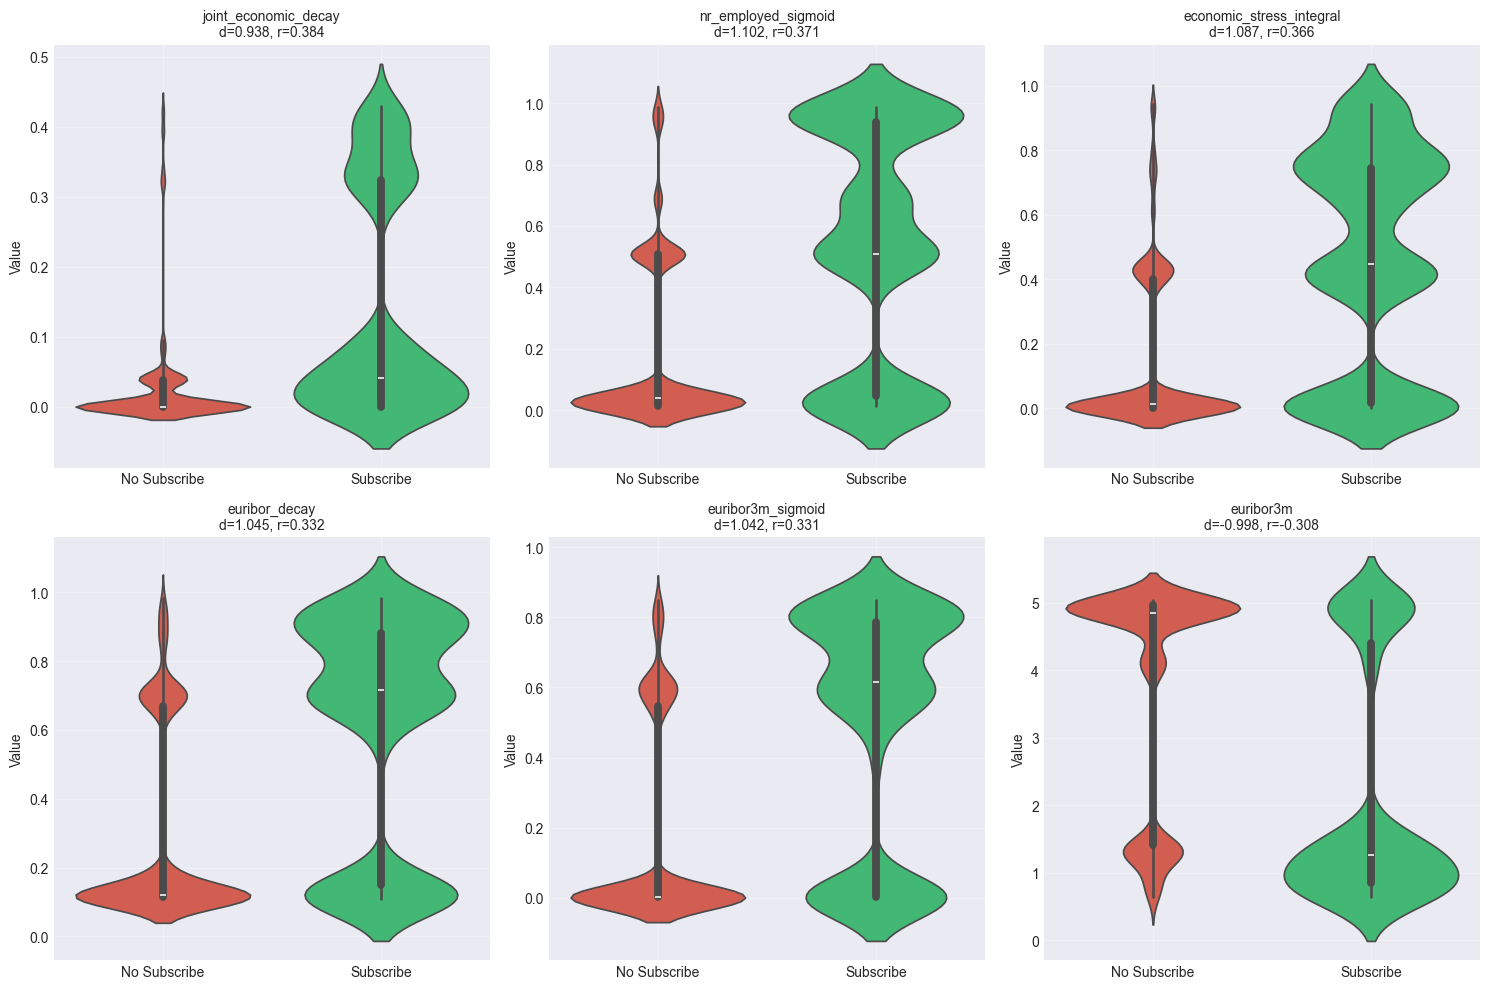

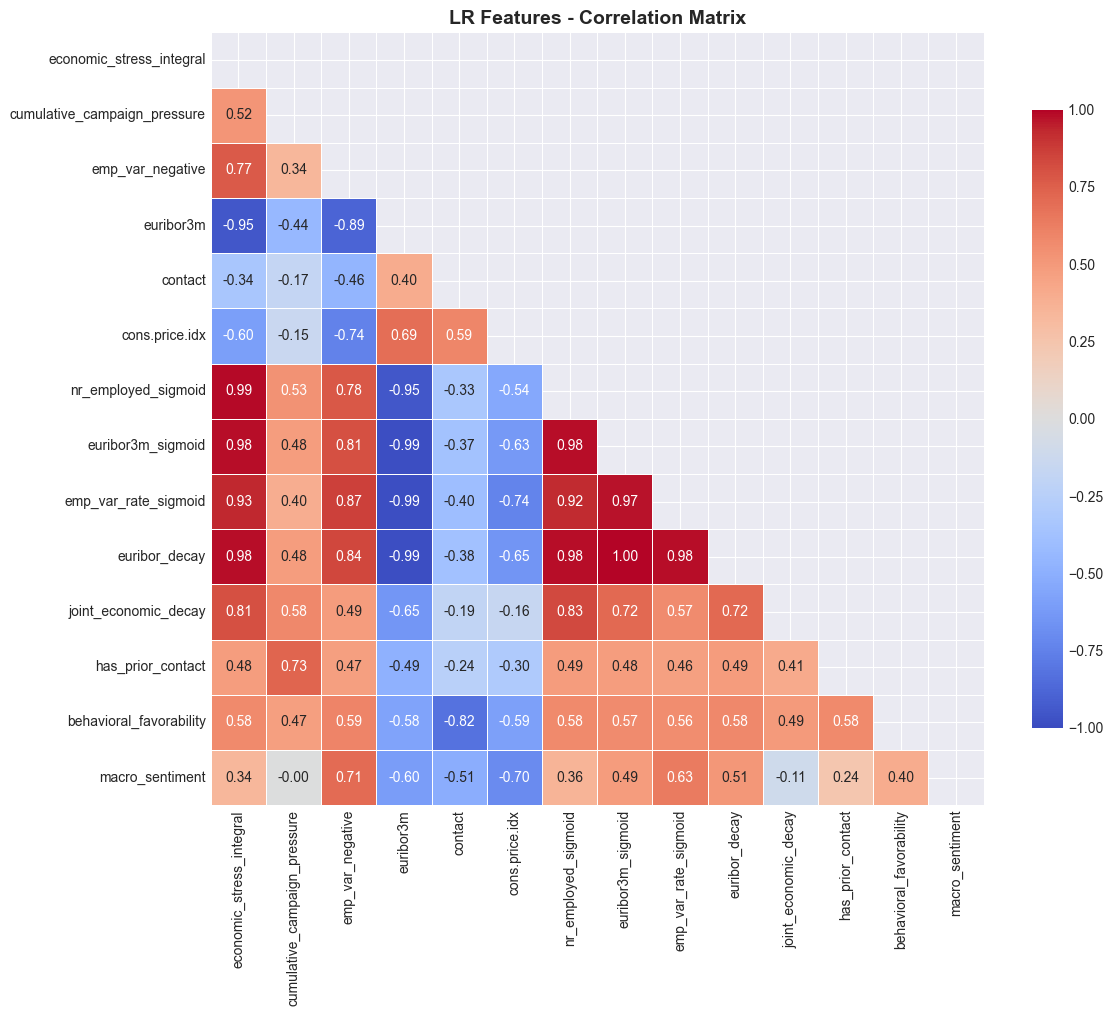


📋 LR SUMMARY & RECOMMENDATIONS

✅ Analyzed 14 features
⚠️  30 high correlation pairs
⚠️  9 features with VIF > 10: ['euribor_decay', 'euribor3m', 'euribor3m_sigmoid', 'economic_stress_integral', 'nr_employed_sigmoid', 'emp_var_rate_sigmoid', 'joint_economic_decay', 'emp_var_negative', 'macro_sentiment']
⚠️  1 weak separators: ['macro_sentiment']


🌲 SECTION 2: RANDOM FOREST FEATURE ANALYSIS

🔍 Analyzing RF feature set...

--------------------------------------------------------------------------------
1️⃣  GINI FEATURE IMPORTANCE
--------------------------------------------------------------------------------

📊 Top 20:

    1. joint_economic_decay                Imp=0.0939  🔥 STRONG
    2. neighborhood_subscription_density   Imp=0.0872  🔥 STRONG
    3. nr_employed_decay                   Imp=0.0872  🔥 STRONG
    4. nr_employed_local_rate              Imp=0.0843  🔥 STRONG
    5. economic_stress_integral            Imp=0.0821  🔥 STRONG
    6. euribor3m_local_rate                Imp=0.0

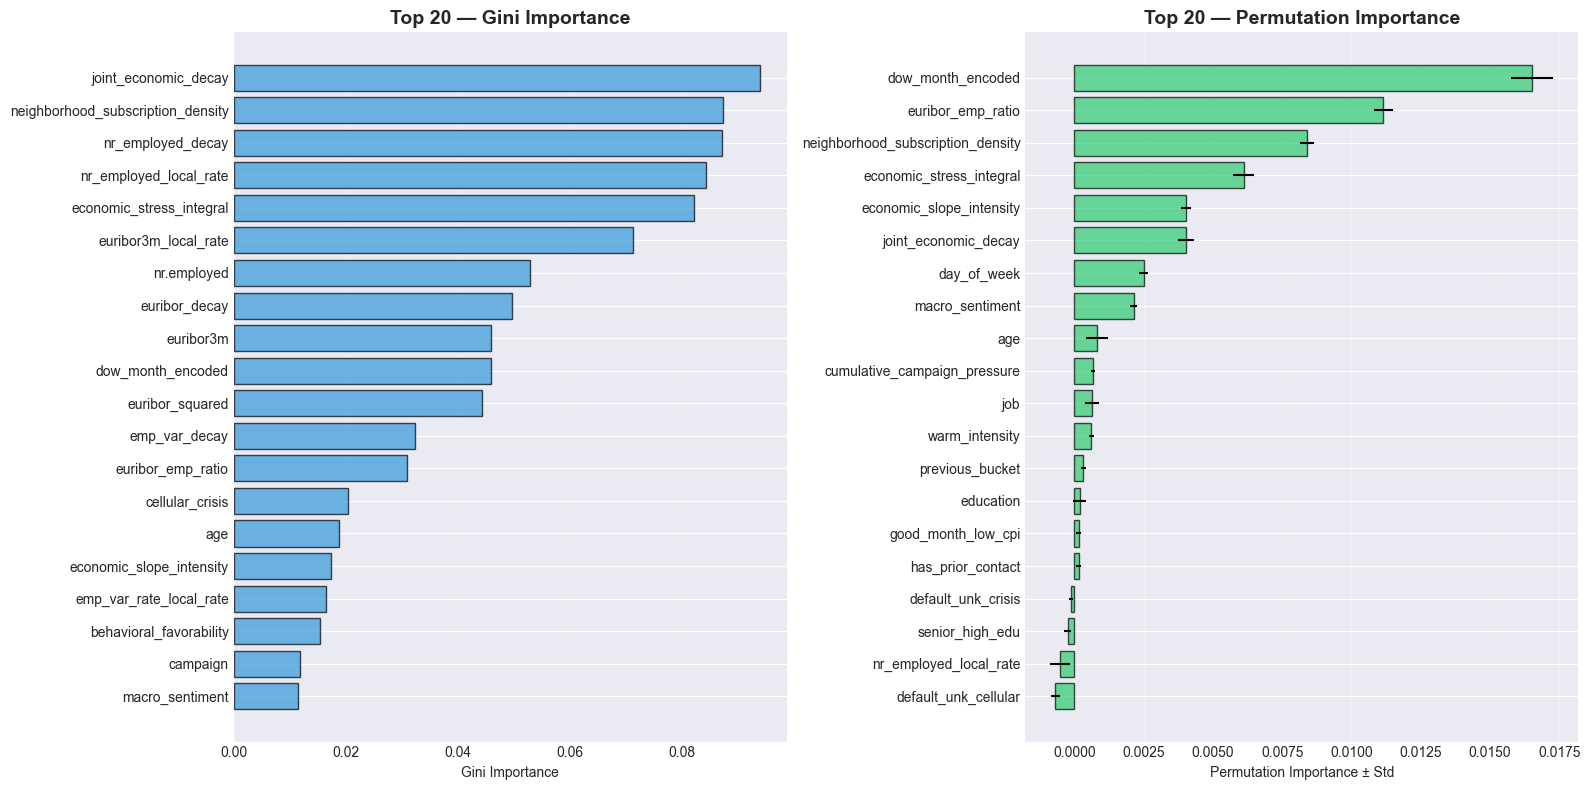


📊 Consistency: 4/10 overlap between Gini and Permutation top-10
   ⚠️  Low agreement — investigate discrepancies

📋 RF SUMMARY & RECOMMENDATIONS
✅ Analyzed 35 features
⚠️  14 features with importance < 0.01 — removal candidates
⚠️  72 redundant pairs among top features


🔮 SECTION 3: EBM FEATURE ANALYSIS

🔍 Analyzing EBM feature set...

--------------------------------------------------------------------------------
1️⃣  GLOBAL FEATURE IMPORTANCE (Main Effects)
--------------------------------------------------------------------------------

📊 Top 20:
    1. cpi_high_cellular                   Importance=0.1651
    2. dow_month_encoded                   Importance=0.1549
    3. euribor3m_local_rate                Importance=0.1422
    4. contact                             Importance=0.1179
    5. cellular_crisis                     Importance=0.1059
    6. dow_x_stress                        Importance=0.0981
    7. cons.conf.idx                       Importance=0.0900
    8. euribor

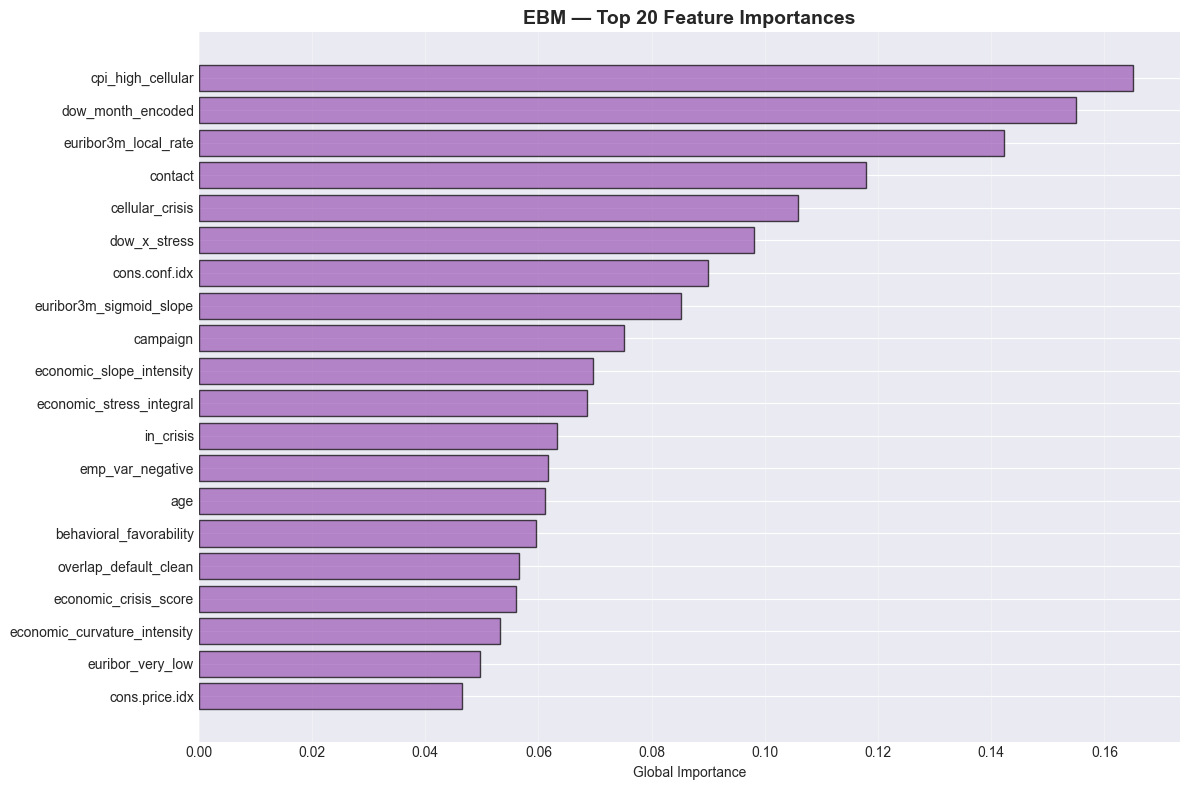


📋 EBM SUMMARY & RECOMMENDATIONS
✅ Analyzed 57 features
✅ 5 strongly non-linear — EBM adds value: ['euribor3m_local_rate', 'dow_x_stress', 'cons.conf.idx', 'euribor3m_sigmoid_slope', 'economic_slope_intensity']


🔬 SECTION 4: CROSS-MODEL FEATURE COMPARISON

📊 Top 10 per model:

   LR:
       1. euribor3m
       2. euribor_decay
       3. nr_employed_sigmoid
       4. euribor3m_sigmoid
       5. emp_var_rate_sigmoid
       6. economic_stress_integral
       7. emp_var_negative
       8. joint_economic_decay
       9. behavioral_favorability
      10. cons.price.idx

   RF:
       1. joint_economic_decay
       2. neighborhood_subscription_density
       3. nr_employed_decay
       4. nr_employed_local_rate
       5. economic_stress_integral
       6. euribor3m_local_rate
       7. nr.employed
       8. euribor_decay
       9. euribor3m
      10. dow_month_encoded

   EBM:
       1. cpi_high_cellular
       2. dow_month_encoded
       3. euribor3m_local_rate
       4. contact
       5. c

In [24]:
# ============================================================
# CELL 15: COMPREHENSIVE FEATURE ANALYSIS BY MODEL TYPE
# ============================================================

"""
COMPREHENSIVE FEATURE DIAGNOSTICS
==================================
Validates feature quality, stability, and appropriateness per model type.
"""
print("\n" + "=" * 80)
print("📊 COMPREHENSIVE FEATURE ANALYSIS BY MODEL TYPE")
print("=" * 80)


def _get_scaler(obj):
    """Extract scaler from Pipeline if present."""
    if hasattr(obj, 'named_steps') and 'scaler' in obj.named_steps:
        return obj.named_steps['scaler']
    return None

# ── Check model availability ──────────────────────────────────
missing_models = []

# LR: try lr_best_model (14B prefixed) → lr_best_pipe → best_lr (12A)
_lr_raw = None
_lr_scaler_resolved = None

try:
    _lr_raw = lr_best_model  
    _lr_scaler_resolved = _get_scaler(lr_best_pipe) if 'lr_best_pipe' in dir() else None
    print(f"   ✅ LR model found: lr_best_model (from Cell 12B)")
except NameError:
    if _lr_raw is None:
        try:
            _lr_raw = best_lr
            _lr_scaler_resolved = scaler if 'scaler' in dir() else None
        except NameError:
            pass

if _lr_raw is None:
    missing_models.append('LR (Cell 12)')

# RF: try rf_best_model (13B prefixed) → best_rf (13A)
_rf_raw = None

try:
    _rf_raw = rf_best_model  # from 13B
    print(f"   ✅ RF model found: rf_best_model (from Cell 13B)")
except NameError:
    try:
        if hasattr(best_rf, 'feature_importances_'):
            _rf_raw = best_rf
    except NameError:
        pass

if _rf_raw is None:
    missing_models.append('RF (Cell 13)')

# EBM: try ebm_best_model (14B prefixed) → best_ebm (14A)
_ebm_raw = None

try:
    _ebm_raw = ebm_best_model  # from 14B
    print(f"   ✅ EBM model found: ebm_best_model (from Cell 14B)")
except NameError:
    try:
        _ebm_raw = best_ebm
    except NameError:
        pass

ebm_available = _ebm_raw is not None

if missing_models:
    print(f"\n⚠️  WARNING: Missing required models: {', '.join(missing_models)}")
    print("   Please run Cells 12/13 first (and optionally Cell 14 for EBM).")
    print("\n❌ Cannot proceed with analysis")
    SKIP_ANALYSIS = True
    SKIP_EBM_ANALYSIS = True
else:
    print(f"\n✅ Required models available:")
    print(f"   LR:  {type(_lr_raw).__name__}  |  Scaler: {'yes' if _lr_scaler_resolved else 'none (will create)'}")
    print(f"   RF:  {type(_rf_raw).__name__}")
    if ebm_available:
        print(f"   EBM: {type(_ebm_raw).__name__}")
    else:
        print("   ⚠️  EBM not available — will skip EBM analysis")
    SKIP_ANALYSIS = False
    SKIP_EBM_ANALYSIS = not ebm_available

# ============================================================
# SECTION 1: LOGISTIC REGRESSION FEATURE ANALYSIS
# ============================================================
if not SKIP_ANALYSIS:
    print("\n" + "=" * 80)
    print("📈 SECTION 1: LOGISTIC REGRESSION FEATURE ANALYSIS")
    print("=" * 80)
    print("\nGoal: Validate features meet LR assumptions")
    print("- Low multicollinearity (VIF < 10)")
    print("- Strong class separation")
    print("- Coefficient magnitude and direction")

def analyze_lr_features(lr_model, df, feature_list, target_col='y'):
    """
    LR feature diagnostics: VIF, correlations, coefficients, class separation.
    """
    X = df[feature_list].copy()
    y = df[target_col].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    for col in X.columns:
        if X[col].isnull().any():
            X[col].fillna(X[col].median(), inplace=True)

    # ── 1. Multicollinearity ─────────────────────────────────
    print("\n" + "-" * 80)
    print("1️⃣  MULTICOLLINEARITY ANALYSIS")
    print("-" * 80)

    corr_matrix = X.corr()

    print("\n📊 High Correlation Pairs (|r| > 0.7):")
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                high_corr.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })

    if high_corr:
        df_high_corr = pd.DataFrame(high_corr).sort_values(
            'Correlation', key=abs, ascending=False)
        print(df_high_corr.to_string(index=False))
        print("\n⚠️  Consider removing one feature from each pair")
    else:
        print("   ✅ No high correlations detected")

    # VIF
    print("\n📊 Variance Inflation Factor (VIF):")
    high_vif = []
    try:
        from statsmodels.stats.outliers_influence import variance_inflation_factor
        X_scaled = StandardScaler().fit_transform(X)
        X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

        vif_data = []
        for i, col in enumerate(X_scaled_df.columns):
            vif = variance_inflation_factor(X_scaled_df.values, i)
            vif_data.append({'Feature': col, 'VIF': vif})

        df_vif = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

        for _, row in df_vif.iterrows():
            vif = row['VIF']
            status = "❌ HIGH" if vif > 10 else "⚠️  MOD" if vif > 5 else "✅ LOW"
            print(f"   {row['Feature']:35s} VIF={vif:6.2f}  {status}")

        high_vif = df_vif[df_vif['VIF'] > 10]['Feature'].tolist()
        if high_vif:
            print(f"\n⚠️  VIF > 10: {high_vif}")
    except ImportError:
        print("   ⚠️  statsmodels not installed — VIF skipped")
        df_vif = pd.DataFrame()

    # ── 2. Coefficients ───────────────────────────────────────
    print("\n" + "-" * 80)
    print("2️⃣  MODEL COEFFICIENTS")
    print("-" * 80)

    coefs = lr_model.coef_[0]
    coef_stats = [{'Feature': feat, 'Coefficient': coefs[i], 'Abs_Coef': abs(coefs[i])}
                  for i, feat in enumerate(feature_list)]
    df_coef_stability = pd.DataFrame(coef_stats).sort_values('Abs_Coef', ascending=False)

    print("\n📊 Feature Coefficients:\n")
    for _, row in df_coef_stability.iterrows():
        c = row['Coefficient']
        status = "🔥 STRONG" if abs(c) > 1.0 else "✅ MOD" if abs(c) > 0.5 else "⚪ WEAK"
        print(f"   {row['Feature']:35s} Coef={c:+7.3f}  {status}")

    # ── 3. Class separation ───────────────────────────────────
    print("\n" + "-" * 80)
    print("3️⃣  CLASS SEPARATION ANALYSIS")
    print("-" * 80)

    separation_metrics = []
    y_values = y.values
    for feat in feature_list:
        feat_values = X[feat].values
        class_0 = feat_values[y_values == 0]
        class_1 = feat_values[y_values == 1]
        mean_diff = class_1.mean() - class_0.mean()
        pooled_std = np.sqrt((class_0.std() ** 2 + class_1.std() ** 2) / 2)
        cohens_d = mean_diff / (pooled_std + 1e-10)
        ks_stat, _ = ks_2samp(class_0, class_1)
        corr, _ = pointbiserialr(y_values, feat_values)
        separation_metrics.append({
            'Feature': feat, 'Cohens_d': cohens_d,
            'KS_Statistic': ks_stat, 'Point_Biserial_r': corr,
            'Abs_Corr': abs(corr)
        })

    df_separation = pd.DataFrame(separation_metrics).sort_values('Abs_Corr', ascending=False)

    print("\n📊 Class Separation Metrics:\n")
    for _, row in df_separation.iterrows():
        ks = row['KS_Statistic']
        r = abs(row['Point_Biserial_r'])
        status = "✅ STRONG" if r > 0.2 and ks > 0.2 else "⚠️  MOD" if r > 0.1 else "❌ WEAK"
        print(f"   {row['Feature']:35s} d={row['Cohens_d']:+6.3f} KS={ks:5.3f} r={row['Point_Biserial_r']:+6.3f}  {status}")

    weak = df_separation[df_separation['Abs_Corr'] < 0.05]['Feature'].tolist()
    if weak:
        print(f"\n⚠️  Weak separators (|r| < 0.05): {weak}")

    # ── 4. Visualizations ─────────────────────────────────────
    print("\n" + "-" * 80)
    print("4️⃣  VISUALIZATIONS")
    print("-" * 80)

    top_features = df_separation.nlargest(6, 'Abs_Corr')['Feature'].tolist()
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    for i, feat in enumerate(top_features):
        ax = axes[i]
        plot_data = pd.DataFrame({
            'Value': X[feat], 'Class': y.map({0: 'No Subscribe', 1: 'Subscribe'})
        })
        sns.violinplot(data=plot_data, x='Class', y='Value', ax=ax,
                       palette=['#e74c3c', '#2ecc71'])
        d = df_separation[df_separation['Feature'] == feat]['Cohens_d'].values[0]
        r = df_separation[df_separation['Feature'] == feat]['Point_Biserial_r'].values[0]
        ax.set_title(f"{feat}\nd={d:.3f}, r={r:.3f}", fontsize=10)
        ax.set_xlabel('')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Correlation heatmap
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('LR Features - Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Summary ───────────────────────────────────────────────
    print("\n" + "=" * 80)
    print("📋 LR SUMMARY & RECOMMENDATIONS")
    print("=" * 80)
    print(f"\n✅ Analyzed {len(feature_list)} features")
    if high_corr:
        print(f"⚠️  {len(high_corr)} high correlation pairs")
    if high_vif:
        print(f"⚠️  {len(high_vif)} features with VIF > 10: {high_vif}")
    if weak:
        print(f"⚠️  {len(weak)} weak separators: {weak}")
    if not any([high_vif, weak, high_corr]):
        print("✅ Feature set meets quality criteria!")
    print("=" * 80)

    return {
        'correlation': corr_matrix,
        'vif': df_vif,
        'coefficients': df_coef_stability,
        'separation': df_separation
    }

# Run LR analysis
if not SKIP_ANALYSIS:
    print("\n🔍 Analyzing LR feature set...")
    lr_analysis = analyze_lr_features(_lr_raw, df_engineered, LR_FEATURES, TARGET_COL)

# ============================================================
# SECTION 2: RANDOM FOREST FEATURE ANALYSIS
# ============================================================
if not SKIP_ANALYSIS:
    print("\n\n" + "=" * 80)
    print("🌲 SECTION 2: RANDOM FOREST FEATURE ANALYSIS")
    print("=" * 80)

def analyze_rf_features(rf_model, df, feature_list, target_col='y'):
    """
    RF diagnostics: Gini importance, permutation importance, redundancy.
    """
    from sklearn.inspection import permutation_importance

    X = df[feature_list].copy()
    y = df[target_col].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    for col in X.columns:
        if X[col].isnull().any():
            X[col].fillna(X[col].median(), inplace=True)

    # ── 1. Gini importance ────────────────────────────────────
    print("\n" + "-" * 80)
    print("1️⃣  GINI FEATURE IMPORTANCE")
    print("-" * 80)

    importance_stats = [
        {'Feature': feat, 'Mean_Importance': rf_model.feature_importances_[i],
         'Std_Importance': 0}
        for i, feat in enumerate(feature_list)
    ]
    df_importance = pd.DataFrame(importance_stats).sort_values('Mean_Importance', ascending=False)

    print("\n📊 Top 20:\n")
    for rank, (_, row) in enumerate(df_importance.head(20).iterrows(), 1):
        imp = row['Mean_Importance']
        status = "🔥 STRONG" if imp > 0.05 else "✅ MOD" if imp > 0.02 else "⚪ WEAK"
        print(f"   {rank:2d}. {row['Feature']:35s} Imp={imp:.4f}  {status}")

    low_importance = df_importance[df_importance['Mean_Importance'] < 0.01]['Feature'].tolist()
    if low_importance:
        print(f"\n⚠️  {len(low_importance)} features with importance < 0.01 — consider removing")

    # ── 2. Permutation importance ─────────────────────────────
    print("\n" + "-" * 80)
    print("2️⃣  PERMUTATION IMPORTANCE")
    print("-" * 80)

    print("\n🔄 Computing...")
    perm_importance = permutation_importance(
        rf_model, X, y, n_repeats=10, random_state=42, n_jobs=-1
    )
    perm_data = [
        {'Feature': feat,
         'Perm_Importance': perm_importance.importances_mean[i],
         'Perm_Std': perm_importance.importances_std[i]}
        for i, feat in enumerate(feature_list)
    ]
    df_perm = pd.DataFrame(perm_data).sort_values('Perm_Importance', ascending=False)

    print("\n📊 Top 20:\n")
    for _, row in df_perm.head(20).iterrows():
        print(f"   {row['Feature']:35s} PermImp={row['Perm_Importance']:.4f} ± {row['Perm_Std']:.4f}")

    # ── 3. Redundancy among top features ──────────────────────
    print("\n" + "-" * 80)
    print("3️⃣  REDUNDANCY ANALYSIS (Top 20)")
    print("-" * 80)

    top_20_features = df_importance.head(20)['Feature'].tolist()
    corr_top = X[top_20_features].corr()

    high_corr_top = []
    for i in range(len(corr_top.columns)):
        for j in range(i + 1, len(corr_top.columns)):
            if abs(corr_top.iloc[i, j]) > 0.7:
                high_corr_top.append({
                    'Feature 1': corr_top.columns[i],
                    'Feature 2': corr_top.columns[j],
                    'Correlation': corr_top.iloc[i, j]
                })

    if high_corr_top:
        print("\n⚠️  High correlations among top 20:")
        print(pd.DataFrame(high_corr_top).sort_values('Correlation', key=abs, ascending=False).to_string(index=False))
    else:
        print("\n✅ No high correlations among top 20 features")

    # ── 4. Visualization ──────────────────────────────────────
    print("\n" + "-" * 80)
    print("4️⃣  VISUALIZATION")
    print("-" * 80)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    top_20 = df_importance.head(20)
    axes[0].barh(range(len(top_20)), top_20['Mean_Importance'],
                 color='#3498db', alpha=0.7, edgecolor='black')
    axes[0].set_yticks(range(len(top_20)))
    axes[0].set_yticklabels(top_20['Feature'])
    axes[0].set_xlabel('Gini Importance')
    axes[0].set_title('Top 20 — Gini Importance', fontsize=14, fontweight='bold')
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)

    top_20_perm = df_perm.head(20)
    axes[1].barh(range(len(top_20_perm)), top_20_perm['Perm_Importance'],
                 xerr=top_20_perm['Perm_Std'],
                 color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[1].set_yticks(range(len(top_20_perm)))
    axes[1].set_yticklabels(top_20_perm['Feature'])
    axes[1].set_xlabel('Permutation Importance ± Std')
    axes[1].set_title('Top 20 — Permutation Importance', fontsize=14, fontweight='bold')
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ── Consistency check ─────────────────────────────────────
    top_10_gini = set(df_importance.head(10)['Feature'])
    top_10_perm = set(df_perm.head(10)['Feature'])
    overlap = top_10_gini & top_10_perm
    print(f"\n📊 Consistency: {len(overlap)}/10 overlap between Gini and Permutation top-10")
    if len(overlap) >= 7:
        print("   ✅ Good agreement")
    else:
        print("   ⚠️  Low agreement — investigate discrepancies")

    # ── Summary ───────────────────────────────────────────────
    print("\n" + "=" * 80)
    print("📋 RF SUMMARY & RECOMMENDATIONS")
    print("=" * 80)
    print(f"✅ Analyzed {len(feature_list)} features")
    if low_importance:
        print(f"⚠️  {len(low_importance)} features with importance < 0.01 — removal candidates")
    if high_corr_top:
        print(f"⚠️  {len(high_corr_top)} redundant pairs among top features")
    print("=" * 80)

    return {
        'importance': df_importance,
        'permutation': df_perm,
        'correlation_top': corr_top
    }

# Run RF analysis
if not SKIP_ANALYSIS:
    print("\n🔍 Analyzing RF feature set...")
    rf_analysis = analyze_rf_features(_rf_raw, df_engineered, RF_FEATURES, TARGET_COL)

# ============================================================
# SECTION 3: EBM FEATURE ANALYSIS
# ============================================================
if not SKIP_EBM_ANALYSIS:
    print("\n\n" + "=" * 80)
    print("🔮 SECTION 3: EBM FEATURE ANALYSIS")
    print("=" * 80)

def analyze_ebm_features(ebm_model, feature_list):
    """
    EBM diagnostics: main effects, interactions, non-linearity, effect magnitudes.
    """
    ebm_global = ebm_model.explain_global()

    # ── 1. Global importance (main effects) ───────────────────
    print("\n" + "-" * 80)
    print("1️⃣  GLOBAL FEATURE IMPORTANCE (Main Effects)")
    print("-" * 80)

    feature_importances = []
    for i, feat in enumerate(ebm_global.data()['names']):
        if isinstance(feat, str):
            feature_importances.append({
                'Feature': feat,
                'Importance': ebm_global.data()['scores'][i]
            })

    df_ebm_importance = pd.DataFrame(feature_importances).sort_values(
        'Importance', ascending=False
    ).reset_index(drop=True)

    print("\n📊 Top 20:")
    for rank, (_, row) in enumerate(df_ebm_importance.head(20).iterrows(), 1):
        print(f"   {rank:2d}. {row['Feature']:35s} Importance={row['Importance']:.4f}")

    # ── 2. Pairwise interactions ──────────────────────────────
    print("\n" + "-" * 80)
    print("2️⃣  PAIRWISE INTERACTION ANALYSIS")
    print("-" * 80)

    interaction_importances = []
    for i, feat in enumerate(ebm_global.data()['names']):
        if isinstance(feat, tuple):
            interaction_importances.append({
                'Feature_1': feat[0], 'Feature_2': feat[1],
                'Interaction': f"{feat[0]} × {feat[1]}",
                'Importance': ebm_global.data()['scores'][i]
            })

    if interaction_importances:
        df_interactions = pd.DataFrame(interaction_importances).sort_values(
            'Importance', ascending=False
        )
        print("\n📊 Top Interactions:")
        for _, row in df_interactions.iterrows():
            print(f"   {row['Interaction']:50s} Importance={row['Importance']:.4f}")
    else:
        print("\n⚠️  No pairwise interactions detected")
        df_interactions = pd.DataFrame()

    # ── 3. Non-linearity assessment ───────────────────────────
    print("\n" + "-" * 80)
    print("3️⃣  NON-LINEARITY ASSESSMENT (Top 10)")
    print("-" * 80)

    from scipy.stats import linregress

    nonlinearity_scores = []
    for feat in df_ebm_importance.head(10)['Feature']:
        try:
            feat_idx = list(ebm_global.data()['names']).index(feat)
        except ValueError:
            continue

        feat_data = ebm_global.data(feat_idx)
        if 'scores' not in feat_data or 'names' not in feat_data:
            continue

        raw_x, raw_y = feat_data['names'], feat_data['scores']
        x_vals, y_vals = [], []
        for xi, yi in zip(raw_x, raw_y):
            numeric_x = None
            if isinstance(xi, (int, float, np.integer, np.floating)):
                numeric_x = float(xi)
            elif isinstance(xi, str):
                try:
                    numeric_x = float(xi)
                except ValueError:
                    if ' - ' in xi:
                        parts = xi.split(' - ')
                        try:
                            numeric_x = (float(parts[0]) + float(parts[1])) / 2
                        except (ValueError, IndexError):
                            pass
            elif isinstance(xi, (tuple, list, np.ndarray)):
                try:
                    numeric_x = np.mean([float(v) for v in xi])
                except (ValueError, TypeError):
                    pass

            if numeric_x is not None and np.isfinite(numeric_x):
                try:
                    numeric_y = float(yi)
                    if np.isfinite(numeric_y):
                        x_vals.append(numeric_x)
                        y_vals.append(numeric_y)
                except (ValueError, TypeError):
                    pass

        x_vals, y_vals = np.array(x_vals, dtype=np.float64), np.array(y_vals, dtype=np.float64)

        if len(x_vals) < 3 or np.std(x_vals) < 1e-10 or np.std(y_vals) < 1e-10:
            print(f"   {feat:35s} ⚠️  Skipped (categorical or constant)")
            continue

        try:
            _, _, r_value, _, _ = linregress(x_vals, y_vals)
            r_squared = r_value ** 2
            score_range = np.ptp(y_vals)
            nonlinearity_scores.append({
                'Feature': feat, 'R_squared': r_squared,
                'Score_Range': score_range, 'Num_Bins': len(x_vals),
            })
        except Exception:
            pass

    df_nonlinearity = pd.DataFrame(nonlinearity_scores) if nonlinearity_scores else pd.DataFrame()

    if not df_nonlinearity.empty:
        for _, row in df_nonlinearity.iterrows():
            r2 = row['R_squared']
            status = "✅ LINEAR" if r2 > 0.9 else "⚠️  MOD NON-LIN" if r2 > 0.7 else "🔄 STRONGLY NON-LIN"
            print(f"   {row['Feature']:35s} R²={r2:.3f}  Range={row['Score_Range']:.3f}  {status}")

    # ── 4. Effect magnitude ───────────────────────────────────
    print("\n" + "-" * 80)
    print("4️⃣  MARGINAL EFFECT MAGNITUDE")
    print("-" * 80)

    effect_magnitudes = []
    for feat in df_ebm_importance['Feature']:
        try:
            feat_idx = list(ebm_global.data()['names']).index(feat)
            feat_data = ebm_global.data(feat_idx)
            if 'scores' in feat_data:
                scores = np.array(feat_data['scores'], dtype=float)
                scores = scores[np.isfinite(scores)]
                if len(scores) > 0:
                    effect_magnitudes.append({
                        'Feature': feat, 'Score_Range': np.ptp(scores),
                        'Score_Std': np.std(scores), 'Score_Max': np.max(np.abs(scores)),
                    })
        except (ValueError, TypeError):
            pass

    df_effects = pd.DataFrame(effect_magnitudes).sort_values('Score_Range', ascending=False) if effect_magnitudes else pd.DataFrame()

    if not df_effects.empty:
        for _, row in df_effects.head(20).iterrows():
            rng = row['Score_Range']
            status = "❌ NEGLIGIBLE" if rng < 0.01 else "⚠️  SMALL" if rng < 0.05 else "✅"
            print(f"   {row['Feature']:35s} Range={rng:7.4f}  Std={row['Score_Std']:7.4f}  {status}")
        negligible = df_effects[df_effects['Score_Range'] < 0.01]['Feature'].tolist()
        if negligible:
            print(f"\n   ❌ Negligible effect features: {negligible}")

    # ── 5. Cumulative importance ──────────────────────────────
    print("\n" + "-" * 80)
    print("5️⃣  CUMULATIVE IMPORTANCE")
    print("-" * 80)

    total_importance = df_ebm_importance['Importance'].sum()
    cumulative = 0
    thresholds_hit = {}
    for rank, (_, row) in enumerate(df_ebm_importance.iterrows(), 1):
        cumulative += row['Importance']
        pct = (cumulative / total_importance) * 100
        for threshold in [80, 90, 95]:
            if threshold not in thresholds_hit and pct >= threshold:
                thresholds_hit[threshold] = rank

    for threshold, rank in sorted(thresholds_hit.items()):
        print(f"   {threshold}% of importance → top {rank} features (of {len(df_ebm_importance)})")

    # ── 6. Visualization ──────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 8))
    top_20 = df_ebm_importance.head(20)
    colors = ['#9b59b6' if imp > 0.02 else '#bdc3c7' for imp in top_20['Importance']]
    ax.barh(range(len(top_20)), top_20['Importance'], color=colors, alpha=0.7, edgecolor='black')
    ax.set_yticks(range(len(top_20)))
    ax.set_yticklabels(top_20['Feature'])
    ax.set_xlabel('Global Importance')
    ax.set_title('EBM — Top 20 Feature Importances', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ── Summary ───────────────────────────────────────────────
    print("\n" + "=" * 80)
    print("📋 EBM SUMMARY & RECOMMENDATIONS")
    print("=" * 80)
    print(f"✅ Analyzed {len(feature_list)} features")
    if not df_nonlinearity.empty:
        linear_feats = df_nonlinearity[df_nonlinearity['R_squared'] > 0.9]['Feature'].tolist()
        nonlinear_feats = df_nonlinearity[df_nonlinearity['R_squared'] <= 0.7]['Feature'].tolist()
        if linear_feats:
            print(f"⚠️  {len(linear_feats)} mostly linear features — may be redundant with LR: {linear_feats}")
        if nonlinear_feats:
            print(f"✅ {len(nonlinear_feats)} strongly non-linear — EBM adds value: {nonlinear_feats}")
    print("=" * 80)

    return {
        'importance': df_ebm_importance,
        'interactions': df_interactions if interaction_importances else None,
        'nonlinearity': df_nonlinearity,
        'effect_magnitudes': df_effects if effect_magnitudes else None
    }

# Run EBM analysis
if not SKIP_EBM_ANALYSIS:
    print("\n🔍 Analyzing EBM feature set...")
    ebm_analysis = analyze_ebm_features(_ebm_raw, EBM_FEATURES)
else:
    print("\n⚠️  Skipping EBM analysis (EBM model not available)")
    ebm_analysis = None

# ============================================================
# SECTION 4: CROSS-MODEL COMPARISON
# ============================================================
if not SKIP_ANALYSIS:
    print("\n\n" + "=" * 80)
    print("🔬 SECTION 4: CROSS-MODEL FEATURE COMPARISON")
    print("=" * 80)

    # ── Top 10 per model ──────────────────────────────────────
    lr_top10 = lr_analysis['coefficients'].head(10)['Feature'].tolist()
    rf_top10 = rf_analysis['importance'].head(10)['Feature'].tolist()
    ebm_top10 = ebm_analysis['importance'].head(10)['Feature'].tolist() if ebm_analysis else []

    print("\n📊 Top 10 per model:")
    for name, top in [("LR", lr_top10), ("RF", rf_top10), ("EBM", ebm_top10)]:
        if top:
            print(f"\n   {name}:")
            for i, feat in enumerate(top, 1):
                print(f"      {i:2d}. {feat}")
        else:
            print(f"\n   {name}: (skipped)")

    # ── Consensus features ────────────────────────────────────
    print("\n" + "-" * 80)
    print("CONSENSUS FEATURES (Top 10 of 2+ models)")
    print("-" * 80)

    all_features = set(lr_top10 + rf_top10 + ebm_top10)
    consensus = []
    for feat in all_features:
        count = sum([feat in lr_top10, feat in rf_top10, feat in ebm_top10])
        if count >= 2:
            models = []
            if feat in lr_top10: models.append(f"LR(#{lr_top10.index(feat) + 1})")
            if feat in rf_top10: models.append(f"RF(#{rf_top10.index(feat) + 1})")
            if feat in ebm_top10: models.append(f"EBM(#{ebm_top10.index(feat) + 1})")
            consensus.append({'Feature': feat, 'Models': count, 'Rankings': ', '.join(models)})

    df_consensus = pd.DataFrame(consensus).sort_values('Models', ascending=False)
    for _, row in df_consensus.iterrows():
        status = "⭐ ALL THREE" if row['Models'] == 3 else "✅ TWO"
        print(f"   {row['Feature']:35s} {status:15s} [{row['Rankings']}]")

    # ── Final recommendations ─────────────────────────────────
    print("\n" + "=" * 80)
    print("🎯 FINAL RECOMMENDATIONS FOR FEATURE REDUCTION")
    print("=" * 80)

    print(f"\n   LR:  {len(LR_FEATURES)} features", end="")
    if lr_analysis['vif'].shape[0] > 0 and (lr_analysis['vif']['VIF'] > 10).any():
        print(f" — ⚠️  VIF issues")
    else:
        print(f" — ✅")

    rf_low = rf_analysis['importance'][rf_analysis['importance']['Mean_Importance'] < 0.01].shape[0]
    print(f"   RF:  {len(RF_FEATURES)} features", end="")
    if rf_low > 0:
        print(f" — ⚠️  {rf_low} features < 0.01 importance")
    else:
        print(f" — ✅")

    print(f"   EBM: {len(EBM_FEATURES)} features", end="")
    if ebm_analysis:
        print(f" — ✅")
    else:
        print(f" — (skipped)")

    print(f"\n   💡 Consensus features are strong candidates to KEEP")
    print(f"   💡 Features flagged as weak/redundant across multiple analyses → REMOVE")

    print("\n" + "=" * 80)
    print("✅ COMPREHENSIVE FEATURE ANALYSIS COMPLETE")
    print("=" * 80)

In [25]:
# ================================================================
# CELL 16: META-ARBITER EXPERIMENT 
# ================================================================

print("=" * 80)
print("🧪 META-ARBITER EXPERIMENT")
print("=" * 80)

# ============================================================
# 1. Stages 1 - 3 FEATURE SETS 
# ============================================================
print(f"\n📊 Feature Sets: LR={len(LR_FEATURES)}, "
      f"RF={len(RF_FEATURES)}, EBM={len(EBM_FEATURES)}")

print("\n" + "-" * 80)
print("🔍 CHECKING FOR OPTUNA-TUNED PARAMETERS")
print("-" * 80)

# ── LR params ─────────────────────────────────────────────────
LR_HARDCODED = dict(C=1.0, class_weight='balanced', solver='lbfgs', max_iter=1000, random_state=42)
LR_OPTUNA = None

try:
    _bp = lr_optuna_params  # set at end of Cell 12B
    _C = _bp.get('C', _bp.get('clf__C', 1.0))
    _pen = _bp.get('penalty', _bp.get('clf__penalty', 'l2'))
    _cw = _bp.get('class_weight', _bp.get('clf__class_weight', None))
    if _cw == 'None': _cw = None
    LR_OPTUNA = dict(C=_C, penalty=_pen, solver='saga', max_iter=5000, random_state=42,
                     class_weight=_cw)
    if _pen == 'elasticnet':
        LR_OPTUNA['l1_ratio'] = _bp.get('l1_ratio', _bp.get('clf__l1_ratio', 0.5))
    print(f"   ✅ LR Optuna params found: C={_C:.4f}, penalty={_pen}, class_weight={_cw}")
except NameError:
    print(f"   ℹ️  LR Optuna params not found (lr_optuna_params missing) — hardcoded only")

# ── RF params ─────────────────────────────────────────────────
RF_HARDCODED = dict(
    n_estimators=200, max_depth=12, min_samples_leaf=5, min_samples_split=10,
    max_features='sqrt', class_weight='balanced_subsample', random_state=42, n_jobs=-1
)
RF_OPTUNA = None

try:
    _bp = rf_optuna_params  # set at end of Cell 13B
    _md = _bp.get('max_depth', None)
    if 'use_max_depth' in _bp and not _bp.get('use_max_depth', True):
        _md = None
    if _bp.get('max_features_type') == 'fraction':
        _mf = _bp.get('max_features_fraction', 0.5)
    elif _bp.get('max_features_type') in ('sqrt', 'log2'):
        _mf = _bp['max_features_type']
    else:
        _mf = _bp.get('max_features', 'sqrt')
    _cw = _bp.get('class_weight', None)
    if _cw == 'None': _cw = None
    RF_OPTUNA = dict(
        n_estimators=_bp['n_estimators'], max_depth=_md,
        min_samples_leaf=_bp.get('min_samples_leaf', 5),
        max_features=_mf, class_weight=_cw,
        random_state=42, n_jobs=-1
    )
    print(f"   ✅ RF Optuna params found: n_est={_bp['n_estimators']}, "
          f"depth={_md}, leaf={_bp.get('min_samples_leaf', 5)}")
except NameError:
    print(f"   ℹ️  RF Optuna params not found (rf_optuna_params missing) — hardcoded only")

# ── EBM params ────────────────────────────────────────────────
EBM_HARDCODED = dict(
    max_bins=512, max_interaction_bins=64, interactions=15,
    learning_rate=0.02, min_samples_leaf=5, max_leaves=5,
    n_jobs=1, random_state=42
)
EBM_OPTUNA = None

try:
    _bp = ebm_optuna_params  # set at end of Cell 14B
    EBM_OPTUNA = dict(
        learning_rate=_bp['learning_rate'], max_rounds=_bp['max_rounds'],
        max_bins=_bp['max_bins'], max_interaction_bins=_bp['max_interaction_bins'],
        interactions=_bp['interactions'], n_jobs=1, random_state=42
    )
    print(f"   ✅ EBM Optuna params found: lr={_bp['learning_rate']:.4f}, "
          f"rounds={_bp['max_rounds']}, interactions={_bp['interactions']}")
except NameError:
    print(f"   ℹ️  EBM Optuna params not found (ebm_optuna_params missing) — hardcoded only")

# ============================================================
# 3. PREPARE DATA
# ============================================================
print("\n" + "-" * 80)
print("1️⃣  PREPARING DATA")
print("-" * 80)

y_all = df_engineered[TARGET_COL].astype(int)
for name, feats in [("LR", LR_FEATURES), ("RF", RF_FEATURES), ("EBM", EBM_FEATURES)]:
    missing = [f for f in feats if f not in df_engineered.columns]
    print(f"   {'✅' if not missing else '⚠️'}  {name}: {len(feats)} features "
          f"{'— missing: ' + str(missing) if missing else 'OK'}")

train_idx, test_idx = train_test_split(
    np.arange(len(df_engineered)), test_size=0.2, random_state=42, stratify=y_all
)
y_train = y_all.iloc[train_idx].values
y_test = y_all.iloc[test_idx].values
print(f"   Train: {len(y_train):,} (pos: {y_train.sum():,})  "
      f"Test: {len(y_test):,} (pos: {y_test.sum():,})")

# ============================================================
# 4. THRESHOLD HELPER — recall-targeted for ALL models
# ============================================================
def find_recall_threshold(y_true, y_prob, target_recall=0.70):
    """Find threshold targeting a specific recall on the train set."""
    precs, recs, threshs = precision_recall_curve(y_true, y_prob)
    # recs is decreasing; find where it crosses target
    idx = np.argmin(np.abs(recs[:-1] - target_recall))
    return threshs[idx]

# ============================================================
# 5. TRAIN MODELS (hardcoded + Optuna)
# ============================================================
print("\n" + "-" * 80)
print("2️⃣  TRAINING MODELS")
print("-" * 80)

def _train_lr(params, label):
    """Train LR with given params, return probs + recall-tuned threshold."""
    print(f"\n   🔵 LR ({label})...")
    scaler_lr = StandardScaler()
    X_tr = scaler_lr.fit_transform(df_engineered.iloc[train_idx][LR_FEATURES].values)
    X_te = scaler_lr.transform(df_engineered.iloc[test_idx][LR_FEATURES].values)
    model = LogisticRegression(**params)
    model.fit(X_tr, y_train)
    p_tr = model.predict_proba(X_tr)[:, 1]
    p_te = model.predict_proba(X_te)[:, 1]
    # Recall-tuned threshold from train set
    t = find_recall_threshold(y_train, p_tr, target_recall=0.70)
    pred_te = (p_te >= t).astype(int)
    print(f"      thresh={t:.4f}  Acc={accuracy_score(y_test, pred_te):.4f}  "
          f"Rec={recall_score(y_test, pred_te):.4f}  "
          f"Prec={precision_score(y_test, pred_te):.4f}  "
          f"AUC={roc_auc_score(y_test, p_te):.4f}")
    for feat, coef in sorted(zip(LR_FEATURES, model.coef_[0]), key=lambda x: -abs(x[1])):
        print(f"         {'➕' if coef > 0 else '➖'} {feat:<35} {coef:>+.4f}")
    return model, p_tr, p_te, t, pred_te

def _train_rf(params, label):
    """Train RF with given params, return probs + recall-tuned threshold."""
    print(f"\n   🌲 RF ({label})...")
    X_tr = df_engineered.iloc[train_idx][RF_FEATURES].values
    X_te = df_engineered.iloc[test_idx][RF_FEATURES].values
    model = RandomForestClassifier(**params)
    model.fit(X_tr, y_train)
    p_tr = model.predict_proba(X_tr)[:, 1]
    p_te = model.predict_proba(X_te)[:, 1]
    # ── FIXED: recall-tuned threshold, NOT hardcoded 0.50 ────
    t = find_recall_threshold(y_train, p_tr, target_recall=0.70)
    pred_te = (p_te >= t).astype(int)
    print(f"      thresh={t:.4f}  Acc={accuracy_score(y_test, pred_te):.4f}  "
          f"Rec={recall_score(y_test, pred_te):.4f}  "
          f"Prec={precision_score(y_test, pred_te):.4f}  "
          f"AUC={roc_auc_score(y_test, p_te):.4f}")
    return model, p_tr, p_te, t, pred_te

def _train_ebm(params, label):
    """Train EBM with given params, return probs + recall-tuned threshold."""
    print(f"\n   🔮 EBM ({label})...")
    X_tr = df_engineered.iloc[train_idx][EBM_FEATURES].values
    X_te = df_engineered.iloc[test_idx][EBM_FEATURES].values
    try:
        from interpret.glassbox import ExplainableBoostingClassifier
        model = ExplainableBoostingClassifier(**params)
        model.fit(X_tr, y_train)
        p_tr = model.predict_proba(X_tr)[:, 1]
        p_te = model.predict_proba(X_te)[:, 1]
        has_ebm = True
    except ImportError:
        print("      ⚠️ interpret not installed — cloning RF probs")
        return None, None, None, 0.50, None, False
    # ── FIXED: recall-tuned threshold, NOT hardcoded 0.50 ────
    t = find_recall_threshold(y_train, p_tr, target_recall=0.70)
    pred_te = (p_te >= t).astype(int)
    print(f"      thresh={t:.4f}  Acc={accuracy_score(y_test, pred_te):.4f}  "
          f"Rec={recall_score(y_test, pred_te):.4f}  "
          f"Prec={precision_score(y_test, pred_te):.4f}  "
          f"AUC={roc_auc_score(y_test, p_te):.4f}")
    return model, p_tr, p_te, t, pred_te, True

# ── Train hardcoded versions ──────────────────────────────────
lr_model_h, lr_ptr_h, lr_pte_h, lr_t_h, lr_pred_h = _train_lr(LR_HARDCODED, "hardcoded")
rf_model_h, rf_ptr_h, rf_pte_h, rf_t_h, rf_pred_h = _train_rf(RF_HARDCODED, "hardcoded")
ebm_result_h = _train_ebm(EBM_HARDCODED, "hardcoded")
ebm_model_h, ebm_ptr_h, ebm_pte_h, ebm_t_h, ebm_pred_h, HAS_EBM = ebm_result_h

# ── Train Optuna versions (when available) ────────────────────
lr_model_o, lr_ptr_o, lr_pte_o, lr_t_o, lr_pred_o = (None, None, None, None, None)
rf_model_o, rf_ptr_o, rf_pte_o, rf_t_o, rf_pred_o = (None, None, None, None, None)
ebm_model_o, ebm_ptr_o, ebm_pte_o, ebm_t_o, ebm_pred_o = (None, None, None, None, None)

if LR_OPTUNA:
    lr_model_o, lr_ptr_o, lr_pte_o, lr_t_o, lr_pred_o = _train_lr(LR_OPTUNA, "Optuna")
if RF_OPTUNA:
    rf_model_o, rf_ptr_o, rf_pte_o, rf_t_o, rf_pred_o = _train_rf(RF_OPTUNA, "Optuna")
if EBM_OPTUNA:
    ebm_result_o = _train_ebm(EBM_OPTUNA, "Optuna")
    ebm_model_o, ebm_ptr_o, ebm_pte_o, ebm_t_o, ebm_pred_o = ebm_result_o[:5]

# ============================================================
# 6. SHARED HELPER FUNCTIONS
# ============================================================
def compute_cal(y, p):
    """Brier score + ECE."""
    brier = brier_score_loss(y, p)
    bins = np.linspace(0, 1, 11)
    ece = sum(
        abs(y[(p > bins[i]) & (p <= bins[i + 1])].mean() -
            p[(p > bins[i]) & (p <= bins[i + 1])].mean())
        * ((p > bins[i]) & (p <= bins[i + 1])).mean()
        for i in range(10) if ((p > bins[i]) & (p <= bins[i + 1])).sum() > 0
    )
    return brier, ece

def arbiter(lr_p, rf_p, ebm_p, lr_t, rf_t, ebm_t, w, abstain=True, min_conf=0.15):
    """Weighted confidence arbiter with optional abstention."""
    n = len(lr_p)
    pred, prob = np.zeros(n, dtype=int), np.zeros(n)
    wa = np.array([w['lr'], w['rf'], w['ebm']])
    wa /= wa.sum()
    threshs = np.array([lr_t, rf_t, ebm_t])
    for i in range(n):
        ps = np.array([lr_p[i], rf_p[i], ebm_p[i]])
        votes = (ps >= threshs).astype(int)
        confs = np.abs(ps - threshs)
        prob[i] = np.sum(ps * wa)
        c1 = np.sum(confs * wa * (votes == 1))
        c0 = np.sum(confs * wa * (votes == 0))
        if abstain and max(c1, c0) < min_conf:
            pred[i] = -1
        elif c1 > c0:
            pred[i] = 1
        else:
            pred[i] = 0
    return pred, prob

def eval_arb(y, pred, prob):
    """Evaluate arbiter predictions (handles abstention)."""
    cov = (pred != -1)
    if cov.sum() == 0:
        return {k: 0 for k in ['coverage', 'accuracy', 'recall', 'precision', 'f1', 'f2', 'auc']}
    yc, pc, prc = y[cov], pred[cov], prob[cov]
    return {
        'coverage': cov.mean(),
        'accuracy': accuracy_score(yc, pc),
        'recall': recall_score(yc, pc, zero_division=0),
        'precision': precision_score(yc, pc, zero_division=0),
        'f1': f1_score(yc, pc, zero_division=0),
        'f2': fbeta_score(yc, pc, beta=2, zero_division=0),
        'auc': roc_auc_score(yc, prc) if len(np.unique(yc)) > 1 else 0
    }

def compute_weights(y, probs_list, preds_list):
    """Hybrid Brier + accuracy weights."""
    briers = np.array([brier_score_loss(y, p) for p in probs_list])
    inv_b = 1.0 / (briers + 1e-6)
    accs = np.array([accuracy_score(y, p) for p in preds_list])
    hybrid = 0.5 * (inv_b / inv_b.sum()) + 0.5 * (accs / accs.sum())
    hybrid /= hybrid.sum()
    return {'lr': hybrid[0], 'rf': hybrid[1], 'ebm': hybrid[2]}

def run_arbiter_sweep(lr_p, rf_p, ebm_p, lr_t, rf_t, ebm_t, w, y,
                      mc_range=np.arange(0.03, 0.55, 0.02), min_cov=0.50):
    """Sweep min_conf and return best config."""
    print(f"\n   {'mc':>6} {'cover':>8} {'acc':>8} {'recall':>8} {'prec':>8} {'f1':>8} {'f2':>8}")
    print(f"   {'-' * 58}")
    best_m, best_s, best_c = None, 0, 0
    for mc in mc_range:
        p, pr = arbiter(lr_p, rf_p, ebm_p, lr_t, rf_t, ebm_t, w, True, mc)
        m = eval_arb(y, p, pr)
        s = m['recall'] * 0.4 + m['accuracy'] * 0.3 + m['coverage'] * 0.3
        print(f"   {mc:>6.2f} {m['coverage']:>8.1%} {m['accuracy']:>8.4f} {m['recall']:>8.4f} "
              f"{m['precision']:>8.4f} {m['f1']:>8.4f} {m['f2']:>8.4f}")
        if s > best_s and m['coverage'] >= min_cov:
            best_s, best_c, best_m = s, mc, m.copy()
    return best_m, best_c

def find_youden_threshold(y_true, y_prob):
    """Youden's J statistic optimal threshold."""
    fpr, tpr, threshs = roc_curve(y_true, y_prob)
    opt_idx = np.argmax(tpr - fpr)
    return threshs[opt_idx], tpr[opt_idx], fpr[opt_idx]

def find_f2_threshold(y_true, y_prob):
    """F2-optimal threshold."""
    precs, recs, threshs = precision_recall_curve(y_true, y_prob)
    f2s = (5 * precs[:-1] * recs[:-1]) / (4 * precs[:-1] + recs[:-1] + 1e-10)
    best_idx = np.argmax(f2s)
    return threshs[best_idx], recs[best_idx], precs[best_idx], f2s[best_idx]

def run_full_experiment(lr_ptr, rf_ptr, ebm_ptr, lr_pte, rf_pte, ebm_pte,
                        lr_t, rf_t, ebm_t, y_train, y_test, label=""):
    """Run disagreement + calibration + arbiter sweep for one config."""
    print(f"\n{'─' * 80}")
    print(f"   ⚙️  CONFIG: {label}")
    print(f"   📐 Thresholds: LR={lr_t:.4f}, RF={rf_t:.4f}, EBM={ebm_t:.4f}")
    print(f"{'─' * 80}")

    # Disagreement
    lr_pt = (lr_ptr >= lr_t).astype(int)
    rf_pt = (rf_ptr >= rf_t).astype(int)
    ebm_pt = (ebm_ptr >= ebm_t).astype(int)

    for la, lb, pa, pb in [("LR", "RF", lr_pt, rf_pt),
                           ("LR", "EBM", lr_pt, ebm_pt),
                           ("RF", "EBM", rf_pt, ebm_pt)]:
        dis = (pa != pb)
        if dis.sum():
            a_right = (pa[dis] == y_train[dis]).mean()
            b_right = (pb[dis] == y_train[dis]).mean()
            print(f"   {la} vs {lb}: disagree {dis.mean():.1%} → "
                  f"{la} correct {a_right:.1%}, {lb} correct {b_right:.1%}")

    all_agree = (lr_pt == rf_pt) & (rf_pt == ebm_pt)
    print(f"   All agree: {all_agree.mean():.1%}, "
          f"accuracy: {accuracy_score(y_train[all_agree], lr_pt[all_agree]):.4f}")

    # Calibration + weights
    for name, prob in [("LR", lr_ptr), ("RF", rf_ptr), ("EBM", ebm_ptr)]:
        b, e = compute_cal(y_train, prob)
        print(f"   {name:<5} Brier={b:.4f}  ECE={e:.4f}")

    W = compute_weights(y_train, [lr_ptr, rf_ptr, ebm_ptr], [lr_pt, rf_pt, ebm_pt])
    print(f"   Weights: LR={W['lr']:.3f}, RF={W['rf']:.3f}, EBM={W['ebm']:.3f}")

    # No-abstention
    pred_na, prob_na = arbiter(lr_pte, rf_pte, ebm_pte, lr_t, rf_t, ebm_t, W, abstain=False)
    m_na = eval_arb(y_test, pred_na, prob_na)
    print(f"\n   No-Abstention:")
    for k, v in m_na.items():
        print(f"      {k:<12} {v:.4f}")

    # Abstention sweep
    print(f"\n   Abstention sweep:")
    best_m, best_c = run_arbiter_sweep(lr_pte, rf_pte, ebm_pte, lr_t, rf_t, ebm_t, W, y_test)
    if best_m:
        print(f"\n   ✨ Best: min_conf={best_c:.2f}")
        for k, v in best_m.items():
            print(f"      {k:<12} {v:.4f}")

    return m_na, best_m, best_c, W, prob_na

# ============================================================
# 7. EXPERIMENT 1: RECALL-TUNED THRESHOLDS
# ============================================================
print("\n" + "=" * 80)
print("📊 EXPERIMENT 1: RECALL-TUNED THRESHOLDS")
print("=" * 80)

# Hardcoded params, recall-tuned thresholds
m_na_h, best_m_h, best_c_h, W_h, prob_na_h = run_full_experiment(
    lr_ptr_h, rf_ptr_h, ebm_ptr_h, lr_pte_h, rf_pte_h, ebm_pte_h,
    lr_t_h, rf_t_h, ebm_t_h, y_train, y_test,
    label="Hardcoded params, recall-tuned thresholds"
)

m_na_o, best_m_o, best_c_o, W_o, prob_na_o = (None, None, None, None, None)
_optuna_available = {
    'LR':  lr_pte_o is not None,
    'RF':  rf_pte_o is not None,
    'EBM': ebm_pte_o is not None,
}
_have_all_optuna = all(_optuna_available.values())
_have_names = [n for n, ok in _optuna_available.items() if ok]
_missing_names = [n for n, ok in _optuna_available.items() if not ok]

if _have_all_optuna:
    m_na_o, best_m_o, best_c_o, W_o, prob_na_o = run_full_experiment(
        lr_ptr_o, rf_ptr_o, ebm_ptr_o, lr_pte_o, rf_pte_o, ebm_pte_o,
        lr_t_o, rf_t_o, ebm_t_o, y_train, y_test,
        label="Optuna params, recall-tuned thresholds"
    )
else:
    print(f"\n   ⚠️  Optuna comparison requires all 3 models.")
    print(f"      Have: {_have_names or 'none'}")
    print(f"      Missing: {_missing_names}")
    print(f"      → Add save-lines to end of cells: "
          + ", ".join(f"{n}(Cell {'12B' if n=='LR' else '13B' if n=='RF' else '14B'})"
                      for n in _missing_names))

# ============================================================
# 8. EXPERIMENT 2: YOUDEN + F2 THRESHOLDS
# ============================================================
print("\n" + "=" * 80)
print("📊 EXPERIMENT 2: YOUDEN & F2 THRESHOLDS")
print("=" * 80)

print("\n" + "-" * 80)
print("OPTIMAL THRESHOLDS (from train set)")
print("-" * 80)

lr_t_y, lr_tpr_y, lr_fpr_y = find_youden_threshold(y_train, lr_ptr_h)
rf_t_y, rf_tpr_y, rf_fpr_y = find_youden_threshold(y_train, rf_ptr_h)
ebm_t_y, ebm_tpr_y, ebm_fpr_y = find_youden_threshold(y_train, ebm_ptr_h)

lr_t_f2, lr_rec_f2, lr_prec_f2, lr_f2_f2 = find_f2_threshold(y_train, lr_ptr_h)
rf_t_f2, rf_rec_f2, rf_prec_f2, rf_f2_f2 = find_f2_threshold(y_train, rf_ptr_h)
ebm_t_f2, ebm_rec_f2, ebm_prec_f2, ebm_f2_f2 = find_f2_threshold(y_train, ebm_ptr_h)

print(f"\n   {'Model':<8} {'Youden':>8} {'TPR':>8} {'FPR':>8}  |  {'F2':>8} {'Recall':>8} {'Prec':>8}")
print(f"   {'-' * 65}")
print(f"   {'LR':<8} {lr_t_y:>8.4f} {lr_tpr_y:>8.4f} {lr_fpr_y:>8.4f}  |  "
      f"{lr_t_f2:>8.4f} {lr_rec_f2:>8.4f} {lr_prec_f2:>8.4f}")
print(f"   {'RF':<8} {rf_t_y:>8.4f} {rf_tpr_y:>8.4f} {rf_fpr_y:>8.4f}  |  "
      f"{rf_t_f2:>8.4f} {rf_rec_f2:>8.4f} {rf_prec_f2:>8.4f}")
print(f"   {'EBM':<8} {ebm_t_y:>8.4f} {ebm_tpr_y:>8.4f} {ebm_fpr_y:>8.4f}  |  "
      f"{ebm_t_f2:>8.4f} {ebm_rec_f2:>8.4f} {ebm_prec_f2:>8.4f}")

# Youden arbiter
m_na_y, best_m_y, best_c_y, W_y, prob_na_y = run_full_experiment(
    lr_ptr_h, rf_ptr_h, ebm_ptr_h, lr_pte_h, rf_pte_h, ebm_pte_h,
    lr_t_y, rf_t_y, ebm_t_y, y_train, y_test,
    label="Hardcoded params, Youden thresholds"
)

# F2 arbiter
m_na_f2, best_m_f2, best_c_f2, W_f2, prob_na_f2 = run_full_experiment(
    lr_ptr_h, rf_ptr_h, ebm_ptr_h, lr_pte_h, rf_pte_h, ebm_pte_h,
    lr_t_f2, rf_t_f2, ebm_t_f2, y_train, y_test,
    label="Hardcoded params, F2 thresholds"
)

# ============================================================
# 9. GRAND COMPARISON TABLE
# ============================================================
print("\n" + "=" * 80)
print("🏆 GRAND COMPARISON")
print("=" * 80)

print(f"\n   {'Config':<40} {'Acc':>7} {'Recall':>7} {'Prec':>7} {'F1':>7} {'F2':>7} {'AUC':>7} {'Cover':>7}")
print(f"   {'-' * 89}")

rows = [
    ("Hardcoded + Recall (full)", m_na_h),
    ("Hardcoded + Recall (abstain)", best_m_h),
]
if m_na_o:
    rows.append(("Optuna + Recall (full)", m_na_o))
if best_m_o:
    rows.append(("Optuna + Recall (abstain)", best_m_o))
rows += [
    ("Hardcoded + Youden (full)", m_na_y),
    ("Hardcoded + Youden (abstain)", best_m_y),
    ("Hardcoded + F2 (full)", m_na_f2),
    ("Hardcoded + F2 (abstain)", best_m_f2),
]

for label, m in rows:
    if m is None:
        continue
    cov = m.get('coverage', 1.0)
    cov_str = f"{cov:>6.1%}" if cov < 1.0 else " 100.0%"
    print(f"   {label:<40} {m['accuracy']:>7.4f} {m['recall']:>7.4f} "
          f"{m['precision']:>7.4f} {m['f1']:>7.4f} {m['f2']:>7.4f} "
          f"{m['auc']:>7.4f} {cov_str}")

# Individual model baselines
print(f"\n   {'-' * 89}")
print(f"   {'INDIVIDUAL MODELS':<40}")
print(f"   {'-' * 89}")

for name, pred, prob, thresh in [
    ("LR (hardcoded)", lr_pred_h, lr_pte_h, lr_t_h),
    ("RF (hardcoded)", rf_pred_h, rf_pte_h, rf_t_h),
    ("EBM (hardcoded)", ebm_pred_h, ebm_pte_h, ebm_t_h),
]:
    print(f"   {name+f' t={thresh:.3f}':<40} {accuracy_score(y_test, pred):>7.4f} "
          f"{recall_score(y_test, pred):>7.4f} "
          f"{precision_score(y_test, pred):>7.4f} {f1_score(y_test, pred):>7.4f} "
          f"{fbeta_score(y_test, pred, beta=2):>7.4f} {roc_auc_score(y_test, prob):>7.4f}  100.0%")

# Optuna individual models
_optuna_models = []
if lr_pred_o is not None:
    _optuna_models.append(("LR (Optuna)", lr_pred_o, lr_pte_o, lr_t_o))
if rf_pred_o is not None:
    _optuna_models.append(("RF (Optuna)", rf_pred_o, rf_pte_o, rf_t_o))
if ebm_pred_o is not None:
    _optuna_models.append(("EBM (Optuna)", ebm_pred_o, ebm_pte_o, ebm_t_o))

for name, pred, prob, thresh in _optuna_models:
    print(f"   {name+f' t={thresh:.3f}':<40} {accuracy_score(y_test, pred):>7.4f} "
          f"{recall_score(y_test, pred):>7.4f} "
          f"{precision_score(y_test, pred):>7.4f} {f1_score(y_test, pred):>7.4f} "
          f"{fbeta_score(y_test, pred, beta=2):>7.4f} {roc_auc_score(y_test, prob):>7.4f}  100.0%")

# Recall @ 10% FPR
print(f"\n   Recall @ 10% FPR:")
all_probs = [("LR", lr_pte_h), ("RF", rf_pte_h), ("EBM", ebm_pte_h), ("Arbiter (HC)", prob_na_h)]
if prob_na_o is not None:
    all_probs.append(("Arbiter (Optuna)", prob_na_o))
for name, prob in all_probs:
    fpr, tpr, _ = roc_curve(y_test, prob)
    print(f"      {name:<25} {tpr[np.argmin(np.abs(fpr - 0.10))]:.4f}")

# Baseline reference
print(f"\n   📌 BASELINE (from cascade with GLASS-BRW):")
print(f"   {'Baseline no-abstain':<40} {'0.8687':>7} {'0.6002':>7} {'0.4393':>7} "
      f"{'0.5073':>7} {'---':>7} {'0.8016':>7} {'100%':>7}")
print(f"   {'Baseline abstain (75.8%)':<40} {'0.9077':>7} {'0.6000':>7} {'0.5165':>7} "
      f"{'0.5551':>7} {'---':>7} {'0.7961':>7} {'75.8%':>7}")

print("\n" + "=" * 80)
print("🎉 META-ARBITER EXPERIMENT COMPLETE")
print("=" * 80)

🧪 META-ARBITER EXPERIMENT

📊 Feature Sets: LR=14, RF=35, EBM=57

--------------------------------------------------------------------------------
🔍 CHECKING FOR OPTUNA-TUNED PARAMETERS
--------------------------------------------------------------------------------
   ✅ LR Optuna params found: C=947.5272, penalty=l1, class_weight=balanced
   ✅ RF Optuna params found: n_est=750, depth=9, leaf=13
   ✅ EBM Optuna params found: lr=0.0073, rounds=4900, interactions=3

--------------------------------------------------------------------------------
1️⃣  PREPARING DATA
--------------------------------------------------------------------------------
   ✅  LR: 14 features OK
   ✅  RF: 35 features OK
   ✅  EBM: 57 features OK
   Train: 32,950 (pos: 3,712)  Test: 8,238 (pos: 928)

--------------------------------------------------------------------------------
2️⃣  TRAINING MODELS
--------------------------------------------------------------------------------

   🔵 LR (hardcoded)...
      thresh